# Bebat Remanufacturing Logistics — Case Study Implementation

**Thesis:** *Flexibility of Automated Vehicles in a Stochastic Remanufacturing Network*  
Joppe Baert & Victor Rommel — KU Leuven, FET Group T, 2025–2026

This notebook implements the case study from **Chapter 4** of the thesis, applying the
methodological framework from Chapter 3 to Bebat's Belgian battery collection network.

The notebook is organised in independent modules. Each module can be re-run on its own
once its inputs are available in memory. All randomness is controlled by seeds saved to
`seeds.json` so any run can be exactly reproduced.

## Module overview

| # | Module | Purpose |
|---|--------|---------|
| 0 | Setup & Reproducibility | Imports, master seed, output folder |
| 1 | Configuration | All thesis parameters in one editable dictionary |
| 2 | Data Loading | Read `COLLECTION_DATA.xlsx` and clean it |
| 3 | Geocoding (waterfall) | Lat/long for collection points (4-tier resolution) |
| 4 | Spatial Consolidation | K-means clustering into 50 operational zones |
| 5 | Historical Extension | Top-down allocation: 2 → 3 years |
| 6 | Temporal Disaggregation | Poisson process: monthly → daily requests |
| 7 | Distance Estimation | OSRM road distances zone↔hub (with χ = 1.37 fallback) |
| 7b | Pairwise Matrices | OSRM zone↔zone (50×50) and hub↔hub (5×5) for routing |
| 8 | Monte Carlo Traces | 10 stochastic 3-year demand traces |
| 9 | Technology Scenarios | ICEV, BEV, AV parameter blocks |
| 10 | Fleet Sizing + Routing | Savings algorithm + SLA-deferred fleet sizing |
| 11 | Lifecycle Dynamics | Maintenance, depreciation, optimal disposal point |
| 12 | TCO & EUAC | CAPEX + OPEX → annualised cost |
| 13 | External Costs (AEC) | Well-to-Wheel emissions monetised |
| 13b–c | Diagnostic comparisons | Shuttle vs savings; deferral on vs off (toggleable) |
| 14 | Synthesis | EUAC_Total comparison across scenarios |
| 15 | Visualisation | Plots of fleet, costs, emissions |
| 16 | **Case Ladder** | Run all 6 cases sequentially; outputs per case folder |
| 16b | **Cross-case comparison** | Headline plots comparing all cases |
| 17 | Tour visualisation | Illustrative tours on a map (bonus) |
| 18 | Reproducibility manifest | `manifest.json` with full run signature |


## Module 0 — Setup, Imports, and ReproducibilityEvery random draw in this notebook is fed by a seed derived from `MASTER_SEED`.The full seed dictionary is written to `outputs/seeds.json` so that a future run withthe same `MASTER_SEED` reproduces identical numbers.

In [3]:
# --- Standard library ---
import os
import json
import math
import hashlib
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

# --- Scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Output folder ---
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Master seed (change this to run a new experiment) ---
MASTER_SEED = 20260503  # YYYYMMDD style — easy to recognise

def derive_seed(label: str, master: int = MASTER_SEED) -> int:
    """Derive a deterministic 32-bit sub-seed from a label and the master seed.

    Using a hash means we never have to manually keep track of seed offsets,
    yet the result is fully reproducible.
    """
    h = hashlib.sha256(f"{master}:{label}".encode()).hexdigest()
    return int(h[:8], 16)  # 32-bit unsigned

# Seeds we will use throughout the notebook
SEEDS: Dict[str, int] = {
    "master": MASTER_SEED,
    "geocoding": derive_seed("geocoding"),
    "kmeans": derive_seed("kmeans"),
    "poisson_disaggregation": derive_seed("poisson_disaggregation"),
    "historical_extension": derive_seed("historical_extension"),
    "recipient_sampling": derive_seed("recipient_sampling"),
    # Per-trace seeds for the 10 Monte Carlo realisations
    **{f"mc_trace_{i}": derive_seed(f"mc_trace_{i}") for i in range(10)},
    "maintenance_noise": derive_seed("maintenance_noise"),
}

# Persist seeds for reproducibility
with open(OUTPUT_DIR / "seeds.json", "w") as f:
    json.dump(SEEDS, f, indent=2)

print(f"Master seed: {MASTER_SEED}")
print(f"Seeds saved to: {OUTPUT_DIR / 'seeds.json'}")
print(f"Total derived seeds: {len(SEEDS)}")


# =============================================================================
# Global figure styling (thesis-print readable)
# =============================================================================
# Set once here so every figure throughout the notebook inherits consistent,
# print-readable text sizes. Designed to match 11–12pt thesis body text when
# the figure is embedded at ~15 cm width in LaTeX.
import matplotlib as _mpl
_mpl.rcParams.update({
    'font.size':         12,    # base font
    'axes.titlesize':    14,    # figure / subplot titles
    'axes.labelsize':    13,    # x/y-axis labels
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   10,
    'legend.title_fontsize': 11,
    'figure.titlesize':  14,    # suptitle
    'figure.dpi':        110,   # screen rendering
    'savefig.dpi':       160,   # print rendering
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.20, # small margin so titles don't kiss the page edge
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   True,
    'axes.spines.right': True,
})
print("Global figure styling applied (12pt base / 13pt labels / 14pt titles / 160 DPI).")


Master seed: 20260503
Seeds saved to: outputs\seeds.json
Total derived seeds: 17
Global figure styling applied (12pt base / 13pt labels / 14pt titles / 160 DPI).


## Module 1 — Configuration

Every numeric parameter from Chapter 4 of the thesis lives here. Change a value
in this cell and re-run the rest of the notebook to see the effect.

Parameters are grouped by purpose: spatial, temporal, fleet sizing, scenario-specific
(ICEV/BEV/AV), economic (CAPEX/OPEX), and environmental (emissions).


In [5]:
# =============================================================================
# CONFIGURATION — All thesis parameters in one place
# =============================================================================

CONFIG = {
    # ---- Spatial parameters (Section 3.1.2 / 5.1) ----
    "spatial": {
        "n_zones": 50,                  # Number of K-means operational zones
        "n_hubs": 5,                    # Bebat regional hubs
        "circuity_factor": 1.37,        # χ — Weckx et al. for Belgian network
        # Belgium bounding box for synthetic geocoding fallback
        "belgium_bbox": {
            "lat_min": 49.50, "lat_max": 51.50,
            "lon_min": 2.55,  "lon_max": 6.40,
        },
    },

    # ---- Temporal / demand (Section 3.1.1 / 5.1.1) ----
    "demand": {
        "max_request_capacity_kg": 700,  # Cmax — cap on a single Poisson event
        "horizon_years": 3,              # Strategic planning horizon
        "n_mc_traces": 10,               # Monte Carlo realisations
        "working_days_per_year": 250,    # ~5 working days × 50 weeks
        # ---- Growth-rate scenarios (Section 4.1.1, Bebat annual reports) ----
        # Pick which scenario to run by changing ACTIVE_GROWTH_SCENARIO below.
        # Module 5 (historical extension) uses the rate from the active scenario.
        "growth_scenarios": {
            "low":      0.0283,    # 2.83% — conservative scenario
            "high":     0.0421,    # 4.21% — high-growth scenario
            "baseline": 0.02,      # 2.00% — Bebat 2022 reported rate (legacy)
        },
        "active_growth_scenario": "low",   # ← change to "high" or "baseline"
        # Convenience alias kept for backwards compatibility with old code paths:
        "annual_growth_rate": 0.0283,      # auto-overwritten below to match active scenario
    },

    # ---- Recipient mix (Figure 5.1 — Bebat) ----
    # Used to sample realistic load weights when disaggregating volume into events.
    "recipient_weights": {
        "Collection Boxes":       {"weight_kg": 16,  "frequency": 0.45},
        "Collection container 52":{"weight_kg": 56,  "frequency": 0.20},
        "Collection container 110":{"weight_kg": 77, "frequency": 0.15},
        "Pallet 6x52":            {"weight_kg": 336, "frequency": 0.08},
        "Pallets":                {"weight_kg": 165, "frequency": 0.07},
        "Pallet 5x110":           {"weight_kg": 520, "frequency": 0.03},
        "Plastic bin 650":        {"weight_kg": 601, "frequency": 0.02},
    },

    # ---- Fleet sizing (Section 3.3.1 / 5.3.1) ----
    "fleet_sizing": {
        # γ — was a peak-load buffer in v6; REMOVED from v7 §3.3.1 formula. Kept at 0
        # so any legacy code that still multiplies by (1+γ) becomes a no-op.
        "safety_factor_gamma": 0.0,
        "utilization_eta": 0.80,        # η — v7 §4.3.1 (was 0.85 in v6)
        # φ — load factor (v7 §4.3.1). Effective payload per trip = C × φ.
        # Sensitivity range [0.65, 0.85] in the thesis; default = midpoint.
        "load_factor_phi": 0.75,
        "load_factor_phi_range": [0.65, 0.85],
        "vehicle_capacity_kg": 7200,    # C — IVECO Daily 7-ton GVW
        "avg_speed_kmh": 40,            # Belgian mixed urban/highway average
        "service_time_per_stop_h": 0.25,# 15 min unloading per zone visit
        "sla_lead_time_hours": 120,     # 5-day SLA

        # ---- Routing mode (Module 10) ----
        # 'shuttle' = legacy single-zone hub→zone→hub round trips (each scenario)
        # 'savings' = Clarke & Wright savings algorithm with scenario-specific routing:
        #              · ICEV: single-depot, multi-stop, multi-trip, no recharge
        #              · BEV : single-depot, multi-stop, multi-trip with partial recharge
        #              · AV  : multi-depot asymmetric tours, multi-trip with recharge
        "routing_mode": "savings",
        # Set True to ALSO run shuttle mode and produce the side-by-side
        # comparison plot (Module 13b + 15b). Off by default — turning it on
        # roughly doubles run time because the entire pipeline runs twice.
        "run_shuttle_comparison": False,

        # ---- Recharge model (BEV / AV between tours) ----
        # Partial recharge proportional to energy used in the previous tour:
        # recharge_h = (km × kWh/km) / charger_kW
        "charger_power_kw": 22.0,       # Hub charging stations (matches CAPEX assumption)

        # ---- SLA deferral (Option B, deadline-aware consolidation) ----
        # The thesis (§4.3 + §4.3.1) treats the 120 h SLA as a deferral lever:
        # low-volume pickups can be batched onto the next fuller tour day,
        # provided no event in the backlog ages past the SLA window.
        # When this flag is True, daily_workload() consumes a deferred copy of
        # the trace; daily totals are reshaped temporally but mass-conserved.
        "enable_sla_deferral": True,
        "sla_pickup_window_days": 5,         # working days; matches 120 h SLA
        # Below this same-day threshold, a non-urgent zone's backlog is held
        # over to the next day instead of riding along on today's tour.
        # Default ≈ 30 % of effective payload (C·φ).
        "consolidation_threshold_kg": 1600,
    },

    # ---- Scenario operational parameters (Section 5.2 / 3.2) ----
    "scenarios": {
        "ICEV": {
            "daily_hours": 8.0,
            "availability": 0.95,
            "energy_consumption": 0.1747,   # L/km
            "energy_unit_cost": 1.58,       # EUR/L
            "energy_growth_pct": 0.0583,    # +5.83% annual
            "co2_per_unit": 2.63,           # kg CO2 per L (WTW diesel)
            "labor_required": True,
            "supervision_ratio": 1,         # 1 driver per vehicle
        },
        "BEV": {
            "daily_hours": 8.0,
            "availability": 0.85,           # Reduced for charging downtime
            "energy_consumption": 0.50,     # kWh/km
            "energy_unit_cost": 0.167,      # EUR/kWh
            "energy_growth_pct": 0.02,      # Modest electricity growth
            "co2_per_unit": 0.47,           # kg CO2 per kWh (BE 2026 grid)
            "labor_required": True,
            "supervision_ratio": 1,
        },
        "AV": {
            "daily_hours": 24.0,            # 24/7 operation
            "availability": 0.90,           # Reduced for charging + maintenance
            "energy_consumption": 0.50 / 1.10,   # AV eco-driving factor (v8 §4.4.2: fixed at 1.10)
            "energy_unit_cost": 0.167,
            "energy_growth_pct": 0.02,
            "co2_per_unit": 0.47,
            "labor_required": False,        # No on-board driver
            "supervision_ratio": 5,         # 1 remote operator per 5 AVs
        },
    },

    # ---- CAPEX (Section 4.4.1) ----
    # ze_writeoff_pct is the GROSS Belgian zero-emission additional investment
    # deduction (40%).  Net cash benefit = ze_writeoff_pct × corporate_tax_rate.
    "capex": {
        "ICEV": {"vehicle_cost": 72500, "infra_cost_per_vehicle": 0,
                 "depreciation_rate": 0.15, "ze_writeoff_pct": 0.0},
        "BEV":  {"vehicle_cost": 105000, "infra_cost_per_vehicle": 3500,
                 "depreciation_rate": 0.198, "ze_writeoff_pct": 0.40},
        "AV":   {"vehicle_cost": 130000, "infra_cost_per_vehicle": 3500,
                 "depreciation_rate": 0.25, "ze_writeoff_pct": 0.40},
                                # ↑ v8 §4.4.1: BEV-eDaily upper bound (€115k)
                                #   + €15k autonomous stack premium = €130k.
                                #   v6 said €140k; v7 said €120k; v8 = €130k.
    },

    # ---- OPEX (Section 4.4.2) ----
    "opex": {
        "gross_hourly_wage_eur": 15.63,
        "wage_multiplier": 1.7,           # BE social charges
        "saas_fee_per_av_eur": 3000,      # AV: Tesla FSD €92/mo × 1.7 (L4 multiplier) × 12 ≈ €3,000/yr (v8 §4.3.2)
        "viapass_per_km": 0.058,          # Weighted across regions
        "insurance_per_year": 2500,       # Per vehicle
    },

    # ---- Maintenance (Section 4.3.2) ----
    # m_it = scale * (base + growth * i)  with i = age in years
    "maintenance": {
        "ICEV": {"scale": 1.5, "base": 0.20, "growth": 0.04},
        "BEV":  {"scale": 1.5, "base": 0.10, "growth": 0.02},
        "AV":   {"scale": 1.5, "base": 0.10, "growth": 0.02},
        "noise_sigma": 0.05,              # ε — stochastic catastrophic failures
        "annual_km_reference": 30000,     # Used to scale relative maintenance
    },

    # ---- Lifecycle / EUAC (Section 3.4.3) ----
    "lifecycle": {
        "discount_rate_i": 0.05,          # 5% — typical fleet WACC
        "max_service_life_years": 12,     # Search horizon for ODP
        "corporate_tax_rate": 0.25,       # Belgian corporate income tax (used to monetise the ZE write-off)
    },

    # ---- External / Atmospheric Costs (Section 4.4.3) ----
    "external_costs": {
        "co2_price_eur_per_tonne": 25.0,  # ETS2 2026 shadow price
        # Local pollutant marginal damage costs (EU Handbook on External Costs 2019/v1.1)
        # Simplified: a single proxy €/tonne CO2-equivalent for the case study.
        # Extend here with NOx, PM2.5 if desired.
    },
}


# --- Sync annual_growth_rate with the active scenario (so any legacy code reading
#     CONFIG['demand']['annual_growth_rate'] picks up the chosen scenario) ---
_active = CONFIG['demand']['active_growth_scenario']
CONFIG['demand']['annual_growth_rate'] = CONFIG['demand']['growth_scenarios'][_active]
print(f"Active growth scenario: '{_active}' → "
      f"{CONFIG['demand']['annual_growth_rate']*100:.2f} % per year")

print("Configuration loaded.")
print(f"Scenarios defined: {list(CONFIG['scenarios'].keys())}")
print(f"Recipient types: {len(CONFIG['recipient_weights'])}")

Active growth scenario: 'low' → 2.83 % per year
Configuration loaded.
Scenarios defined: ['ICEV', 'BEV', 'AV']
Recipient types: 7


## Module 2 — Data LoadingThe Bebat dataset (`COLLECTION_DATA.xlsx`) contains monthly collected weights foreach location across 2019–2020. We reshape it into a long format with one row per*(location, year, month, weight)*.

In [7]:
# =============================================================================
# LOAD AND CLEAN BEBAT COLLECTION DATA
# =============================================================================

DATA_PATH = Path(__file__).parent / "COLLECTION_DATA.xlsx" if "__file__" in dir() else Path("COLLECTION_DATA.xlsx")

def load_bebat_data(path: str = DATA_PATH) -> pd.DataFrame:
    """Read Bebat raw Excel and return a long-format dataframe.

    Returns columns: Channel, LocationNumber, Location, year, month, weight_kg
    """
    raw = pd.read_excel(path, sheet_name='Sheet0', header=None)
    # Build clean column names — first 3 are descriptors, rest are year-month
    col_names = ['Channel', 'LocationNumber', 'Location']
    for year in [2019, 2020]:
        for m in range(1, 13):
            col_names.append(f'{year}-{m:02d}')
    df = raw.iloc[3:].copy().reset_index(drop=True)
    df.columns = col_names

    # Long format
    month_cols = [c for c in df.columns if '-' in str(c)]
    long = df.melt(
        id_vars=['Channel', 'LocationNumber', 'Location'],
        value_vars=month_cols,
        var_name='year_month', value_name='weight_kg'
    )
    long['weight_kg'] = pd.to_numeric(long['weight_kg'], errors='coerce')
    long = long.dropna(subset=['weight_kg'])
    long = long[long['weight_kg'] > 0].copy()
    long[['year', 'month']] = long['year_month'].str.split('-', expand=True).astype(int)
    long = long.drop(columns=['year_month'])
    return long.reset_index(drop=True)

df_long = load_bebat_data()
print(f"Long-format records: {len(df_long):,}")
print(f"Unique locations: {df_long['LocationNumber'].nunique():,}")
print(f"Channels: {df_long['Channel'].unique().tolist()}")
print(f"Total weight collected (2019-2020): {df_long['weight_kg'].sum():,.0f} kg")
print()
print("Channel distribution (locations × events):")
print(df_long.groupby('Channel').agg(
    locations=('LocationNumber', 'nunique'),
    events=('weight_kg', 'count'),
    total_kg=('weight_kg', 'sum')
).round(0))

Long-format records: 45,503
Unique locations: 13,420
Channels: ['Retail', 'Companies', 'Recycling centres', 'Schools']
Total weight collected (2019-2020): 6,229,904 kg

Channel distribution (locations × events):
                   locations  events   total_kg
Channel                                        
Companies               3046    5652  2321689.0
Recycling centres        560    6722  1784376.0
Retail                  6100   25095  1289667.0
Schools                 3714    8034   834171.0


## Module 3 — Coordinate Resolution (Four-Tier Waterfall)

The `COLLECTION_DATA.xlsx` file contains channel, location ID, and historical
weights, but **no geographic coordinates**. To assign each of the ~13,400
unique collection points a latitude / longitude, we use a four-tier waterfall:
try the highest-quality source first, and fall back to lower-quality sources
only for what each tier can't cover.

| Tier | Source | Quality | Actual coverage |
|------|--------|---------|-----------------|
| **1** | `bebat-locations.csv` — Bebat's master location list with verified `latitude`, `longitude`, `ville`, `province` columns | **gold** (operational data, street-level) | 3 955 (29.5 %) |
| **2a** | Nominatim **exact-name** match — produced by `geocode_locations.py`. Hits when OpenStreetMap recognises the business itself (typical for chain stores like *Aveve Diest* or *Carrefour Express Woluwe*) | **good** (street-level) | 3 672 (27.4 %) |
| **2b** | Nominatim **town-centroid** match — produced by `geocode_locations_v2.py`. For locations the v1 pass missed, this script extracts the most likely Belgian municipality from the name (e.g. `MEGA WORLD SINT LAMBRECHTS WOLUWE` → `Sint-Lambrechts-Woluwe`) and returns the town centroid | **adequate** (~3 km, town-level) | 5 036 (37.5 %) |
| **3** | Synthetic — sampled inside Belgium's actual territory using rejection sampling against a Natural Earth boundary polygon, weighted FL/WAL/BRU = 65 / 34 / 1 (per §4.1.2) | **plausible** (statistical fallback) | 757 (5.6 %) |

In total, **94.4 %** of locations are placed at a real Belgian coordinate
(Tiers 1 + 2a + 2b) and only 5.6 % rely on the synthetic fallback. The
synthetic residue is concentrated in unrecoverable cases (`VRIJE LAG.`,
`BASISSCHOOL 2`, `G4S N.V.` — names that don't contain a town).

The `coords` DataFrame returned by this module has the same schema regardless
of which tier supplied each row. A `source` column (`bebat`, `nominatim_exact`,
`nominatim_town`, or `synthetic`) lets you audit the mix and reproduce the map
in Module 3b.

The K-means consolidation in Module 4 (50 zones across ~30 000 km²) yields
zone diameters of roughly 25 km, so individual-location errors of 3-5 km from
Tier 2b town-centroids are absorbed into stable zone centroids — what matters
for the thesis is that the *spatial distribution of demand* is realistic, and
that high-volume locations (recycling parks, retail chains) sit on their true
addresses.

**Setup.** Run these three helper scripts once before the notebook:

```
python download_belgium_boundaries.py   # ~1 minute  - caches Belgium polygons
python geocode_locations.py             # ~4 hours   - produces locations_geocoded.csv (v1 hits)
python geocode_locations_v2.py          # ~2 hours   - retries v1 misses with town-centroid fallback
```

After they have run, this module reads the cached files automatically.


In [9]:
# =============================================================================
# COORDINATE WATERFALL — bebat master CSV → Nominatim exact → Nominatim town
#                       → synthetic (clipped to Belgium territory)
# =============================================================================

BEBAT_LOCATIONS_CSV = Path("bebat-locations.csv")
GEOCODED_CSV        = Path("locations_geocoded.csv")
COUNTRY_GEOJSON     = Path("belgium_country.geojson")
PROVINCES_GEOJSON   = Path("belgium_provinces.geojson")

# ---- Polygon & point-in-polygon helpers -----------------------------------
try:
    from shapely.geometry import shape, Point
    _HAS_SHAPELY = True
except ImportError:
    _HAS_SHAPELY = False

class BelgiumPolygon:
    def __init__(self, geojson_path: Path):
        self.available = geojson_path.exists()
        if not self.available:
            self.poly, self.rings, self.bounds = None, None, None
            return
        with open(geojson_path, encoding="utf-8") as f:
            gj = json.load(f)
        feat = gj["features"][0]
        geom = feat["geometry"]
        if _HAS_SHAPELY:
            self.poly = shape(geom)
            self.bounds = self.poly.bounds
            self.rings = None
        else:
            self.poly = None
            self.rings = self._extract_rings(geom)
            self.bounds = self._compute_bounds(self.rings)

    @staticmethod
    def _extract_rings(geom):
        rings = []
        polys = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
        for p in polys:
            rings.append((p[0], p[1:] if len(p) > 1 else []))
        return rings

    @staticmethod
    def _compute_bounds(rings):
        xs, ys = [], []
        for outer, _ in rings:
            xs.extend(c[0] for c in outer); ys.extend(c[1] for c in outer)
        return (min(xs), min(ys), max(xs), max(ys))

    @staticmethod
    def _point_in_ring(x, y, ring):
        inside = False; n = len(ring); x0, y0 = ring[0]
        for i in range(1, n + 1):
            x1, y1 = ring[i % n]
            if min(y0, y1) < y <= max(y0, y1) and x <= max(x0, x1):
                if y0 != y1:
                    xi = (y - y0) * (x1 - x0) / (y1 - y0) + x0
                    if x0 == x1 or x <= xi:
                        inside = not inside
            x0, y0 = x1, y1
        return inside

    def contains(self, lat, lon):
        if not self.available: return True
        if _HAS_SHAPELY: return self.poly.contains(Point(lon, lat))
        for outer, holes in self.rings:
            if self._point_in_ring(lon, lat, outer):
                if not any(self._point_in_ring(lon, lat, h) for h in holes):
                    return True
        return False


BELGIUM = BelgiumPolygon(COUNTRY_GEOJSON)
if BELGIUM.available:
    print(f"  Belgium boundary loaded ({'shapely' if _HAS_SHAPELY else 'pure-Python'}).")
else:
    print(f"  {COUNTRY_GEOJSON.name} not found — synthetic points will use the bounding box.")
    print(f"  (Run `python download_belgium_boundaries.py` to enable boundary clipping.)")

# ---- Synthetic coordinate sampling ----------------------------------------
def _synthetic_coord_for_region(rng, region: str, bbox: Dict[str, float],
                                belgium: BelgiumPolygon = BELGIUM,
                                max_tries: int = 50):
    if region == 'FL':
        lat_range = (50.70, bbox['lat_max']); lon_range = (bbox['lon_min'], bbox['lon_max'])
    elif region == 'WAL':
        lat_range = (bbox['lat_min'], 50.70); lon_range = (bbox['lon_min'], bbox['lon_max'])
    else:
        lat_range = lon_range = None

    for _ in range(max_tries):
        if region == 'BRU':
            lat = float(rng.normal(50.85, 0.05)); lon = float(rng.normal(4.35, 0.05))
        else:
            lat = float(rng.uniform(*lat_range)); lon = float(rng.uniform(*lon_range))
        if belgium.contains(lat, lon):
            return lat, lon
    return lat, lon

def _classify_region(lat, lon):
    if 50.78 <= lat <= 50.92 and 4.30 <= lon <= 4.48: return 'BRU'
    if lat >= 50.70: return 'FL'
    return 'WAL'

def attach_coordinates(
    location_numbers: pd.Series,
    seed: int,
    bbox: Dict[str, float],
    region_split: Tuple[float, float, float] = (0.65, 0.34, 0.01),
) -> pd.DataFrame:
    """Four-tier waterfall: bebat > nominatim_exact > nominatim_town > synthetic."""
    rng = np.random.default_rng(seed)
    unique_locs = pd.Index(location_numbers.astype(str).unique(), name='LocationNumber')
    out = pd.DataFrame(
        {'lat': np.nan, 'lon': np.nan, 'region': '', 'source': ''},
        index=unique_locs,
    )

    # ---- Tier 1: Bebat master CSV -----------------------------------------
    n_bebat = 0
    if BEBAT_LOCATIONS_CSV.exists():
        bdf = pd.read_csv(BEBAT_LOCATIONS_CSV, sep=';', encoding='utf-8-sig')
        bdf.columns = [c.strip() for c in bdf.columns]
        bdf['location'] = bdf['location'].astype(str)
        bdf = bdf.dropna(subset=['latitude', 'longitude']).set_index('location')
        common = out.index.intersection(bdf.index)
        out.loc[common, 'lat']    = bdf.loc[common, 'latitude'].values
        out.loc[common, 'lon']    = bdf.loc[common, 'longitude'].values
        out.loc[common, 'source'] = 'bebat'
        out.loc[common, 'region'] = [
            _classify_region(la, lo)
            for la, lo in zip(out.loc[common, 'lat'], out.loc[common, 'lon'])
        ]
        n_bebat = len(common)
        print(f"  Tier 1 — Bebat master CSV:        {n_bebat:>6,} locations")
    else:
        print(f"  Tier 1 — {BEBAT_LOCATIONS_CSV.name} not found, skipping.")

    # ---- Tier 2 (a + b): geocoded CSV --------------------------------------
    n_exact = n_town = 0
    if GEOCODED_CSV.exists():
        gdf = pd.read_csv(GEOCODED_CSV)
        gdf['LocationNumber'] = gdf['LocationNumber'].astype(str)
        gdf = gdf[gdf['geocoded'] == True].dropna(subset=['lat', 'lng']).set_index('LocationNumber')

        # Backwards compat: older CSVs (from v1 only) don't have geocode_source.
        if 'geocode_source' not in gdf.columns:
            gdf['geocode_source'] = 'nominatim_exact'

        miss_after_t1 = out.index[out['lat'].isna()]
        for source_tag, label in [('nominatim_exact', 'Tier 2a — Nominatim exact name:    '),
                                  ('nominatim_town',  'Tier 2b — Nominatim town centroid: ')]:
            sub = gdf[gdf['geocode_source'] == source_tag]
            common = miss_after_t1.intersection(sub.index)
            # Only fill rows still NaN
            common = common[out.loc[common, 'lat'].isna()]
            out.loc[common, 'lat']    = sub.loc[common, 'lat'].values
            out.loc[common, 'lon']    = sub.loc[common, 'lng'].values
            out.loc[common, 'source'] = source_tag
            out.loc[common, 'region'] = [
                _classify_region(la, lo)
                for la, lo in zip(out.loc[common, 'lat'], out.loc[common, 'lon'])
            ]
            n = len(common)
            if source_tag == 'nominatim_exact': n_exact = n
            else: n_town = n
            print(f"  {label}{n:>6,} locations")
    else:
        print(f"  Tier 2 — {GEOCODED_CSV.name} not found, skipping.")

    # ---- Tier 3: Synthetic --------------------------------------------------
    miss_mask = out['lat'].isna()
    n_synth = int(miss_mask.sum())
    if n_synth > 0:
        regions = rng.choice(['FL', 'WAL', 'BRU'], size=n_synth, p=region_split)
        for idx, region in zip(out.index[miss_mask], regions):
            la, lo = _synthetic_coord_for_region(rng, region, bbox)
            out.at[idx, 'lat'] = la; out.at[idx, 'lon'] = lo
            out.at[idx, 'region'] = region
            out.at[idx, 'source'] = 'synthetic'
        clip_note = "clipped to Belgium" if BELGIUM.available else "bounding box only"
        print(f"  Tier 3 — Synthetic fallback:      {n_synth:>6,} locations  ({clip_note})")

    print(f"  {'-' * 50}")
    print(f"  Total:                            {len(out):>6,} locations")
    return out

coords = attach_coordinates(
    df_long['LocationNumber'],
    seed=SEEDS['geocoding'],
    bbox=CONFIG['spatial']['belgium_bbox'],
)
print()
print("Coverage by source:")
print(coords['source'].value_counts().to_string())
print()
print("Regional distribution (overall):")
print(coords['region'].value_counts(normalize=True).round(3).to_string())


  Belgium boundary loaded (pure-Python).
  Tier 1 — Bebat master CSV:         3,955 locations
  Tier 2a — Nominatim exact name:     3,672 locations
  Tier 2b — Nominatim town centroid:  5,036 locations
  Tier 3 — Synthetic fallback:         757 locations  (clipped to Belgium)
  --------------------------------------------------
  Total:                            13,420 locations

Coverage by source:
source
nominatim_town     5036
bebat              3955
nominatim_exact    3672
synthetic           757

Regional distribution (overall):
region
FL     0.635
WAL    0.288
BRU    0.077


## Module 3b — Visualise Locations on a Map

A **static** matplotlib map shows the geographic spread of the Bebat collection
network, coloured by channel and styled by coordinate source (Bebat master =
solid black-edge dots, Nominatim = solid dots, synthetic = faint × marks).
Country and provincial outlines are drawn from the cached Natural Earth GeoJSON
files (run `download_belgium_boundaries.py` once to enable them).

If [`folium`](https://python-visualization.github.io/folium/) is installed, the
cell also writes **two interactive HTML maps**:

| File | Contents |
|------|----------|
| `outputs/locations_map_real.html` | Only the verified coordinates (Bebat master + Nominatim). The "actual collection network" view. |
| `outputs/locations_map_all.html`  | Everything — synthetic fallbacks shown on a separate toggleable layer so you can see how the statistical fallback fills the gaps. |


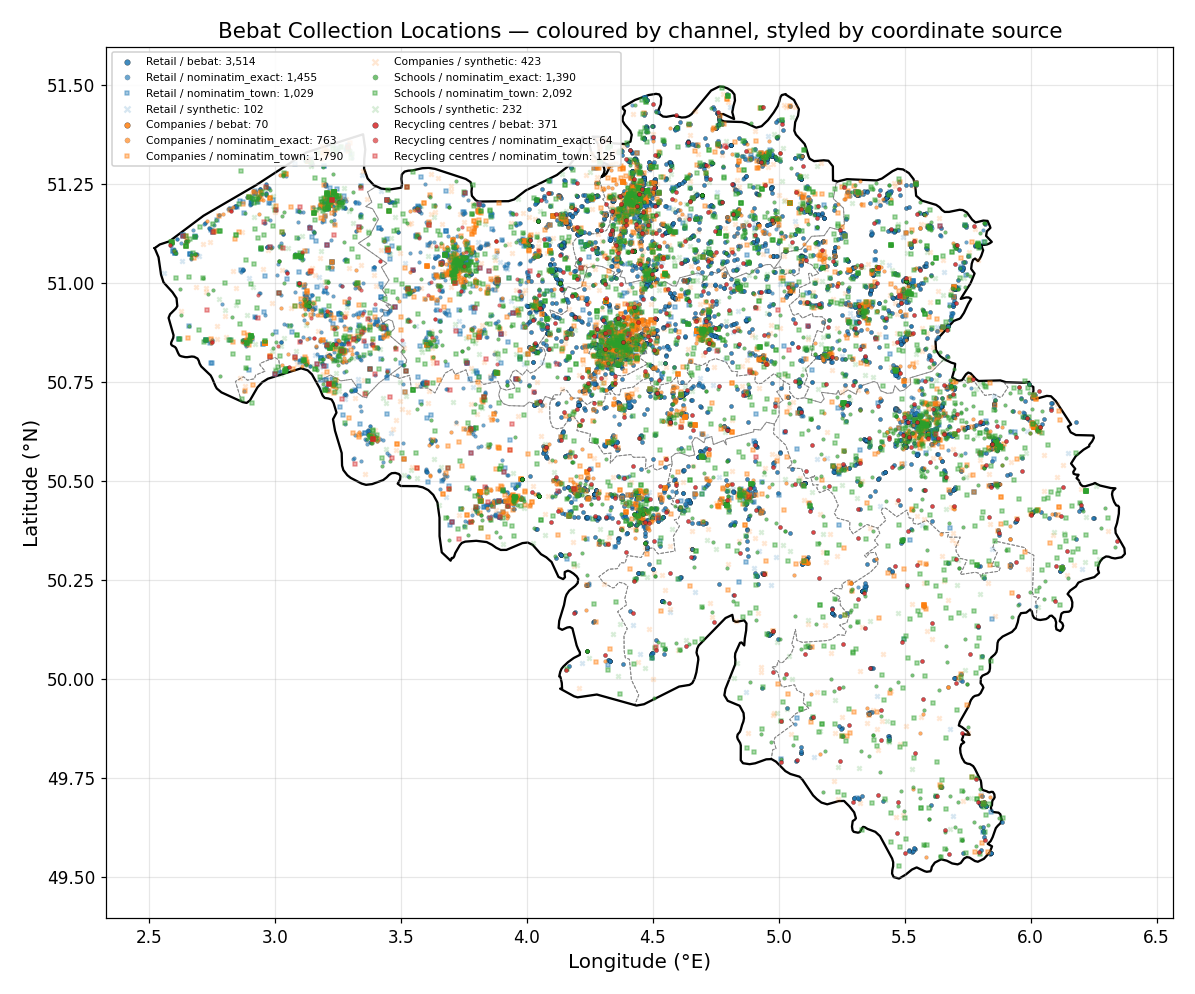

Static map saved to outputs\locations_map.png
  ✓ Country outline drawn from belgium_country.geojson
  ✓ Provincial borders drawn from belgium_provinces.geojson
  Map 1 (known points only):  outputs\locations_map_real.html  (12,663 points)
  Map 2 (all points):         outputs\locations_map_all.html  (12,663 known + 757 synthetic)
  Open either HTML file in a browser; toggle layers via the top-right control.


In [11]:
# =============================================================================
# MAP VISUALISATION — static (matplotlib) + optional interactive (folium)
# Adds Belgium country + provincial outlines from Natural Earth.
# =============================================================================

# Build a per-location plotting frame
loc_meta = (
    df_long[['LocationNumber', 'Channel', 'Location']]
    .drop_duplicates(subset=['LocationNumber'])
    .copy()
)
loc_meta['LocationNumber'] = loc_meta['LocationNumber'].astype(str)
plot_df = loc_meta.merge(coords, left_on='LocationNumber', right_index=True, how='left')

# ---- Helpers to draw GeoJSON outlines on a matplotlib axis ------------------
def _iter_polygon_rings(geom: dict):
    """Yield (outer_ring, holes) for each polygon piece in a GeoJSON geometry."""
    if geom['type'] == 'Polygon':
        yield geom['coordinates'][0], geom['coordinates'][1:]
    elif geom['type'] == 'MultiPolygon':
        for poly in geom['coordinates']:
            yield poly[0], poly[1:]

def _draw_geojson_outline(ax, geojson_path: Path, **plot_kwargs):
    """Draw the boundary lines of a GeoJSON FeatureCollection onto ax."""
    if not geojson_path.exists():
        return False
    with open(geojson_path, encoding='utf-8') as f:
        gj = json.load(f)
    for feat in gj['features']:
        for outer, holes in _iter_polygon_rings(feat['geometry']):
            xs = [c[0] for c in outer]
            ys = [c[1] for c in outer]
            ax.plot(xs, ys, **plot_kwargs)
            for h in holes:
                hxs = [c[0] for c in h]
                hys = [c[1] for c in h]
                ax.plot(hxs, hys, **plot_kwargs)
    return True

# ---- Static map -------------------------------------------------------------
channel_colors = {
    'Retail':            '#1f77b4',
    'Companies':         '#ff7f0e',
    'Schools':           '#2ca02c',
    'Recycling centres': '#d62728',
}
source_styles = {
    'bebat':           {'alpha': 0.85, 'marker': 'o', 'size': 7,
                        'edgecolors': 'black', 'linewidths': 0.2},
    'nominatim_exact': {'alpha': 0.65, 'marker': 'o', 'size': 6,
                        'edgecolors': 'black', 'linewidths': 0.1},
    'nominatim_town':  {'alpha': 0.40, 'marker': 's', 'size': 5},
    'synthetic':       {'alpha': 0.18, 'marker': 'x', 'size': 8},
}

fig, ax = plt.subplots(figsize=(12, 9))

# Draw province outlines first (subtle grey behind everything)
prov_drawn = _draw_geojson_outline(
    ax, PROVINCES_GEOJSON,
    color='#888888', linewidth=0.6, linestyle='--', zorder=0.5,
)
# Country outline on top of provinces (bold black)
country_drawn = _draw_geojson_outline(
    ax, COUNTRY_GEOJSON,
    color='black', linewidth=1.5, zorder=1.0,
)

# Now plot the points
for channel, color in channel_colors.items():
    sub = plot_df[plot_df['Channel'] == channel]
    for source, style in source_styles.items():
        s = sub[sub['source'] == source]
        if len(s) == 0: continue
        kwargs = dict(c=color, s=style['size'], alpha=style['alpha'],
                      marker=style['marker'], zorder=2.0)
        if 'edgecolors' in style: kwargs['edgecolors'] = style['edgecolors']
        if 'linewidths' in style: kwargs['linewidths'] = style['linewidths']
        ax.scatter(s['lon'], s['lat'],
                   label=f"{channel} / {source}: {len(s):,}", **kwargs)

ax.set_aspect(1 / np.cos(np.radians(50.5)))
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
title = 'Bebat Collection Locations'
if country_drawn:
    title += ' — coloured by channel, styled by coordinate source'
ax.set_title(title)
ax.legend(loc='upper left', fontsize=7, markerscale=1.4, framealpha=0.9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'locations_map.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Static map saved to {OUTPUT_DIR / 'locations_map.png'}")
if country_drawn:
    print(f"  ✓ Country outline drawn from {COUNTRY_GEOJSON.name}")
if prov_drawn:
    print(f"  ✓ Provincial borders drawn from {PROVINCES_GEOJSON.name}")
if not (country_drawn or prov_drawn):
    print(f"  (No boundary GeoJSON found — run `python download_belgium_boundaries.py`)")

# ---- Interactive folium maps -----------------------------------------------
# Two outputs:
#   locations_map_real.html — only verified coordinates (bebat + Nominatim).
#                             What you'd show as the "actual collection network".
#   locations_map_all.html  — every location, with synthetic points on a
#                             separate toggleable layer so the audience can
#                             see how the bounding-box fallbacks fill the gaps.
try:
    import folium
    from folium.plugins import MarkerCluster

    def _add_belgium_outline(m: 'folium.Map'):
        """Add the Belgium country boundary + provincial borders to a map (if cached)."""
        if COUNTRY_GEOJSON.exists():
            with open(COUNTRY_GEOJSON, encoding='utf-8') as f:
                folium.GeoJson(
                    json.load(f),
                    name='Belgium boundary',
                    style_function=lambda x: {
                        'color': 'black', 'weight': 2, 'fillOpacity': 0,
                    },
                ).add_to(m)
        if PROVINCES_GEOJSON.exists():
            with open(PROVINCES_GEOJSON, encoding='utf-8') as f:
                folium.GeoJson(
                    json.load(f),
                    name='Provinces',
                    style_function=lambda x: {
                        'color': '#888888', 'weight': 1,
                        'dashArray': '5,5', 'fillOpacity': 0,
                    },
                ).add_to(m)

    def _add_points_layer(m: 'folium.Map', points: pd.DataFrame, layer_name: str,
                          channel_colors_map: dict, *, show: bool = True,
                          opacity: float = 0.7, radius: int = 3):
        """Add a folium MarkerCluster layer for a subset of points, coloured by channel."""
        cluster = MarkerCluster(name=layer_name, show=show).add_to(m)
        for channel, color in channel_colors_map.items():
            sub = points[points['Channel'] == channel]
            for _, row in sub.iterrows():
                folium.CircleMarker(
                    location=[row['lat'], row['lon']],
                    radius=radius, color=color, fill=True,
                    fill_opacity=opacity, weight=0,
                    popup=folium.Popup(
                        f"<b>{row['Channel']}</b><br>{row['Location']}<br>"
                        f"source: {row['source']}",
                        max_width=300,
                    ),
                ).add_to(cluster)

    real_only  = plot_df[plot_df['source'].isin(['bebat', 'nominatim_exact', 'nominatim_town'])]
    synthetic  = plot_df[plot_df['source'] == 'synthetic']

    # ---------------------------------------------------------------- map 1
    m_real = folium.Map(location=[50.85, 4.35], zoom_start=8, tiles='cartodbpositron')
    _add_belgium_outline(m_real)
    _add_points_layer(m_real, real_only,
                      f"All known points ({len(real_only):,})",
                      channel_colors, show=True)
    folium.LayerControl(collapsed=False).add_to(m_real)
    real_path = OUTPUT_DIR / 'locations_map_real.html'
    m_real.save(str(real_path))
    print(f"  Map 1 (known points only):  {real_path}  ({len(real_only):,} points)")

    # ---------------------------------------------------------------- map 2
    m_all = folium.Map(location=[50.85, 4.35], zoom_start=8, tiles='cartodbpositron')
    _add_belgium_outline(m_all)
    _add_points_layer(m_all, real_only,
                      f"Known points ({len(real_only):,})",
                      channel_colors, show=True)
    _add_points_layer(m_all, synthetic,
                      f"Synthetic fallbacks ({len(synthetic):,})",
                      channel_colors, show=True, opacity=0.35, radius=2)
    folium.LayerControl(collapsed=False).add_to(m_all)
    all_path = OUTPUT_DIR / 'locations_map_all.html'
    m_all.save(str(all_path))
    print(f"  Map 2 (all points):         {all_path}  "
          f"({len(real_only):,} known + {len(synthetic):,} synthetic)")
    print(f"  Open either HTML file in a browser; toggle layers via the top-right control.")
except ImportError:
    print("(folium not installed — skipping interactive maps. `pip install folium` to enable.)")


## Module 4 — Spatial Consolidation (K-Means)Following Section 3.1.2, we partition the collection points into operational zonesby minimising the squared Euclidean distance between each point and its assignedcentroid.

In [13]:
# =============================================================================
# K-MEANS CLUSTERING — partition collection points into operational zones
# =============================================================================

def cluster_locations(coords_df: pd.DataFrame, n_zones: int, seed: int) -> pd.DataFrame:
    """Assign each location to one of n_zones operational zones.

    Returns the input DataFrame plus a 'zone' column and a centroids DataFrame.
    """
    X = coords_df[['lat', 'lon']].values
    km = KMeans(n_clusters=n_zones, random_state=seed, n_init=10)
    labels = km.fit_predict(X)
    out = coords_df.copy()
    out['zone'] = labels
    centroids = pd.DataFrame(
        km.cluster_centers_, columns=['lat', 'lon']
    ).reset_index().rename(columns={'index': 'zone'})
    return out, centroids

coords_with_zones, zone_centroids = cluster_locations(
    coords,
    n_zones=CONFIG['spatial']['n_zones'],
    seed=SEEDS['kmeans'],
)
print(f"Locations partitioned into {len(zone_centroids)} zones")
print("\nZone size distribution (top 10):")
print(coords_with_zones['zone'].value_counts().head(10))
print("\nCentroids (first 5):")
print(zone_centroids.head())

Locations partitioned into 50 zones

Zone size distribution (top 10):
zone
31    990
37    693
22    630
13    625
1     403
12    398
24    369
33    361
45    357
14    353
Name: count, dtype: int64

Centroids (first 5):
   zone        lat       lon
0     0  49.661188  5.717913
1     1  50.861333  4.455990
2     2  50.844265  2.911409
3     3  50.611488  5.895051
4     4  50.774852  3.829172


In [14]:
# =============================================================================
# REGIONAL HUBS — pick K-means cluster centres for the 5 regional hubs
# =============================================================================

def select_hubs(coords_df: pd.DataFrame, n_hubs: int, seed: int) -> pd.DataFrame:
    """Run a coarser K-means to identify hub locations."""
    X = coords_df[['lat', 'lon']].values
    km = KMeans(n_clusters=n_hubs, random_state=seed, n_init=10)
    km.fit(X)
    hubs = pd.DataFrame(km.cluster_centers_, columns=['lat', 'lon'])
    hubs['hub_id'] = [f"HUB_{i}" for i in range(n_hubs)]
    return hubs[['hub_id', 'lat', 'lon']]

hubs = select_hubs(coords, n_hubs=CONFIG['spatial']['n_hubs'], seed=SEEDS['kmeans'])
print(f"{len(hubs)} regional hubs:")
print(hubs)

5 regional hubs:
  hub_id        lat       lon
0  HUB_0  51.029445  4.392477
1  HUB_1  50.401686  5.615469
2  HUB_2  50.982925  3.372240
3  HUB_3  51.010577  5.217333
4  HUB_4  50.476952  4.376127


## Module 4b — K-Means Cluster Map

Visualise the 50 operational zones produced by Module 4. Each location is
coloured by its zone; zone centroids are marked with stars; the 5 regional
hubs are marked with red triangles.

The static PNG (`outputs/zones_map.png`) is included in the thesis figures.
The interactive HTML (`outputs/zones_map.html`) lets you hover over individual
points to see their location name and zone assignment.


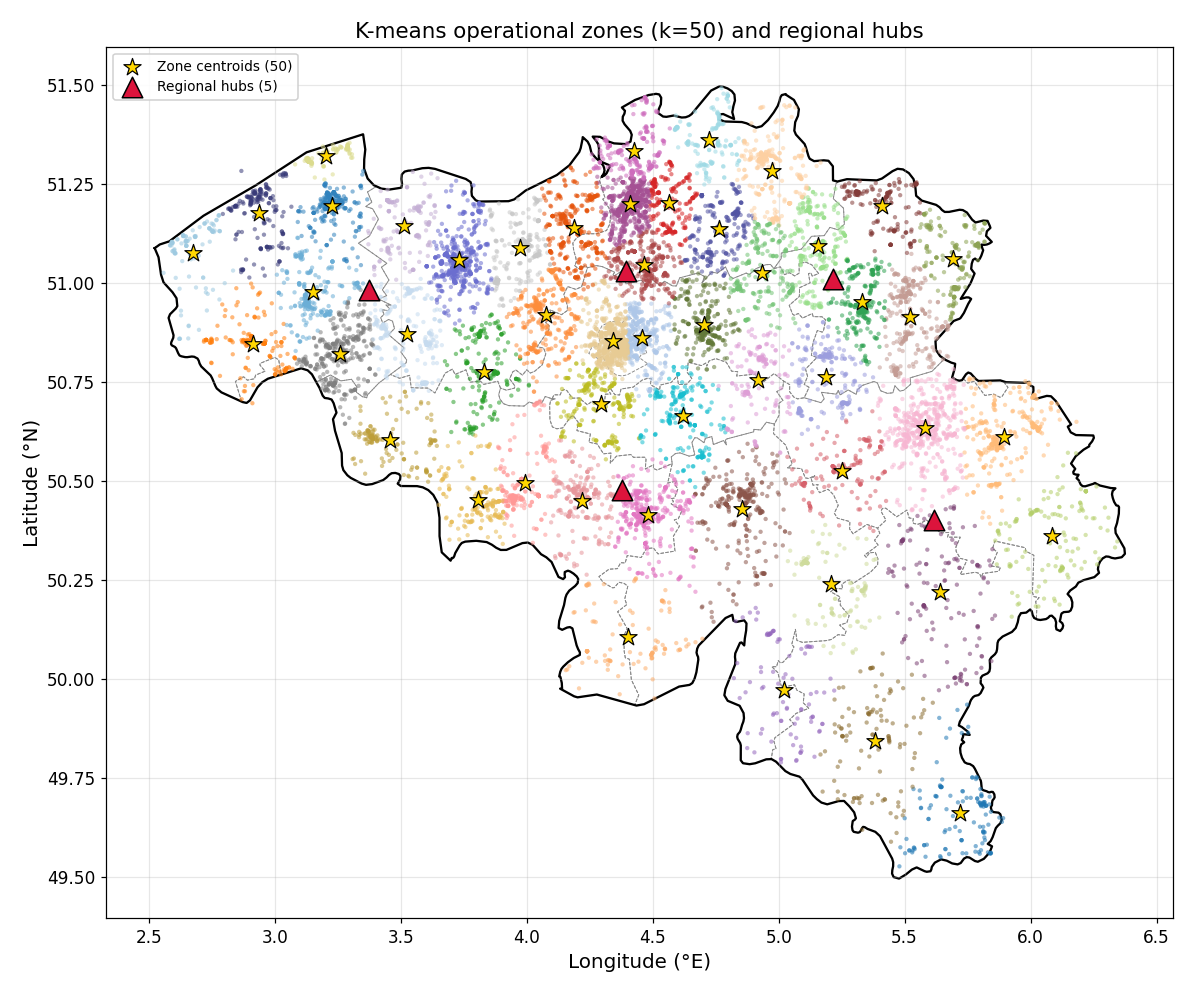

Static cluster map saved to outputs\zones_map.png
Interactive cluster map saved to outputs\zones_map.html


In [16]:
# =============================================================================
# K-MEANS CLUSTER MAP — visualise the 50 operational zones
# =============================================================================

# Build a zone-coloured plotting frame: per-location lat/lon + zone + Channel
zone_plot = (
    df_long[['LocationNumber', 'Channel', 'Location']]
    .drop_duplicates(subset=['LocationNumber'])
    .copy()
)
zone_plot['LocationNumber'] = zone_plot['LocationNumber'].astype(str)
zone_plot = zone_plot.merge(
    coords_with_zones[['lat', 'lon', 'zone']],
    left_on='LocationNumber', right_index=True, how='inner',
)

n_zones = int(zone_plot['zone'].max()) + 1

# ---- Static map -------------------------------------------------------------
import matplotlib.colors as mcolors
# A perceptually-spread palette of 50 distinct colours (qualitative tab20 + tab20b + tab20c)
def _zone_palette(n: int):
    palette = (
        list(plt.cm.tab20.colors)
        + list(plt.cm.tab20b.colors)
        + list(plt.cm.tab20c.colors)
    )
    return [mcolors.to_hex(palette[i % len(palette)]) for i in range(n)]

zone_colors = _zone_palette(n_zones)

fig, ax = plt.subplots(figsize=(12, 9))

# Belgium outline behind everything
def _draw_outline(ax, p, **kw):
    if not p.exists(): return False
    with open(p, encoding='utf-8') as f:
        gj = json.load(f)
    for feat in gj['features']:
        geom = feat['geometry']
        polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for poly in polys:
            outer = poly[0]
            ax.plot([c[0] for c in outer], [c[1] for c in outer], **kw)
    return True

_draw_outline(ax, PROVINCES_GEOJSON,
              color='#888888', linewidth=0.6, linestyle='--', zorder=0.5)
_draw_outline(ax, COUNTRY_GEOJSON,
              color='black', linewidth=1.5, zorder=1.0)

# Plot the points: one scatter call per zone for crisp colour grouping
for z in range(n_zones):
    sub = zone_plot[zone_plot['zone'] == z]
    if len(sub) == 0: continue
    ax.scatter(sub['lon'], sub['lat'],
               c=zone_colors[z], s=8, alpha=0.55,
               edgecolors='none', zorder=2)

# Zone centroids on top (yellow stars with black edge)
ax.scatter(zone_centroids['lon'], zone_centroids['lat'],
           marker='*', s=140, c='gold', edgecolors='black', linewidths=0.8,
           zorder=3, label=f'Zone centroids ({n_zones})')

# Hubs (red triangles, biggest)
ax.scatter(hubs['lon'], hubs['lat'],
           marker='^', s=180, c='crimson', edgecolors='black', linewidths=1.0,
           zorder=4, label=f'Regional hubs ({len(hubs)})')

ax.set_aspect(1 / np.cos(np.radians(50.5)))
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'K-means operational zones (k={n_zones}) and regional hubs')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'zones_map.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Static cluster map saved to {OUTPUT_DIR / 'zones_map.png'}")

# ---- Interactive folium map -------------------------------------------------
try:
    import folium
    m = folium.Map(location=[50.85, 4.35], zoom_start=8, tiles='cartodbpositron')

    # Country + provincial outlines
    if COUNTRY_GEOJSON.exists():
        with open(COUNTRY_GEOJSON, encoding='utf-8') as f:
            folium.GeoJson(json.load(f), name='Belgium boundary',
                style_function=lambda x: {'color':'black','weight':2,'fillOpacity':0}
            ).add_to(m)
    if PROVINCES_GEOJSON.exists():
        with open(PROVINCES_GEOJSON, encoding='utf-8') as f:
            folium.GeoJson(json.load(f), name='Provinces',
                style_function=lambda x: {'color':'#888','weight':1,
                                          'dashArray':'5,5','fillOpacity':0}
            ).add_to(m)

    # One feature group per zone
    from folium.plugins import MarkerCluster
    for z in range(n_zones):
        sub = zone_plot[zone_plot['zone'] == z]
        if len(sub) == 0: continue
        fg = folium.FeatureGroup(name=f"Zone {z} ({len(sub)} pts)", show=(z < 10))
        for _, row in sub.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=2.5, color=zone_colors[z], fill=True,
                fill_opacity=0.7, weight=0,
                popup=f"<b>{row['Location']}</b><br>"
                      f"{row['Channel']}<br>Zone {z}",
            ).add_to(fg)
        fg.add_to(m)

    # Centroids and hubs as separate layers
    cent_fg = folium.FeatureGroup(name='Zone centroids', show=True)
    for _, c in zone_centroids.iterrows():
        folium.Marker(
            location=[c['lat'], c['lon']],
            icon=folium.Icon(color='orange', icon='star', prefix='fa'),
            popup=f"Centroid zone {int(c['zone'])}",
        ).add_to(cent_fg)
    cent_fg.add_to(m)

    hub_fg = folium.FeatureGroup(name='Regional hubs', show=True)
    for _, h in hubs.iterrows():
        folium.Marker(
            location=[h['lat'], h['lon']],
            icon=folium.Icon(color='red', icon='industry', prefix='fa'),
            popup=f"<b>{h['hub_id']}</b>",
        ).add_to(hub_fg)
    hub_fg.add_to(m)

    folium.LayerControl(collapsed=True).add_to(m)
    out_html = OUTPUT_DIR / 'zones_map.html'
    m.save(str(out_html))
    print(f"Interactive cluster map saved to {out_html}")
except ImportError:
    print("(folium not installed — skipping interactive cluster map.)")


## Module 5 — Historical Extension (2 → 3 years via Top-Down Hierarchical Allocation)

The supplied dataset covers two calendar years (2019–2020). The thesis methodology
(§3.2) and case study (§4.2) require **three years** of input so the Monte Carlo
traces can be generated over a 3-year rolling horizon. We therefore synthesise
one additional year (2021) before running the Poisson disaggregation.

### Method — top-down hierarchical allocation

We follow the **top-down hierarchical forecasting principle** of
Hyndman, Ahmed, Athanasopoulos & Shang (2011): forecast a quantity at the
*aggregate* level, then distribute it down the hierarchy in proportion to the
historical shares observed at the lower levels. In symbols:

$$
w_{i,m,2021}
\;=\;
\underbrace{T_{2021}}_{\text{network total}}
\;\cdot\;
\underbrace{p_m}_{\substack{\text{monthly}\\\text{share}}}
\;\cdot\;
\underbrace{s_i}_{\substack{\text{location}\\\text{share}}}
$$

where:

| Quantity | Definition |
|----------|------------|
| $T_{2021}$ | Network-wide total for 2021. Computed as $\bar{T} \cdot (1+g)^{2}$ where $\bar{T}$ is the 2019-2020 mean and $g$ is the **annual growth rate** taken from the active scenario in `CONFIG['demand']['growth_scenarios']`. Two scenarios are defined per Section 4.1.1 of the thesis: **low** (2.83 %) and **high** (4.21 %). Switch with `CONFIG['demand']['active_growth_scenario']`. |
| $p_m$ | Empirical monthly share — the average fraction of annual collections falling in calendar month $m$ across 2019-2020. Captures seasonality (Belgium has a clear November peak). |
| $s_i$ | Empirical location share — location $i$'s fraction of total 2019-2020 weight. Preserves the heterogeneity of the network (large retailers stay large, small schools stay small). |

This single-equation allocation guarantees three properties **by construction**:

1. **Mass conservation at the network level**: $\sum_{i,m} w_{i,m,2021} = T_{2021}$.
2. **Seasonality preserved**: November remains the busiest month, April the quietest.
3. **Heterogeneity preserved**: every location's relative size stays exactly the same.

The output `df_long_extended` has the same schema as `df_long` but spans 36 months
instead of 24. Module 6 onwards (Poisson disaggregation, Monte Carlo traces, fleet
sizing) consumes this extended record without any structural changes.

### Reference

> Hyndman, R. J., Ahmed, R. A., Athanasopoulos, G., & Shang, H. L. (2011).
> Optimal combination forecasts for hierarchical time series.
> *Computational Statistics & Data Analysis*, 55(9), 2579–2589.
> [doi:10.1016/j.csda.2011.03.006](https://doi.org/10.1016/j.csda.2011.03.006)


Historical extension — top-down hierarchical allocation
------------------------------------------------------------
Method:         Hyndman et al. (2011) top-down allocation
Active scenario: 'low'  →  growth rate 2.83 %/year
Historical:     [2019, 2020]
Synthesised:    [2021]

Annual totals (kg):
  2019     3,187,324   (observed)
  2020     3,042,580   (observed)
  2021     3,293,753   (synthesised)

Locations:       13,420
Rows added:      161,040
Year-3 mass check: 3,293,753 kg (matches target: True)

df_long:            45,503 rows  (   6,229,904 kg)
df_long_extended:  206,543 rows  (   9,523,656 kg)


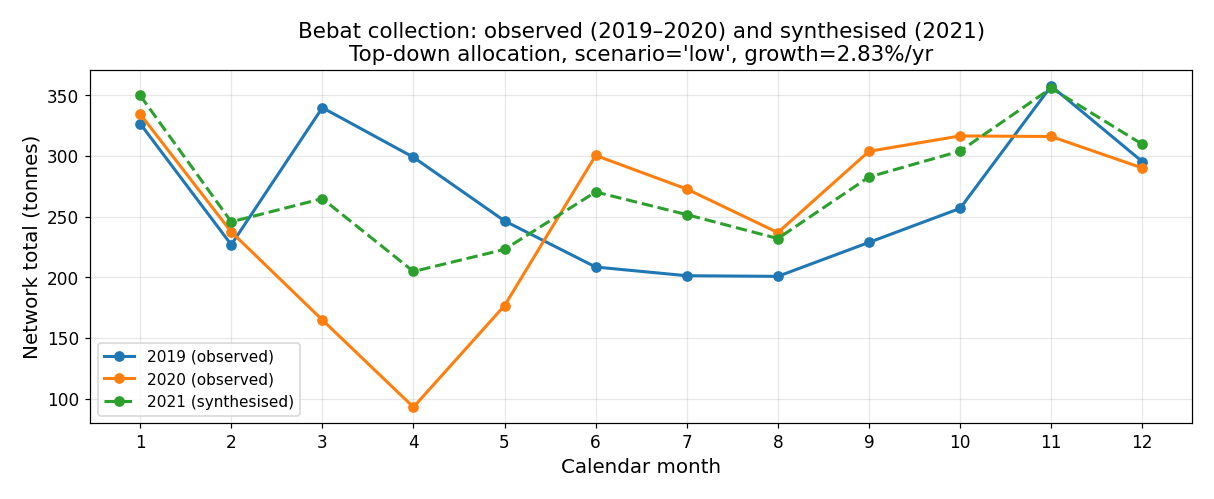


Diagnostic plot saved to outputs\historical_extension.png

Saved CSV copies:
  Original (24 months): outputs\collection_data_original.csv
  Extended (36 months): outputs\collection_data_extended_low.csv


In [18]:
# =============================================================================
# HISTORICAL EXTENSION — top-down hierarchical allocation (Hyndman et al., 2011)
# =============================================================================

def extend_history_topdown(
    df_long: pd.DataFrame,
    growth_rate: float,
    target_years: List[int],
) -> Tuple[pd.DataFrame, dict]:
    """Extend df_long by one or more synthetic years using top-down allocation.

    For each target year y, generate per-location per-month weights as:
        w_{i,m,y} = T_y * p_m * s_i
    where:
        T_y = mean(historical annual totals) * (1 + g)^(y - min(historical years))
        p_m = average monthly share across historical years (sums to 1)
        s_i = location i's share of total historical weight (sums to 1)

    Returns: (df_long_extended, diagnostics_dict)
    """
    historical_years = sorted(df_long['year'].unique())
    if not historical_years:
        raise ValueError("df_long has no year information.")
    base_year = min(historical_years)

    # ---- p_m : empirical monthly share (averaged across years) -------------
    monthly = df_long.groupby(['year', 'month'], as_index=False)['weight_kg'].sum()
    annual = df_long.groupby('year')['weight_kg'].sum()
    monthly['frac'] = monthly.apply(lambda r: r['weight_kg'] / annual[r['year']], axis=1)
    p_m = monthly.groupby('month')['frac'].mean()
    p_m = p_m / p_m.sum()  # ensure exact sum-to-one

    # ---- s_i : empirical location share over the whole historical record ---
    total_hist = df_long['weight_kg'].sum()
    loc_totals = (
        df_long.groupby(['LocationNumber', 'Channel', 'Location'], as_index=False)['weight_kg']
               .sum()
               .rename(columns={'weight_kg': 'hist_total'})
    )
    loc_totals['s_i'] = loc_totals['hist_total'] / total_hist

    # ---- Target year totals ------------------------------------------------
    T_avg = annual.mean()
    target_totals = {y: T_avg * (1.0 + growth_rate) ** (y - base_year) for y in target_years}

    # ---- Build year × month × location frame -------------------------------
    new_rows_frames = []
    for y in target_years:
        T_y = target_totals[y]
        for m in range(1, 13):
            M_m_y = T_y * p_m[m]
            block = loc_totals[['LocationNumber', 'Channel', 'Location', 's_i']].copy()
            block['year'] = y
            block['month'] = m
            block['weight_kg'] = block['s_i'] * M_m_y
            block = block.drop(columns=['s_i'])
            block = block[block['weight_kg'] > 0]
            new_rows_frames.append(block)
    df_synth = pd.concat(new_rows_frames, ignore_index=True)
    df_synth = df_synth[df_long.columns.tolist()]  # match column order

    df_extended = pd.concat([df_long, df_synth], ignore_index=True)

    diagnostics = {
        'historical_years': historical_years,
        'base_year': base_year,
        'target_years': target_years,
        'growth_rate': growth_rate,
        'T_historical_mean_kg': float(T_avg),
        'T_historical_per_year_kg': annual.to_dict(),
        'T_target_per_year_kg': {int(y): float(t) for y, t in target_totals.items()},
        'monthly_share_p_m': {int(m): float(p_m[m]) for m in p_m.index},
        'n_locations': int(len(loc_totals)),
        'rows_added': int(len(df_synth)),
        'mass_check_kg': float(df_synth['weight_kg'].sum()),
    }
    return df_extended, diagnostics


ACTIVE_SCENARIO = CONFIG['demand']['active_growth_scenario']
GROWTH_RATE = CONFIG['demand']['growth_scenarios'][ACTIVE_SCENARIO]
TARGET_YEARS = [2021]                             # extend by one year (2 -> 3 total)

df_long_extended, ext_diag = extend_history_topdown(
    df_long,
    growth_rate=GROWTH_RATE,
    target_years=TARGET_YEARS,
)

# ---- Print summary ----
print("Historical extension — top-down hierarchical allocation")
print("-" * 60)
print(f"Method:         Hyndman et al. (2011) top-down allocation")
print(f"Active scenario: {ACTIVE_SCENARIO!r}  →  growth rate {GROWTH_RATE*100:.2f} %/year")
print(f"Historical:     {ext_diag['historical_years']}")
print(f"Synthesised:    {ext_diag['target_years']}")
print()
print("Annual totals (kg):")
for y, t in ext_diag['T_historical_per_year_kg'].items():
    print(f"  {y}  {t:>12,.0f}   (observed)")
for y, t in ext_diag['T_target_per_year_kg'].items():
    print(f"  {y}  {t:>12,.0f}   (synthesised)")
print()
print(f"Locations:       {ext_diag['n_locations']:,}")
print(f"Rows added:      {ext_diag['rows_added']:,}")
print(f"Year-3 mass check: {ext_diag['mass_check_kg']:,.0f} kg "
      f"(matches target: {abs(ext_diag['mass_check_kg'] - sum(ext_diag['T_target_per_year_kg'].values())) < 1.0})")
print()
print(f"df_long:           {len(df_long):>7,} rows  ({df_long['weight_kg'].sum():>12,.0f} kg)")
print(f"df_long_extended:  {len(df_long_extended):>7,} rows  ({df_long_extended['weight_kg'].sum():>12,.0f} kg)")

# ---- Diagnostic plot --------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
yearly_monthly = (
    df_long_extended.groupby(['year', 'month'])['weight_kg'].sum() / 1000
).reset_index()
for y in sorted(yearly_monthly['year'].unique()):
    sub = yearly_monthly[yearly_monthly['year'] == y]
    is_synth = y in TARGET_YEARS
    ax.plot(
        sub['month'], sub['weight_kg'],
        marker='o', linewidth=2.0,
        linestyle='--' if is_synth else '-',
        label=f"{y} ({'synthesised' if is_synth else 'observed'})",
    )
ax.set_xlabel('Calendar month')
ax.set_ylabel('Network total (tonnes)')
ax.set_title(f'Bebat collection: observed (2019–2020) and synthesised (2021)\n'
             f'Top-down allocation, scenario={ACTIVE_SCENARIO!r}, growth={GROWTH_RATE*100:.2f}%/yr')
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'historical_extension.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"\nDiagnostic plot saved to {OUTPUT_DIR / 'historical_extension.png'}")

# Persist the diagnostics so they end up in manifest.json
HISTORICAL_EXTENSION_DIAGNOSTICS = ext_diag

# ---- Save both original and extended dataframes for inspection -------------
ORIG_CSV = OUTPUT_DIR / 'collection_data_original.csv'
EXT_CSV  = OUTPUT_DIR / f'collection_data_extended_{ACTIVE_SCENARIO}.csv'
df_long.to_csv(ORIG_CSV, index=False)
df_long_extended.to_csv(EXT_CSV, index=False)
print(f"\nSaved CSV copies:")
print(f"  Original (24 months): {ORIG_CSV}")
print(f"  Extended (36 months): {EXT_CSV}")


## Module 6 — Temporal Disaggregation (Poisson Process)We disaggregate monthly weight totals into individual collection events using aPoisson arrival process (Section 3.1.1). Each event's load is sampled from theBebat recipient mix (Figure 5.1), and each event is capped at `Cmax`.

In [20]:
# =============================================================================
# TEMPORAL DISAGGREGATION — Poisson arrival process (Section 3.1.1)
# =============================================================================

def sample_event_weight(rng, recipient_mix: dict, cap_kg: float) -> float:
    """Draw a single recipient weight from the Bebat mix, capped at cap_kg."""
    types = list(recipient_mix.keys())
    probs = np.array([recipient_mix[t]['frequency'] for t in types])
    probs = probs / probs.sum()
    chosen = rng.choice(types, p=probs)
    return min(recipient_mix[chosen]['weight_kg'], cap_kg)

def disaggregate_to_daily(
    df_monthly: pd.DataFrame,
    location_zone_map: pd.DataFrame,
    recipient_mix: dict,
    cap_kg: float,
    working_days_per_month: int = 21,
    seed: int = 42,
) -> pd.DataFrame:
    """Convert monthly totals into a daily event stream.

    Mass-conservation: events are drawn until the running total matches the
    monthly volume; the last event is trimmed so the total matches exactly.

    Returns: zone, year, month, day_of_month, weight_kg
    """
    rng = np.random.default_rng(seed)
    df = df_monthly.merge(
        location_zone_map[['zone']],
        left_on='LocationNumber', right_index=True, how='left'
    )

    events = []
    for _, row in df.iterrows():
        total_kg = float(row['weight_kg'])
        if total_kg <= 0:
            continue
        running_total = 0.0
        # Keep drawing events until we match the monthly total
        while running_total < total_kg:
            w = sample_event_weight(rng, recipient_mix, cap_kg)
            # Trim the last event so the monthly total matches exactly
            if running_total + w > total_kg:
                w = total_kg - running_total
            running_total += w
            d = int(rng.integers(1, working_days_per_month + 1))
            events.append({
                'zone': row['zone'], 'year': row['year'], 'month': row['month'],
                'day_of_month': d, 'weight_kg': w,
            })
            # Safety break — should never trigger but prevents infinite loop on bad input
            if len(events) > 0 and len(events) % 500_000 == 0:
                if running_total < total_kg * 0.999:
                    break
    return pd.DataFrame(events)

print("Disaggregating monthly volumes to daily events...")
daily_events = disaggregate_to_daily(
    df_long_extended,    # 36-month input from Module 5
    coords_with_zones,
    recipient_mix=CONFIG['recipient_weights'],
    cap_kg=CONFIG['demand']['max_request_capacity_kg'],
    seed=SEEDS['poisson_disaggregation'],
)
print(f"\nGenerated {len(daily_events):,} daily collection events")
print(f"Total weight after disaggregation: {daily_events['weight_kg'].sum():,.0f} kg")
print(f"Original (extended) total: {df_long_extended['weight_kg'].sum():,.0f} kg")
print(f"Ratio (should be ~1.0): {daily_events['weight_kg'].sum() / df_long_extended['weight_kg'].sum():.3f}")
print()
print("Sample events:")
print(daily_events.head())

Disaggregating monthly volumes to daily events...

Generated 326,079 daily collection events
Total weight after disaggregation: 9,523,656 kg
Original (extended) total: 9,523,656 kg
Ratio (should be ~1.0): 1.000

Sample events:
   zone  year  month  day_of_month  weight_kg
0    19  2019      1             3       41.0
1    48  2019      1             2       16.0
2    48  2019      1            15       30.2
3     2  2019      1            13       40.0
4     0  2019      1            20       49.8


## Module 7 — Distance Estimation (OSRM Road Network)

For each operational zone we compute the **real road-network distance** to its
nearest hub via the public OSRM router (`router.project-osrm.org`), which serves
shortest-path distances on the OpenStreetMap road graph.

**Why this replaces the constant circuity factor χ = 1.37.** The thesis used a
single multiplier on Euclidean distances to approximate road distance.  In
reality circuity varies from ~1.10 in highway-rich Flanders to ~1.70 in rural
Wallonia. Using OSRM eliminates that approximation and yields per-pair road
distances grounded in the actual Belgian road network.

**Caching.** All 50 × 5 = 250 zone-hub road distances are queried once and
cached to `outputs/zone_hub_distances.json`. Subsequent runs read the cache and
make no network calls. If OSRM is unreachable the cell falls back gracefully to
haversine × χ = 1.37 so the notebook still runs offline.

**Reference.**
> Luxen, D. & Vetter, C. (2011). *Real-time routing with OpenStreetMap data.*
> Proceedings of the 19th ACM SIGSPATIAL International Conference on Advances in
> Geographic Information Systems, 513–516. DOI: 10.1145/2093973.2094062


In [22]:
# =============================================================================
# DISTANCE ESTIMATION — OSRM road network distances (cached)
# Falls back to haversine × χ = 1.37 if OSRM is unreachable.
# =============================================================================
import urllib.request
import urllib.error

OSRM_BASE_URL  = "https://router.project-osrm.org/route/v1/driving"
OSRM_TIMEOUT_S = 10
DIST_CACHE     = OUTPUT_DIR / "zone_hub_distances.json"

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres (vectorised)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def osrm_road_km(lat1: float, lon1: float, lat2: float, lon2: float, timeout: float = OSRM_TIMEOUT_S):
    """Single OSRM lookup. Returns kilometres or None on failure."""
    coords = f"{lon1},{lat1};{lon2},{lat2}"  # OSRM expects lng,lat
    url = f"{OSRM_BASE_URL}/{coords}?overview=false"
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            data = json.loads(resp.read())
            if data.get('code') == 'Ok' and data.get('routes'):
                return data['routes'][0]['distance'] / 1000.0
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, json.JSONDecodeError):
        return None
    return None

def load_distance_cache(path: Path) -> dict:
    if path.exists():
        with open(path, 'r') as f:
            return json.load(f)
    return {}

def save_distance_cache(path: Path, cache: dict) -> None:
    tmp = path.with_suffix('.json.tmp')
    with open(tmp, 'w') as f:
        json.dump(cache, f, indent=1)
    tmp.replace(path)

def compute_zone_to_hub_distances(
    centroids: pd.DataFrame,
    hubs: pd.DataFrame,
    fallback_circuity: float,
    use_osrm: bool = True,
) -> pd.DataFrame:
    """For each zone, find the nearest hub by road. Caches all 250 pairs to disk."""
    cache = load_distance_cache(DIST_CACHE)
    osrm_calls = osrm_hits = osrm_misses = 0
    rows = []

    for _, z in centroids.iterrows():
        zone_id = int(z['zone'])
        zone_lat, zone_lon = float(z['lat']), float(z['lon'])

        # Pre-filter to top-3 by haversine to limit OSRM calls (5 hubs only — query all)
        haver = haversine_km(zone_lat, zone_lon,
                             hubs['lat'].values, hubs['lon'].values)
        # Query all hubs (only 5)
        per_hub_km = []
        for h_idx, h_row in hubs.reset_index(drop=True).iterrows():
            key = f"zone_{zone_id}__{h_row['hub_id']}"
            if key in cache and cache[key].get('osrm_km') is not None:
                per_hub_km.append(cache[key]['osrm_km'])
                continue
            if not use_osrm:
                per_hub_km.append(haver[h_idx] * fallback_circuity)
                continue

            osrm_calls += 1
            km = osrm_road_km(zone_lat, zone_lon,
                              float(h_row['lat']), float(h_row['lon']))
            if km is not None:
                osrm_hits += 1
                cache[key] = {'osrm_km': km, 'haversine_km': float(haver[h_idx])}
                per_hub_km.append(km)
            else:
                osrm_misses += 1
                fallback_km = haver[h_idx] * fallback_circuity
                cache[key] = {'osrm_km': None, 'haversine_km': float(haver[h_idx]),
                              'fallback_km': fallback_km}
                per_hub_km.append(fallback_km)
            time.sleep(0.05)  # be polite to public OSRM

        per_hub_km = np.array(per_hub_km)
        closest = int(np.argmin(per_hub_km))
        rows.append({
            'zone':           zone_id,
            'nearest_hub':    hubs.iloc[closest]['hub_id'],
            'euclidean_km':   float(haver[closest]),
            'road_km':        float(per_hub_km[closest]),
            'round_trip_km':  float(2 * per_hub_km[closest]),
            'effective_circuity': float(per_hub_km[closest] / haver[closest]) if haver[closest] > 0 else 1.0,
        })

    save_distance_cache(DIST_CACHE, cache)
    return pd.DataFrame(rows), {'osrm_calls': osrm_calls, 'osrm_hits': osrm_hits, 'osrm_misses': osrm_misses}

# Need `import time` here because we sleep between OSRM calls
import time

print("Computing zone-to-hub road distances via OSRM...")
print(f"  Cache file: {DIST_CACHE}")
zone_distances, osrm_stats = compute_zone_to_hub_distances(
    zone_centroids, hubs,
    fallback_circuity=CONFIG['spatial']['circuity_factor'],
    use_osrm=True,
)
print(f"  OSRM calls made:    {osrm_stats['osrm_calls']}")
print(f"  OSRM successes:     {osrm_stats['osrm_hits']}")
print(f"  OSRM failures:      {osrm_stats['osrm_misses']}  (fell back to haversine × χ)")
print()
print("Distance summary:")
print(zone_distances[['euclidean_km', 'road_km', 'round_trip_km', 'effective_circuity']].describe().round(2))
print()
print("Effective circuity by zone (compare to thesis assumption χ = 1.37):")
print(f"  median: {zone_distances['effective_circuity'].median():.2f}")
print(f"  mean:   {zone_distances['effective_circuity'].mean():.2f}")
print(f"  min:    {zone_distances['effective_circuity'].min():.2f}")
print(f"  max:    {zone_distances['effective_circuity'].max():.2f}")
print()
print("First 5 zones:")
print(zone_distances.head().to_string(index=False))


Computing zone-to-hub road distances via OSRM...
  Cache file: outputs\zone_hub_distances.json
  OSRM calls made:    0
  OSRM successes:     0
  OSRM failures:      0  (fell back to haversine × χ)

Distance summary:
       euclidean_km  road_km  round_trip_km  effective_circuity
count         50.00    50.00          50.00               50.00
mean          29.89    42.29          84.57                1.44
std           14.39    19.03          38.06                0.21
min            5.41     7.38          14.77                1.11
25%           20.13    31.54          63.08                1.29
50%           27.55    40.26          80.53                1.38
75%           35.68    48.40          96.79                1.54
max           82.66   106.38         212.76                1.95

Effective circuity by zone (compare to thesis assumption χ = 1.37):
  median: 1.38
  mean:   1.44
  min:    1.11
  max:    1.95

First 5 zones:
 zone nearest_hub  euclidean_km  road_km  round_trip_km  effect

## Module 7b — Pairwise Distance Matrices (Zone↔Zone, Hub↔Hub)

The savings-algorithm router (Module 10, `routing_mode='savings'`) needs **pairwise** distances, not just zone→hub. We precompute two matrices once and cache them to disk:

* **Zone↔Zone (50×50)** — used by the savings algorithm to score `s(i,j) = d(hub,i) + d(hub,j) − d(i,j)`.
* **Hub↔Hub (5×5)** — used by AV multi-depot tours to evaluate "start at hub A, end at hub B".

Both matrices use OSRM road distances (cached) with haversine × χ = 1.37 fallback. This is a one-time ~20-minute cost; subsequent runs read straight from cache.


In [24]:
# =============================================================================
# PAIRWISE DISTANCE MATRICES — zone↔zone (50×50) and hub↔hub (5×5)
# =============================================================================
ZZ_CACHE = OUTPUT_DIR / "zone_zone_distances.json"
HH_CACHE = OUTPUT_DIR / "hub_hub_distances.json"


def build_pairwise_matrix(
    points_df: pd.DataFrame,
    id_col: str,
    cache_path: Path,
    fallback_circuity: float,
    use_osrm: bool = True,
    label: str = "matrix",
) -> np.ndarray:
    """Build a symmetric N×N road-distance matrix, cached.

    points_df: must contain columns [id_col, 'lat', 'lon'] in the canonical order
               that defines the row/column index of the returned matrix.
    """
    cache = load_distance_cache(cache_path)
    n = len(points_df)
    ids = points_df[id_col].tolist()
    lats = points_df['lat'].values
    lons = points_df['lon'].values
    M = np.zeros((n, n))

    pairs_total = n * (n - 1) // 2
    pairs_done = 0
    osrm_calls = osrm_hits = osrm_misses = 0
    print(f"  Building {label}: {n}×{n} ({pairs_total} unique pairs)")

    for i in range(n):
        for j in range(i + 1, n):
            key = f"{ids[i]}__{ids[j]}"
            key_rev = f"{ids[j]}__{ids[i]}"
            cached = cache.get(key) or cache.get(key_rev)
            if cached and cached.get('osrm_km') is not None:
                km = cached['osrm_km']
            elif cached and cached.get('fallback_km') is not None:
                km = cached['fallback_km']
            else:
                haver = float(haversine_km(lats[i], lons[i], lats[j], lons[j]))
                if use_osrm:
                    osrm_calls += 1
                    km = osrm_road_km(lats[i], lons[i], lats[j], lons[j])
                    if km is not None:
                        osrm_hits += 1
                        cache[key] = {'osrm_km': km, 'haversine_km': haver}
                    else:
                        osrm_misses += 1
                        km = haver * fallback_circuity
                        cache[key] = {'osrm_km': None, 'haversine_km': haver,
                                       'fallback_km': km}
                    time.sleep(0.05)
                else:
                    km = haver * fallback_circuity
                    cache[key] = {'osrm_km': None, 'haversine_km': haver,
                                   'fallback_km': km}
            M[i, j] = M[j, i] = km
            pairs_done += 1
            if pairs_done % 200 == 0:
                pct = 100 * pairs_done / pairs_total
                print(f"    {pairs_done}/{pairs_total} ({pct:.1f}%) — "
                      f"osrm hits {osrm_hits}, misses {osrm_misses}")
                save_distance_cache(cache_path, cache)

    save_distance_cache(cache_path, cache)
    return M, ids, {'osrm_calls': osrm_calls, 'osrm_hits': osrm_hits,
                    'osrm_misses': osrm_misses}


# -------- Build zone↔zone matrix --------
print("Building zone↔zone road-distance matrix...")
print(f"  Cache: {ZZ_CACHE}")
zone_pts = (
    zone_centroids.rename(columns={'zone': 'id'})
    .assign(id=lambda d: d['id'].astype(str).radd('zone_'))
    [['id', 'lat', 'lon']]
)
zone_zone_km, zone_ids_ordered, zz_stats = build_pairwise_matrix(
    zone_pts, 'id', ZZ_CACHE,
    fallback_circuity=CONFIG['spatial']['circuity_factor'],
    use_osrm=True, label="zone↔zone",
)
# Map zone_id (int) -> matrix row index
zone_idx = {int(s.split('_')[1]): i for i, s in enumerate(zone_ids_ordered)}
print(f"  zone↔zone matrix shape {zone_zone_km.shape}, "
      f"mean off-diag {zone_zone_km[~np.eye(len(zone_zone_km), dtype=bool)].mean():.1f} km")

# -------- Build hub↔hub matrix --------
print("\nBuilding hub↔hub road-distance matrix...")
print(f"  Cache: {HH_CACHE}")
hub_pts = hubs[['hub_id', 'lat', 'lon']].rename(columns={'hub_id': 'id'})
hub_hub_km, hub_ids_ordered, hh_stats = build_pairwise_matrix(
    hub_pts, 'id', HH_CACHE,
    fallback_circuity=CONFIG['spatial']['circuity_factor'],
    use_osrm=True, label="hub↔hub",
)
hub_idx = {hid: i for i, hid in enumerate(hub_ids_ordered)}
print(f"  hub↔hub matrix shape {hub_hub_km.shape}, "
      f"mean off-diag {hub_hub_km[~np.eye(len(hub_hub_km), dtype=bool)].mean():.1f} km")

# -------- Per-zone distance to every hub (for asymmetric AV multi-depot) --------
# We already have nearest-hub distance per zone in zone_distances; build the full
# zone × hub matrix here for the savings algorithm.
print("\nBuilding zone↔every-hub distance matrix...")
zone_hub_km = np.zeros((len(zone_centroids), len(hubs)))
zh_cache = load_distance_cache(DIST_CACHE)
for zi, z in zone_centroids.reset_index(drop=True).iterrows():
    for hj, h in hubs.reset_index(drop=True).iterrows():
        key = f"zone_{int(z['zone'])}__{h['hub_id']}"
        e = zh_cache.get(key, {})
        if e.get('osrm_km') is not None:
            zone_hub_km[zi, hj] = e['osrm_km']
        elif e.get('fallback_km') is not None:
            zone_hub_km[zi, hj] = e['fallback_km']
        else:
            zone_hub_km[zi, hj] = (
                haversine_km(z['lat'], z['lon'], h['lat'], h['lon'])
                * CONFIG['spatial']['circuity_factor']
            )
print(f"  zone×hub matrix shape {zone_hub_km.shape}, "
      f"mean {zone_hub_km.mean():.1f} km")

# Stash for downstream modules
DIST_CTX = {
    'zone_zone_km': zone_zone_km,
    'zone_idx': zone_idx,                    # zone_id (int) → row index
    'hub_hub_km': hub_hub_km,
    'hub_idx': hub_idx,                      # hub_id (str) → row index
    'hub_ids_ordered': hub_ids_ordered,      # list of hub_ids in matrix order
    'zone_hub_km': zone_hub_km,              # rows align with zone_centroids order
    'zone_centroids_ordered': zone_centroids.reset_index(drop=True),
}
print("\nDistance context ready.")


Building zone↔zone road-distance matrix...
  Cache: outputs\zone_zone_distances.json
  Building zone↔zone: 50×50 (1225 unique pairs)
    200/1225 (16.3%) — osrm hits 0, misses 0
    400/1225 (32.7%) — osrm hits 0, misses 0
    600/1225 (49.0%) — osrm hits 0, misses 0
    800/1225 (65.3%) — osrm hits 0, misses 0
    1000/1225 (81.6%) — osrm hits 0, misses 0
    1200/1225 (98.0%) — osrm hits 0, misses 0
  zone↔zone matrix shape (50, 50), mean off-diag 121.1 km

Building hub↔hub road-distance matrix...
  Cache: outputs\hub_hub_distances.json
  Building hub↔hub: 5×5 (10 unique pairs)
  hub↔hub matrix shape (5, 5), mean off-diag 128.7 km

Building zone↔every-hub distance matrix...
  zone×hub matrix shape (50, 5), mean 113.5 km

Distance context ready.


## Module 8 — Monte Carlo Trace GenerationSection 3.1.3 of the thesis specifies **10 stochastic traces** over a **3-year horizon**.Each trace is a complete realisation of daily zone-level workload for the planningperiod, generated by:1. Building an empirical CDF from the historical daily distribution (per zone).2. Drawing future days from that CDF (inverse-transform sampling).3. Applying the linear annual growth factor.Each trace gets its own seed (`mc_trace_0` … `mc_trace_9`).

In [26]:
# =============================================================================
# MONTE CARLO TRACE GENERATION (Section 3.1.3)
# =============================================================================
# Strategy:
#   1. From the historical event stream, compute for every zone:
#         a) activity_rate  — fraction of working days the zone was visited at all
#         b) weight_dist    — empirical distribution of total daily weight on
#                              active days (used for inverse-transform sampling)
#   2. To generate one trace, for each (future_day, zone) pair:
#         - Bernoulli(activity_rate)  →  is the zone active today?
#         - if yes: inverse-transform sample a daily weight, scaled by growth
#   This produces realistic day-to-day variability because most zones are
#   inactive on any given day (sparse demand), instead of being averaged out.

def aggregate_daily_workload(events: pd.DataFrame) -> pd.DataFrame:
    """Aggregate event-level data to (zone, year, month, day) totals."""
    daily = events.groupby(
        ['zone', 'year', 'month', 'day_of_month'], as_index=False
    )['weight_kg'].sum()
    return daily

def build_zone_profiles(
    historical_daily: pd.DataFrame, working_days_per_year: int = 250,
) -> Dict[int, dict]:
    """Per-zone activity rate and weight distribution.

    Activity rate = days with activity / total working days observed.
    The number of historical years is auto-detected from the data, so the
    profile uses the full extended horizon (3 years after Module 5 has run,
    not the original 2 years).
    """
    n_hist_years = int(historical_daily['year'].nunique())
    total_days = working_days_per_year * n_hist_years
    profiles = {}
    for zone, grp in historical_daily.groupby('zone'):
        active_days = len(grp)
        weights_sorted = np.sort(grp['weight_kg'].values)
        profiles[int(zone)] = {
            'activity_rate': min(1.0, active_days / total_days),
            'weights_sorted': weights_sorted,
        }
    return profiles

def generate_mc_trace(
    zone_profiles: Dict[int, dict],
    horizon_years: int,
    growth_rate: float,
    seed: int,
    working_days_per_year: int = 250,
) -> pd.DataFrame:
    """Generate one synthetic trace using Bernoulli activity + inverse-transform sampling.

    Returns a DataFrame: trace_day, zone, weight_kg.  Only rows for ACTIVE
    (zone, day) pairs are emitted, so the dataframe is sparse and has
    real day-to-day variability.
    """
    rng = np.random.default_rng(seed)
    horizon_days = horizon_years * working_days_per_year
    rows = []
    for day in range(horizon_days):
        year_idx = day // working_days_per_year
        growth = (1 + growth_rate) ** year_idx
        for zone, prof in zone_profiles.items():
            # Bernoulli — is the zone active today?
            if rng.uniform() > prof['activity_rate']:
                continue
            # Inverse-transform sampling from the empirical distribution
            sorted_vals = prof['weights_sorted']
            u = rng.uniform()
            idx = int(u * (len(sorted_vals) - 1))
            sampled = sorted_vals[idx] * growth
            rows.append({'trace_day': day, 'zone': zone, 'weight_kg': sampled})
    return pd.DataFrame(rows)

historical_daily = aggregate_daily_workload(daily_events)
print(f"Historical daily zone-level records: {len(historical_daily):,}")

zone_profiles = build_zone_profiles(
    historical_daily,
    working_days_per_year=CONFIG['demand']['working_days_per_year'],
)
n_hist_years = int(historical_daily['year'].nunique())
print(f"Historical window detected: {n_hist_years} year(s) \u00d7 "
      f"{CONFIG['demand']['working_days_per_year']} working days = "
      f"{n_hist_years * CONFIG['demand']['working_days_per_year']} total days")
activity_rates = pd.Series({z: p['activity_rate'] for z, p in zone_profiles.items()})
print(f"\nZone activity rates — min={activity_rates.min():.3f}, "
      f"mean={activity_rates.mean():.3f}, max={activity_rates.max():.3f}")

# Generate the 10 traces
print("\nGenerating 10 Monte Carlo traces (3-year horizon)...")
traces = {}
for i in range(CONFIG['demand']['n_mc_traces']):
    trace = generate_mc_trace(
        zone_profiles,
        horizon_years=CONFIG['demand']['horizon_years'],
        growth_rate=CONFIG['demand']['annual_growth_rate'],
        seed=SEEDS[f'mc_trace_{i}'],
        working_days_per_year=CONFIG['demand']['working_days_per_year'],
    )
    traces[i] = trace
    daily_totals = trace.groupby('trace_day')['weight_kg'].sum()
    print(f"  Trace {i}: {len(trace):>6,} active (day,zone) pairs, "
          f"daily total mean={daily_totals.mean():>7,.0f} kg, "
          f"max={daily_totals.max():>7,.0f} kg")

# Variability check
trace_yearly_totals = []
trace_max_days = []
for i, t in traces.items():
    total = t['weight_kg'].sum() / CONFIG['demand']['horizon_years']
    trace_yearly_totals.append(total)
    trace_max_days.append(t.groupby('trace_day')['weight_kg'].sum().max())
print(f"\nAcross-trace yearly total: mean={np.mean(trace_yearly_totals):,.0f}, "
      f"stdev={np.std(trace_yearly_totals):,.0f} kg")
print(f"Across-trace WORST day:    mean={np.mean(trace_max_days):,.0f}, "
      f"stdev={np.std(trace_max_days):,.0f} kg")

Historical daily zone-level records: 36,087
Historical window detected: 3 year(s) × 250 working days = 750 total days

Zone activity rates — min=0.747, mean=0.961, max=1.000

Generating 10 Monte Carlo traces (3-year horizon)...
  Trace 0: 35,989 active (day,zone) pairs, daily total mean= 12,954 kg, max= 17,941 kg
  Trace 1: 36,070 active (day,zone) pairs, daily total mean= 12,958 kg, max= 18,065 kg
  Trace 2: 36,034 active (day,zone) pairs, daily total mean= 12,993 kg, max= 18,716 kg
  Trace 3: 36,020 active (day,zone) pairs, daily total mean= 12,918 kg, max= 18,457 kg
  Trace 4: 36,063 active (day,zone) pairs, daily total mean= 12,946 kg, max= 17,954 kg
  Trace 5: 36,013 active (day,zone) pairs, daily total mean= 12,993 kg, max= 19,203 kg
  Trace 6: 36,083 active (day,zone) pairs, daily total mean= 13,003 kg, max= 18,770 kg
  Trace 7: 36,075 active (day,zone) pairs, daily total mean= 12,953 kg, max= 17,622 kg
  Trace 8: 36,057 active (day,zone) pairs, daily total mean= 12,948 kg, max=

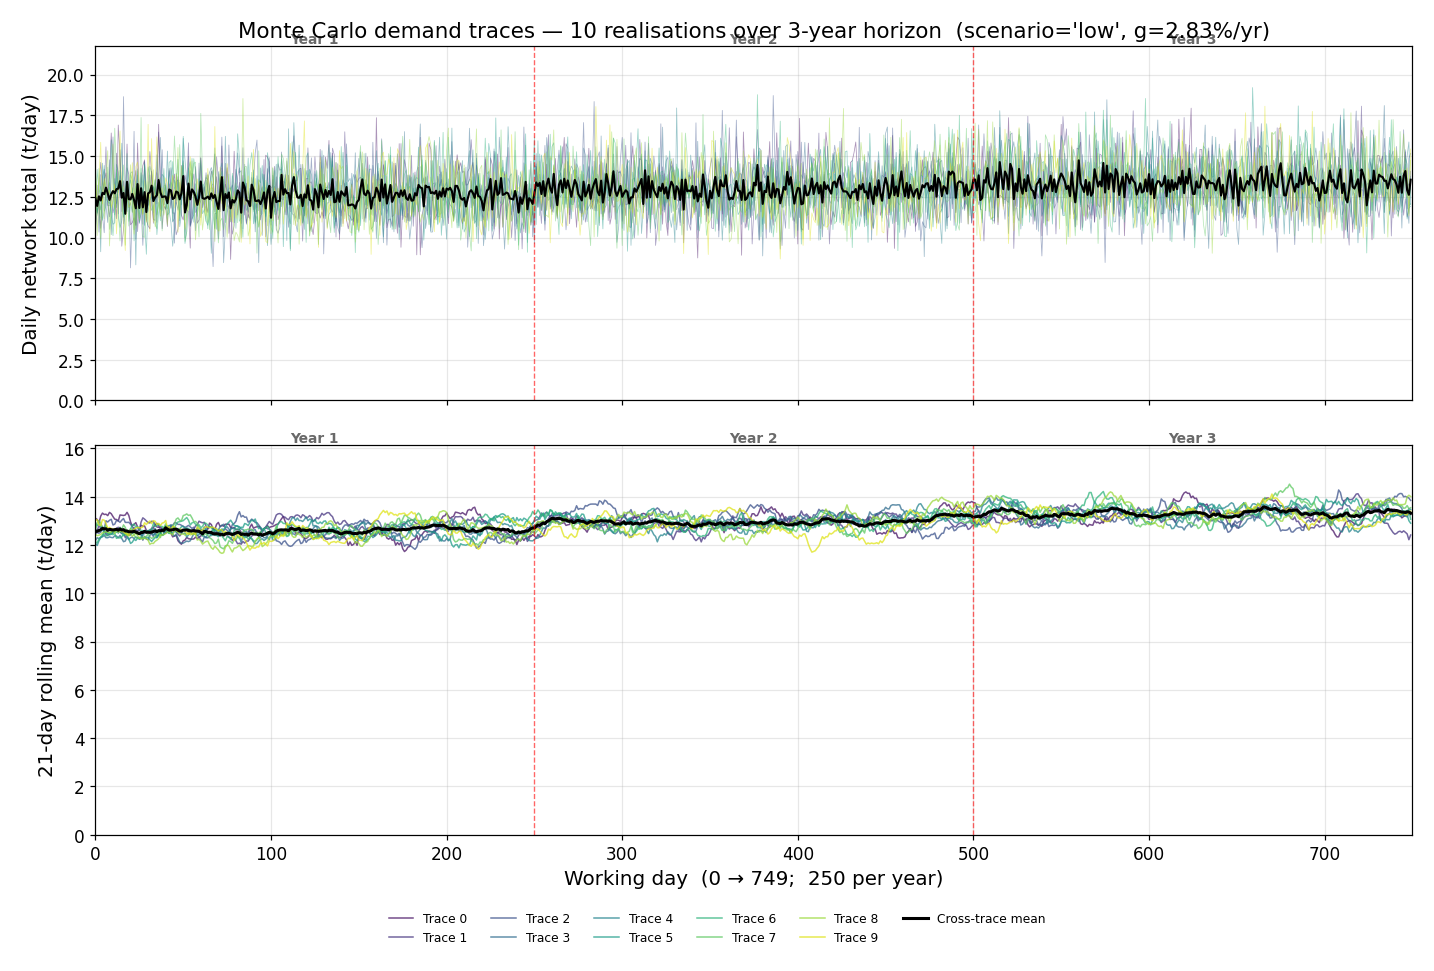

Trace overview plot saved to outputs\mc_traces_over_3y.png

Annual network total (tonnes) per trace:
  Trace  Year  1  Year  2  Year  3
     0      3,153    3,243    3,320
     1      3,185    3,235    3,299
     2      3,135    3,287    3,323
     3      3,120    3,245    3,324
     4      3,147    3,234    3,328
     5      3,147    3,246    3,353
     6      3,169    3,244    3,340
     7      3,145    3,224    3,345
     8      3,109    3,252    3,350
     9      3,154    3,200    3,307

  mean      3,146    3,241    3,329
  stdev        21       21       17


In [27]:
# =============================================================================
# MC TRACES OVER 3-YEAR HORIZON — overview plot
# =============================================================================
# Plots every trace's daily network-wide demand (summed across all zones) on
# one figure spanning the full 3-year planning horizon, with year boundaries.
#
# Two panels:
#   (top)    raw daily totals per trace — reveals stochastic variability
#   (bottom) 21-working-day rolling mean per trace + cross-trace mean — reveals
#            the underlying growth trend driven by the active scenario.

wdpy = CONFIG['demand']['working_days_per_year']            # 250
horizon_years = CONFIG['demand']['horizon_years']           # 3
horizon_days  = horizon_years * wdpy                        # 750
days = np.arange(horizon_days)

# Build a (n_traces, horizon_days) matrix of daily network totals (kg → tonnes)
n_traces = len(traces)
daily_matrix = np.zeros((n_traces, horizon_days))
for i, t in traces.items():
    per_day = t.groupby('trace_day')['weight_kg'].sum().reindex(days, fill_value=0.0)
    daily_matrix[i, :] = per_day.values
daily_matrix_t = daily_matrix / 1000.0   # tonnes/day

# Rolling mean (21-working-day window ≈ one calendar month) per trace
window = 21
def rolling_mean(arr, w):
    return pd.Series(arr).rolling(window=w, min_periods=1, center=True).mean().values
rolling_matrix_t = np.vstack([rolling_mean(daily_matrix_t[i], window) for i in range(n_traces)])

palette = plt.cm.viridis(np.linspace(0.05, 0.95, n_traces))

fig, axes = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1.1]})

# --- Top: raw daily totals -------------------------------------------------
ax = axes[0]
for i in range(n_traces):
    ax.plot(days, daily_matrix_t[i], linewidth=0.5, alpha=0.45,
            color=palette[i], label=f'Trace {i}')
ax.plot(days, daily_matrix_t.mean(axis=0), color='black', linewidth=1.4,
        label='Cross-trace mean')
ax.set_ylabel('Daily network total (t/day)')
ax.set_title(f'Monte Carlo demand traces — {n_traces} realisations over '
             f'{horizon_years}-year horizon  '
             f'(scenario={CONFIG["demand"]["active_growth_scenario"]!r}, '
             f'g={CONFIG["demand"]["annual_growth_rate"]*100:.2f}%/yr)')
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

# --- Bottom: rolling mean per trace + cross-trace mean ---------------------
ax2 = axes[1]
for i in range(n_traces):
    ax2.plot(days, rolling_matrix_t[i], linewidth=1.0, alpha=0.75,
             color=palette[i], label=f'Trace {i}')
ax2.plot(days, rolling_matrix_t.mean(axis=0), color='black', linewidth=2.0,
         label='Cross-trace mean')
ax2.set_xlabel(f'Working day  (0 → {horizon_days - 1};  {wdpy} per year)')
ax2.set_ylabel(f'{window}-day rolling mean (t/day)')
ax2.grid(alpha=0.3)
ax2.set_ylim(bottom=0)

# --- Year boundaries + labels on both panels -------------------------------
for ax_ in (ax, ax2):
    for y in range(1, horizon_years):
        ax_.axvline(y * wdpy, color='red', linestyle='--', linewidth=0.9, alpha=0.6)
    for y in range(horizon_years):
        ax_.text(y * wdpy + wdpy / 2, 1.0, f'Year {y + 1}',
                 transform=ax_.get_xaxis_transform(),
                 ha='center', va='bottom', fontsize=9,
                 color='dimgray', fontweight='bold')
    ax_.set_xlim(0, horizon_days)

# Single legend below the figure
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.02), frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 1])
# _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
    _y0, _y1 = _ax.get_ylim()
    if _y1 > _y0:
        _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
plt.savefig(OUTPUT_DIR / 'mc_traces_over_3y.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Trace overview plot saved to {OUTPUT_DIR / 'mc_traces_over_3y.png'}")

# --- Quick numeric summary printed below the plot --------------------------
yearly_per_trace = []
for i in range(n_traces):
    per_year = []
    for y in range(horizon_years):
        s, e = y * wdpy, (y + 1) * wdpy
        per_year.append(daily_matrix_t[i, s:e].sum())
    yearly_per_trace.append(per_year)
yearly_per_trace = np.array(yearly_per_trace)   # (n_traces, horizon_years)

print("\nAnnual network total (tonnes) per trace:")
header = "  Trace  " + "  ".join(f"Year {y+1:>2}" for y in range(horizon_years))
print(header)
for i in range(n_traces):
    row = "  " + f"{i:>4}    " + "  ".join(f"{yearly_per_trace[i, y]:>7,.0f}"
                                            for y in range(horizon_years))
    print(row)
print(f"\n  mean    " + "  ".join(f"{yearly_per_trace[:, y].mean():>7,.0f}"
                                    for y in range(horizon_years)))
print(f"  stdev   " + "  ".join(f"{yearly_per_trace[:, y].std():>7,.0f}"
                                  for y in range(horizon_years)))


## Module 9 — Technology ScenariosEach scenario is encapsulated in a `Scenario` dataclass that bundles all parametersdefined in Section 4.2 together with the relevant CAPEX, OPEX, maintenance, andemission settings.

In [29]:
# =============================================================================
# SCENARIO DATACLASS — bundles every parameter for one technology
# =============================================================================

@dataclass
class Scenario:
    name: str
    # Operational
    daily_hours: float
    availability: float
    energy_consumption: float       # L/km or kWh/km
    energy_unit_cost: float         # EUR/L or EUR/kWh
    energy_growth_pct: float
    co2_per_unit: float             # kg CO2 per L or per kWh
    labor_required: bool
    supervision_ratio: int          # 1 = one driver per vehicle; 5 = remote 1:5
    # CAPEX
    vehicle_cost: float
    infra_cost_per_vehicle: float
    depreciation_rate: float
    ze_writeoff_pct: float
    # Maintenance
    maint_scale: float
    maint_base: float
    maint_growth: float
    # OPEX shared
    saas_fee_per_year: float = 0.0  # Only AV uses this
    # Routing flexibility (Module 10)
    multi_depot: bool = False       # True = tour may start at hub A and end at hub B (AV only)
    can_recharge_intraday: bool = False  # True = BEV/AV recharge between tours

def build_scenarios(cfg: dict) -> Dict[str, Scenario]:
    scenarios = {}
    for name in ['ICEV', 'BEV', 'AV']:
        s = cfg['scenarios'][name]
        c = cfg['capex'][name]
        m = cfg['maintenance'][name]
        scenarios[name] = Scenario(
            name=name,
            daily_hours=s['daily_hours'],
            availability=s['availability'],
            energy_consumption=s['energy_consumption'],
            energy_unit_cost=s['energy_unit_cost'],
            energy_growth_pct=s['energy_growth_pct'],
            co2_per_unit=s['co2_per_unit'],
            labor_required=s['labor_required'],
            supervision_ratio=s['supervision_ratio'],
            vehicle_cost=c['vehicle_cost'],
            infra_cost_per_vehicle=c['infra_cost_per_vehicle'],
            depreciation_rate=c['depreciation_rate'],
            ze_writeoff_pct=c['ze_writeoff_pct'],
            maint_scale=m['scale'],
            maint_base=m['base'],
            maint_growth=m['growth'],
            saas_fee_per_year=cfg['opex']['saas_fee_per_av_eur'] if name == 'AV' else 0.0,
            multi_depot=(name == 'AV'),
            can_recharge_intraday=(name in ('BEV', 'AV')),
        )
    return scenarios

SCENARIOS = build_scenarios(CONFIG)
for name, s in SCENARIOS.items():
    print(f"\n--- {name} ---")
    print(f"  Daily hours: {s.daily_hours}, Availability: {s.availability}")
    print(f"  Energy: {s.energy_consumption:.4f} units/km @ €{s.energy_unit_cost}/unit")
    print(f"  CAPEX: €{s.vehicle_cost + s.infra_cost_per_vehicle:,.0f} "
          f"({s.depreciation_rate*100:.1f}% depreciation)")
    print(f"  Labour: {'driver' if s.labor_required else f'remote 1:{s.supervision_ratio}'}")


--- ICEV ---
  Daily hours: 8.0, Availability: 0.95
  Energy: 0.1747 units/km @ €1.58/unit
  CAPEX: €72,500 (15.0% depreciation)
  Labour: driver

--- BEV ---
  Daily hours: 8.0, Availability: 0.85
  Energy: 0.5000 units/km @ €0.167/unit
  CAPEX: €108,500 (19.8% depreciation)
  Labour: driver

--- AV ---
  Daily hours: 24.0, Availability: 0.9
  Energy: 0.4545 units/km @ €0.167/unit
  CAPEX: €133,500 (25.0% depreciation)
  Labour: remote 1:5


## Module 10 — Iterative Fleet SizingImplements the sizing relationship from Section 3.3.1:$$N_k = \left\lceil \frac{\sum_{i=1}^{m}\left[ W_{i,d}\cdot(1+\gamma)\right]}{H_{daily}\cdot\eta\cdot A_k} \right\rceil$$The fleet is sized so that the **120-hour SLA holds across all 10 traces** — i.e. onthe worst day of the worst trace the available vehicle-hours must cover the workload.

In [31]:
# =============================================================================
# FLEET SIZING — scenario-specific routing (Section 3.3 + new routing layer)
# =============================================================================
# Two routing modes (CONFIG['fleet_sizing']['routing_mode']):
#   'shuttle' : legacy single-zone hub→zone→hub round trips
#   'savings' : Clarke & Wright savings algorithm
#               ICEV — single-depot,  no intra-day recharge
#               BEV  — single-depot,  partial recharge between tours
#               AV   — MULTI-DEPOT (asymmetric start/end), recharge between tours
# Both modes return the same triple per (trace, day):
#   (vehicle_hours, vehicle_km, n_tours)
# fed downstream identically.
# =============================================================================

# ---------- Shuttle mode (legacy, kept for comparison) ----------------------
def daily_workload_shuttle(
    daily_demand: pd.DataFrame, zone_dist: pd.DataFrame,
    cfg: dict, scenario: Scenario,
) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """Return (vehicle_hours_per_day, km_per_day, tours_per_day) under shuttle."""
    cap   = cfg['fleet_sizing']['vehicle_capacity_kg']
    phi   = cfg['fleet_sizing']['load_factor_phi']
    eff_cap = cap * phi   # effective per-trip payload (v7 §4.3.1)
    speed = cfg['fleet_sizing']['avg_speed_kmh']
    svc_t = cfg['fleet_sizing']['service_time_per_stop_h']
    gamma = cfg['fleet_sizing']['safety_factor_gamma']

    merged = daily_demand.merge(
        zone_dist[['zone', 'round_trip_km']], on='zone', how='left'
    )
    merged['trips']     = np.ceil(merged['weight_kg'] / eff_cap).astype(int)
    merged['drive_h']   = merged['trips'] * merged['round_trip_km'] / speed
    merged['service_h'] = merged['trips'] * svc_t
    merged['vehicle_h'] = (merged['drive_h'] + merged['service_h']) * (1 + gamma)
    merged['km']        = merged['trips'] * merged['round_trip_km']
    vh = merged.groupby('trace_day')['vehicle_h'].sum()
    km = merged.groupby('trace_day')['km'].sum()
    # Total trips per day (each row in merged is one zone's daily pickup,
    # which decomposes into `trips` shuttle round trips).
    tours = merged.groupby('trace_day')['trips'].sum().astype(int)
    return vh, km, tours


# ---------- Savings mode ----------------------------------------------------
# A "tour" is a sequence of zone visits with a start hub and an end hub
# (start == end except for AV multi-depot).
# Tour-level invariants tracked:
#   load_kg, drive_km, drive_h, service_h, total_h, energy_kwh (BEV/AV)

def _tour_drive_km(start_hub_idx: int, end_hub_idx: int,
                   zone_seq_row_idx: List[int],
                   dist_ctx: dict) -> float:
    """Total drive km for a tour: hub_start → z1 → z2 → ... → zk → hub_end."""
    if not zone_seq_row_idx:
        return 0.0
    zh = dist_ctx['zone_hub_km']
    zz = dist_ctx['zone_zone_km']
    km = zh[zone_seq_row_idx[0], start_hub_idx]
    for a, b in zip(zone_seq_row_idx[:-1], zone_seq_row_idx[1:]):
        km += zz[a, b]
    km += zh[zone_seq_row_idx[-1], end_hub_idx]
    return float(km)


def _tour_metrics(start_h: int, end_h: int, zone_rows: List[int],
                  loads: List[float], cfg: dict, dist_ctx: dict) -> dict:
    speed = cfg['fleet_sizing']['avg_speed_kmh']
    svc_t = cfg['fleet_sizing']['service_time_per_stop_h']
    km = _tour_drive_km(start_h, end_h, zone_rows, dist_ctx)
    return {
        'start_hub': start_h,
        'end_hub': end_h,
        'zones': list(zone_rows),
        'load': float(sum(loads)),
        'km': km,
        'drive_h': km / speed,
        'service_h': len(zone_rows) * svc_t,
        'total_h': km / speed + len(zone_rows) * svc_t,
    }


def _build_tours_savings(
    day_demand: pd.DataFrame, scenario: Scenario,
    cfg: dict, dist_ctx: dict,
) -> List[dict]:
    """
    Clarke & Wright savings algorithm, scenario-aware.

    For ICEV/BEV (single-depot): each zone's nearest hub is start AND end.
                                  Merges allowed only if both routes share a hub.
    For AV (multi-depot): start and end hubs may differ. Optimal (start, end) =
                          (argmin zh[first_zone, :], argmin zh[last_zone, :]) —
                          interior path is hub-independent, so this is exact, not heuristic.
    Capacity gate: combined load ≤ vehicle_capacity_kg × φ.
    Time gate:    combined tour total_h ≤ scenario.daily_hours × η.

    PERFORMANCE NOTES (v8 rewrite):
      * Avoids the O(n_hubs²) inner scan on multi-depot merges — uses the
        decomposition described above. ~25× speedup on AV.
      * Caches sequence-interior km on each tour (precomputed when the tour
        is created) so merge candidates only pay O(1) for the join edge.
      * Uses local references for hot dict lookups inside the merge loop.
    """
    cap   = cfg['fleet_sizing']['vehicle_capacity_kg']
    phi   = cfg['fleet_sizing']['load_factor_phi']
    eff_cap = cap * phi
    eta   = cfg['fleet_sizing']['utilization_eta']
    speed = cfg['fleet_sizing']['avg_speed_kmh']
    svc_t = cfg['fleet_sizing']['service_time_per_stop_h']
    zh    = dist_ctx['zone_hub_km']
    zz    = dist_ctx['zone_zone_km']
    n_hubs = zh.shape[1]

    # Precompute, per zone-row, the nearest hub and its distance (vectorised)
    nearest_hub_per_zone = np.argmin(zh, axis=1)         # (n_zones,)
    min_zh_per_zone      = zh.min(axis=1)                # (n_zones,)

    def make_tour(start_h, end_h, zones, load, interior_km):
        """Lightweight tour dict; km = zh[first, sh] + interior + zh[last, eh]."""
        first, last = zones[0], zones[-1]
        km = zh[first, start_h] + interior_km + zh[last, end_h]
        n_stops = len(zones)
        return {
            'start_hub':     start_h,
            'end_hub':       end_h,
            'zones':         zones,           # tuple — immutable, faster
            'load':          load,
            'km':            km,
            'interior_km':   interior_km,     # cached: km between consecutive zones, no hubs
            'total_h':       km / speed + n_stops * svc_t,
            'n_stops':       n_stops,
        }

    def best_endpoints(zones):
        """Optimal (start_hub, end_hub) for AV multi-depot — exact O(1)."""
        first, last = zones[0], zones[-1]
        sh = int(np.argmin(zh[first]))
        eh = int(np.argmin(zh[last]))
        return sh, eh

    # 1) Initial single-zone tours, split so each tour load ≤ eff_cap
    tours: List[dict] = []
    multi_depot = scenario.multi_depot
    for _, row in day_demand.iterrows():
        zid = int(row['zone'])
        z_row = dist_ctx['zone_idx'][zid]
        rem = float(row['weight_kg'])
        nearest = int(nearest_hub_per_zone[z_row])
        while rem > 0:
            chunk = min(eff_cap, rem)
            tours.append(make_tour(nearest, nearest, (z_row,), chunk, 0.0))
            rem -= chunk

    # 2) Greedy savings merges
    tour_time_limit = scenario.daily_hours * eta

    def evaluate_merge(a, b):
        """Try concatenating a then b. Returns (saving, candidate-tour) or (None, None)."""
        if a['load'] + b['load'] > eff_cap:
            return None, None
        # Interior of merged sequence = a.interior + edge(a.last, b.first) + b.interior
        a_zones, b_zones = a['zones'], b['zones']
        join_edge = zz[a_zones[-1], b_zones[0]]
        new_interior = a['interior_km'] + join_edge + b['interior_km']
        new_zones = a_zones + b_zones
        if multi_depot:
            sh, eh = best_endpoints(new_zones)
        else:
            if a['start_hub'] != b['start_hub']:
                return None, None
            sh = eh = a['start_hub']
        cand = make_tour(sh, eh, new_zones, a['load'] + b['load'], new_interior)
        if cand['total_h'] > tour_time_limit:
            return None, None
        saving = (a['km'] + b['km']) - cand['km']
        return (saving, cand) if saving > 1e-6 else (None, None)

    # Loop: at each iteration find the best pair, merge, repeat.
    # This is still O(T³) worst-case but each inner step is now a few dict lookups
    # and one zz lookup, not 50 × _tour_drive_km calls.
    while True:
        n_tours = len(tours)
        best = None
        best_save = 1e-6
        for i in range(n_tours):
            ti = tours[i]
            for j in range(i + 1, n_tours):
                tj = tours[j]
                # Try i→j and j→i — even for single-depot these can differ
                # because the join edge zz[a.last, b.first] depends on which
                # tour goes first.
                s, c = evaluate_merge(ti, tj)
                if s is not None and s > best_save:
                    best_save, best = s, (i, j, c)
                s, c = evaluate_merge(tj, ti)
                if s is not None and s > best_save:
                    best_save, best = s, (i, j, c)
        if best is None:
            break
        i, j, new_tour = best
        hi, lo = (i, j) if i > j else (j, i)
        tours.pop(hi); tours.pop(lo)
        tours.append(new_tour)

    return tours


def _pack_tours_into_vehicles(
    tours: List[dict], scenario: Scenario, cfg: dict,
) -> Tuple[float, float, int, int]:
    """First-Fit-Decreasing pack of tours onto vehicles for the day.

    Returns (vehicle_hours_total, km_total, n_vehicles_used).

    BEV/AV: between consecutive tours on the same vehicle, add a partial recharge
    time = (km_consumed × kWh/km) / charger_kW.
    """
    if not tours:
        return 0.0, 0.0, 0, 0

    H = scenario.daily_hours
    eta = cfg['fleet_sizing']['utilization_eta']
    # Daily packing cap = H * eta (productive hours within one shift's worth of
    # operating window). Availability A is a fleet-level factor handled in the
    # sizing formula — NOT a within-day cap on a working vehicle. Earlier code
    # included A here, which double-counted it; v8 fixes that.
    daily_window = H * eta
    charger_kw = cfg['fleet_sizing']['charger_power_kw']

    # Sort tours by total_h descending (FFD)
    sorted_tours = sorted(tours, key=lambda t: -t['total_h'])
    vehicles: List[dict] = []   # each: {used_h, used_km}
    for t in sorted_tours:
        placed = False
        for v in vehicles:
            extra_h = t['total_h']
            if scenario.can_recharge_intraday and v['n_tours_done'] >= 1:
                # Recharge time depends on energy used in PREVIOUS tour
                last_km = v['last_tour_km']
                kwh = last_km * scenario.energy_consumption  # works for BEV/AV (kWh/km)
                extra_h += kwh / charger_kw
            if v['used_h'] + extra_h <= daily_window:
                v['used_h'] += extra_h
                v['used_km'] += t['km']
                v['last_tour_km'] = t['km']
                v['n_tours_done'] += 1
                placed = True
                break
        if not placed:
            # Open a new vehicle
            vehicles.append({
                'used_h': t['total_h'],
                'used_km': t['km'],
                'last_tour_km': t['km'],
                'n_tours_done': 1,
            })

    total_h = sum(v['used_h'] for v in vehicles)
    total_km = sum(v['used_km'] for v in vehicles)
    total_n_tours = sum(v['n_tours_done'] for v in vehicles)
    return total_h, total_km, len(vehicles), total_n_tours


def daily_workload_savings(
    daily_demand: pd.DataFrame, scenario: Scenario,
    cfg: dict, dist_ctx: dict,
) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
    """Return (vehicle_h, km, vehicles_needed, tours) per day under the savings policy."""
    gamma = cfg['fleet_sizing']['safety_factor_gamma']
    rows_h, rows_km, rows_v, rows_t = [], [], [], []
    for day, grp in daily_demand.groupby('trace_day'):
        tours = _build_tours_savings(grp, scenario, cfg, dist_ctx)
        h, km, nv, n_tours = _pack_tours_into_vehicles(tours, scenario, cfg)
        rows_h.append((day, h * (1 + gamma)))
        rows_km.append((day, km))
        rows_v.append((day, nv))
        rows_t.append((day, n_tours))
    if not rows_h:
        empty = pd.Series(dtype=float)
        return empty, empty, empty.astype(int), empty.astype(int)
    h_s  = pd.Series({d: v for d, v in rows_h}).sort_index()
    km_s = pd.Series({d: v for d, v in rows_km}).sort_index()
    v_s  = pd.Series({d: v for d, v in rows_v}).sort_index().astype(int)
    t_s  = pd.Series({d: v for d, v in rows_t}).sort_index().astype(int)
    return h_s, km_s, v_s, t_s


def apply_sla_deferral(
    trace: pd.DataFrame, cfg: dict,
) -> pd.DataFrame:
    """Deadline-aware deferral, identical for all scenarios.

    Algorithm: walk days in order, maintain per-zone backlog, force pickup
    when oldest backlog entry would age past `sla_window` tomorrow,
    otherwise hold below `threshold_kg`.

    Returns a DataFrame with the same columns (trace_day, zone, weight_kg).
    """
    if not cfg['fleet_sizing'].get('enable_sla_deferral', False):
        return trace
    if trace.empty:
        return trace

    sla_window = int(cfg['fleet_sizing']['sla_pickup_window_days'])
    threshold  = float(cfg['fleet_sizing']['consolidation_threshold_kg'])

    arrivals: Dict[int, Dict[int, float]] = {}
    for r in trace.itertuples(index=False):
        arrivals.setdefault(int(r.trace_day), {})
        z = int(r.zone)
        arrivals[int(r.trace_day)][z] = arrivals[int(r.trace_day)].get(z, 0.0) + float(r.weight_kg)

    backlog: Dict[int, List[Tuple[int, float]]] = {}   # zone -> list of (day_arrived, kg)
    out_rows = []
    last_day = int(trace['trace_day'].max())
    # Loop horizon must extend by (sla_window - 1) days past the last arrival
    # so that backlogs from late arrivals get forced before mass is lost.
    horizon_end = last_day + (sla_window - 1)

    for d in range(horizon_end + 1):
        # 1) Add today's arrivals to backlog
        for z, kg in arrivals.get(d, {}).items():
            backlog.setdefault(z, []).append((d, kg))

        # 2) Force pickups: any zone with backlog entry older than (sla_window - 1)
        #    must be picked up today or it would miss SLA tomorrow.
        forced = []
        for z, entries in backlog.items():
            if entries and (d - entries[0][0]) >= (sla_window - 1):
                forced.append(z)

        # 3) Voluntary pickups: zones with backlog ≥ threshold ride along today
        voluntary = [z for z, entries in backlog.items()
                      if z not in forced
                      and sum(kg for _, kg in entries) >= threshold]

        # 4) Emit one pickup row per zone selected today and clear its backlog
        for z in forced + voluntary:
            entries = backlog.pop(z)
            total_kg = sum(kg for _, kg in entries)
            out_rows.append({'trace_day': d, 'zone': z, 'weight_kg': total_kg})

    deferred = pd.DataFrame(out_rows, columns=['trace_day', 'zone', 'weight_kg'])
    # Mass-conservation sanity check (within 1 kg for floating-point safety)
    if not deferred.empty:
        delta = abs(deferred['weight_kg'].sum() - trace['weight_kg'].sum())
        assert delta < 1.0, f"SLA deferral lost {delta:.2f} kg of mass"
    return deferred


# ---------- Unified dispatcher ----------------------------------------------
def daily_workload(
    daily_demand: pd.DataFrame, zone_dist: pd.DataFrame,
    cfg: dict, scenario: Scenario, dist_ctx: dict,
    mode: Optional[str] = None,
) -> Dict[str, pd.Series]:
    """Returns dict with keys 'vh', 'km', 'vehicles' (vehicles only for savings).

    If SLA deferral is enabled (CONFIG['fleet_sizing']['enable_sla_deferral']),
    the trace is reshaped before per-day routing — same-day rows for low-kg
    zones are deferred onto fuller subsequent days, subject to the SLA window.
    """
    daily_demand = apply_sla_deferral(daily_demand, cfg)
    mode = mode or cfg['fleet_sizing']['routing_mode']
    if mode == 'shuttle':
        vh, km, tours = daily_workload_shuttle(daily_demand, zone_dist, cfg, scenario)
        # Shuttle has no packing step → vehicles series is empty by design.
        return {'vh': vh, 'km': km,
                 'vehicles': pd.Series(dtype=int),
                 'tours': tours}
    elif mode == 'savings':
        vh, km, nv, tours = daily_workload_savings(daily_demand, scenario, cfg, dist_ctx)
        return {'vh': vh, 'km': km, 'vehicles': nv, 'tours': tours}
    raise ValueError(f"Unknown routing_mode: {mode}")


# ---------- Fleet sizing across traces --------------------------------------
def size_fleet_for_trace(
    daily_vh: pd.Series,
    daily_vehicles: pd.Series,
    daily_kg: pd.Series,
    scenario: Scenario,
    cfg: dict,
    mode: str,
    daily_tours: Optional[pd.Series] = None,
) -> dict:
    """Worst-day fleet size for one trace, per the v7 thesis formula:

        N_k_formula = ceil( max_d sum_i W_{i,d} / (H_daily * (C * phi) * eta * A_k) )

    For 'savings' mode, the packing-based vehicle count from the routing
    layer is also a feasibility-aware bound. The chosen fleet size is then
    max(N_k_formula, N_k_packing).

    Returns a dict with all four diagnostic components so downstream code can
    show what actually drove the integer fleet size on each trace:
        {
            'formula_float':  continuous pre-ceiling formula value,
            'formula_n':      ceil(formula_float) — what demand alone requires,
            'packing_n':      max daily vehicles from savings packing (0 in shuttle),
            'fleet_size':     chosen = max(formula_n, packing_n),
            'driver':         'formula' | 'packing' | 'tie',
        }
    """
    eta = cfg['fleet_sizing']['utilization_eta']
    phi = cfg['fleet_sizing']['load_factor_phi']
    C   = cfg['fleet_sizing']['vehicle_capacity_kg']
    A   = scenario.availability

    # ------------------------------------------------------------------
    # Empirical H_daily (trips per vehicle per day).
    # In the v7 thesis formula H_daily appears as the throughput frequency,
    # not as raw operating hours. We derive it from the routing outcome on
    # the worst-case demand day: on day d* the routing used N_v vehicles
    # to run N_t tours, so trips_per_v_per_day = N_t / N_v.
    # When the routing can't produce that (shuttle mode, empty trace,
    # etc.), we fall back to a sensible default of 1 trip/v/day so the
    # formula still produces a value.
    # ------------------------------------------------------------------
    worst_day_tours    = 0
    worst_day_vehicles = 0
    if daily_tours is not None and len(daily_tours) > 0 \
            and daily_vehicles is not None and len(daily_vehicles) > 0:
        # Worst-case day is the one with the most vehicles required.
        idx_worst = daily_vehicles.idxmax()
        worst_day_vehicles = int(daily_vehicles.loc[idx_worst])
        worst_day_tours    = int(daily_tours.loc[idx_worst])
        if worst_day_vehicles > 0:
            H_empirical = worst_day_tours / worst_day_vehicles
        else:
            H_empirical = 1.0
    elif daily_tours is not None and len(daily_tours) > 0:
        # Shuttle mode: there's no vehicle packing, so define H_empirical
        # as average tours per day (one vehicle per tour by construction).
        H_empirical = float(daily_tours.mean()) if len(daily_tours) else 1.0
        worst_day_tours = int(daily_tours.max())
        worst_day_vehicles = worst_day_tours  # shuttle = 1 vehicle per tour
    else:
        H_empirical = 1.0

    # Formula component using the empirical H_daily
    kg_per_vehicle_day = H_empirical * (C * phi) * eta * A
    if kg_per_vehicle_day <= 0 or daily_kg is None or len(daily_kg) == 0:
        formula_float = 0.0
        formula_n = 0
    else:
        formula_float = float(daily_kg.max() / kg_per_vehicle_day)
        formula_n = int(np.ceil(formula_float))

    # Packing component (only meaningful for savings mode)
    if mode == 'savings' and len(daily_vehicles) > 0:
        packing_n = int(daily_vehicles.max())
    else:
        packing_n = 0

    chosen = max(formula_n, packing_n)
    if mode == 'savings':
        if packing_n > formula_n:   driver = 'packing'
        elif formula_n > packing_n: driver = 'formula'
        else:                       driver = 'tie'
    else:
        driver = 'formula'

    if kg_per_vehicle_day <= 0:
        chosen = 10**9

    # ------------------------------------------------------------------
    # Time-packing diagnostic: continuous "vehicle-days of work needed"
    # on the worst-case day, expressed in units of one vehicle's
    # productive daily window (H × η).
    #
    #     time_packing_float = max(daily_vh) / (H × η)
    #
    # The ceiling of this is approximately packing_n — they can differ
    # slightly because FFD packing isn't optimal (sometimes you need
    # one extra vehicle just to hold a single stray tour).
    #
    # fleet_size_float_combined = max(formula_float, time_packing_float)
    # is the continuous version of the chosen integer; its ceiling is
    # approximately max(formula_n, packing_n) = chosen.
    # ------------------------------------------------------------------
    H_shift = scenario.daily_hours      # raw operating hours per day (8/16/24)
    daily_window_h = H_shift * eta      # productive hours per vehicle per day
    if daily_window_h > 0 and daily_vh is not None and len(daily_vh) > 0:
        time_packing_float = float(daily_vh.max() / daily_window_h)
    else:
        time_packing_float = 0.0
    fleet_size_float_combined = max(formula_float, time_packing_float)

    return {
        'formula_float':              formula_float,
        'formula_n':                  formula_n,
        'packing_n':                  packing_n,
        'fleet_size':                 chosen,
        'driver':                     driver,
        'H_empirical':                float(H_empirical),
        'worst_day_tours':            int(worst_day_tours),
        'worst_day_vehicles':         int(worst_day_vehicles),
        'time_packing_float':         time_packing_float,
        'fleet_size_float_combined':  fleet_size_float_combined,
    }


def size_fleet_robust(
    traces: Dict[int, pd.DataFrame], zone_dist: pd.DataFrame,
    cfg: dict, scenario: Scenario, dist_ctx: dict,
    mode: Optional[str] = None,
) -> Tuple[int, pd.DataFrame]:
    mode = mode or cfg['fleet_sizing']['routing_mode']
    rows = []
    for i, t in traces.items():
        wl = daily_workload(t, zone_dist, cfg, scenario, dist_ctx, mode=mode)
        # Use the *post-deferral* daily kg series for the v7 formula's RHS so
        # that the formula's W_{i,d} matches what was actually routed today.
        deferred_t = apply_sla_deferral(t, cfg)
        daily_kg = deferred_t.groupby('trace_day')['weight_kg'].sum()
        sz = size_fleet_for_trace(wl['vh'], wl['vehicles'], daily_kg,
                                    scenario, cfg, mode,
                                    daily_tours=wl.get('tours'))
        rows.append({
            'trace':                     i,
            'avg_daily_vh':              wl['vh'].mean() if len(wl['vh']) else 0.0,
            'max_daily_vh':              wl['vh'].max() if len(wl['vh']) else 0.0,
            'avg_daily_km':              wl['km'].mean() if len(wl['km']) else 0.0,
            'max_daily_kg':              float(daily_kg.max()) if len(daily_kg) else 0.0,
            'formula_float':             sz['formula_float'],
            'formula_n':                 sz['formula_n'],
            'packing_n':                 sz['packing_n'],
            'fleet_size':                sz['fleet_size'],
            'driver':                    sz['driver'],
            'H_empirical':               sz['H_empirical'],
            'worst_day_tours':           sz['worst_day_tours'],
            'worst_day_vehicles':        sz['worst_day_vehicles'],
            'time_packing_float':        sz['time_packing_float'],
            'fleet_size_float_combined': sz['fleet_size_float_combined'],
        })
    df = pd.DataFrame(rows)
    return int(df['fleet_size'].max()), df


# =============================================================================
# Run sizing for the ACTIVE routing mode
# =============================================================================
ACTIVE_MODE = CONFIG['fleet_sizing']['routing_mode']
print(f"Sizing fleets across all traces and scenarios "
      f"(routing_mode='{ACTIVE_MODE}')...\n")
fleet_sizes = {}
fleet_size_details = {}
for name, scenario in SCENARIOS.items():
    n, detail = size_fleet_robust(
        traces, zone_distances, CONFIG, scenario, DIST_CTX, mode=ACTIVE_MODE,
    )
    fleet_sizes[name] = n
    fleet_size_details[name] = detail
    print(f"=== {name} ===")
    print(detail.round(1).to_string(index=False))
    print(f"  → Robust fleet size: N_{name} = {n}")
    print()

print("Summary (active mode):")
for name, n in fleet_sizes.items():
    print(f"  {name}: {n} vehicles")


Sizing fleets across all traces and scenarios (routing_mode='savings')...

=== ICEV ===
 trace  avg_daily_vh  max_daily_vh  avg_daily_km  max_daily_kg  formula_float  formula_n  packing_n  fleet_size  driver  H_empirical  worst_day_tours  worst_day_vehicles  time_packing_float  fleet_size_float_combined
     0          20.0          64.2         693.1       47959.9           10.8         11         12          12 packing          1.1               13                  12                10.0                       10.8
     1          19.9          62.3         685.5       41968.1            9.4         10         12          12 packing          1.1               13                  12                 9.7                        9.7
     2          20.2          61.7         699.8       43017.2            9.6         10         11          11 packing          1.1               12                  11                 9.6                        9.6
     3          19.9          57.8         6

## Module 11 — Lifecycle DynamicsSection 3.3.2 specifies three coupled mechanisms:- **Stochastic maintenance**: $m_{it} = \text{scale}\cdot(\text{base} + \text{growth}\cdot i) + \varepsilon$- **Reducing-balance depreciation**: $S_n = P\cdot(1-d)^n$- **Optimal Disposal Point (ODP)**: minimum of EUAC over service lifeMaintenance values are interpreted as a **fraction of annual reference cost**(`annual_km_reference × variable cost per km`) so that a value of `0.20`means 20% of the reference annual operating cost. This is the Ahani et al.formulation referenced in the thesis.**ZE write-off treatment.** The Belgian 40 % zero-emission additional investmentdeduction is modelled as a **one-shot tax shield** at the moment of purchase:$$\text{net cash CAPEX} = P \cdot (1 - \text{ze\_writeoff\_pct} \times \text{corporate\_tax\_rate})$$The salvage value is computed from the *full* market price $P$, because resalemarkets do not care about a buyer's tax position. (Reducing the depreciablebasis instead of treating the deduction as a tax shield produces nonsensical*negative* EUAC values at year 1, because salvage would exceed cash CAPEX.)

In [33]:
# =============================================================================
# LIFECYCLE DYNAMICS — maintenance, depreciation, ODP
# =============================================================================

def annual_maintenance_cost(
    age_years: int, scenario: Scenario, ref_annual_cost: float, noise_rng=None
) -> float:
    """Maintenance fraction × reference annual cost, with optional noise."""
    base_frac = scenario.maint_scale * (scenario.maint_base + scenario.maint_growth * age_years)
    eps = 0.0
    if noise_rng is not None:
        eps = noise_rng.normal(0, CONFIG['maintenance']['noise_sigma'])
    return max(0.0, (base_frac + eps) * ref_annual_cost)

def salvage_value(initial_capex: float, age_years: int, dep_rate: float) -> float:
    return initial_capex * ((1 - dep_rate) ** age_years)

def equivalent_uniform_annual_cost(
    capex_now: float,
    annual_costs: List[float],
    salvage_at_end: float,
    discount_rate: float,
) -> float:
    """Convert NPV of (CAPEX − salvage + annual costs) into an annualised figure."""
    n = len(annual_costs)
    if n == 0:
        return capex_now
    # NPV of variable annual costs (end-of-year convention)
    npv_op = sum(c / (1 + discount_rate) ** (t + 1) for t, c in enumerate(annual_costs))
    # PV of salvage at year n
    pv_salvage = salvage_at_end / (1 + discount_rate) ** n
    npv_total = capex_now + npv_op - pv_salvage
    # Capital Recovery Factor: A = NPV × i(1+i)^n / [(1+i)^n − 1]
    if discount_rate == 0:
        return npv_total / n
    crf = discount_rate * (1 + discount_rate) ** n / ((1 + discount_rate) ** n - 1)
    return npv_total * crf

def find_optimal_disposal_point(
    scenario: Scenario, cfg: dict, ref_annual_cost: float, max_life: int = 12
) -> Tuple[int, float, pd.DataFrame]:
    """Search the service life that minimises EUAC of CAPEX + maintenance.

    The Belgian zero-emission investment write-off is modelled as a one-shot
    *tax shield* at time of purchase:
        net_cash_capex = capex × (1 − ze_writeoff_pct × corporate_tax_rate)
    The salvage value is computed from the *full* market price (ze write-off
    does not affect resale value).
    """
    rng = np.random.default_rng(SEEDS['maintenance_noise'])
    capex = scenario.vehicle_cost + scenario.infra_cost_per_vehicle
    tax_rate = cfg['lifecycle']['corporate_tax_rate']
    tax_shield = capex * scenario.ze_writeoff_pct * tax_rate
    capex_after_subsidy = capex - tax_shield
    rows = []
    for life in range(1, max_life + 1):
        annual = [
            annual_maintenance_cost(yr, scenario, ref_annual_cost, rng)
            for yr in range(1, life + 1)
        ]
        salvage = salvage_value(capex, life, scenario.depreciation_rate)  # from full price
        eu = equivalent_uniform_annual_cost(
            capex_now=capex_after_subsidy,
            annual_costs=annual,
            salvage_at_end=salvage,
            discount_rate=cfg['lifecycle']['discount_rate_i'],
        )
        rows.append({'service_life': life, 'EUAC_capex_maint': eu, 'salvage': salvage})
    df = pd.DataFrame(rows)
    best_life = int(df.loc[df['EUAC_capex_maint'].idxmin(), 'service_life'])
    best_euac = float(df['EUAC_capex_maint'].min())
    return best_life, best_euac, df

# Estimate a reference annual operating cost (used to scale maintenance)
def reference_annual_cost(scenario: Scenario, cfg: dict, annual_km: float) -> float:
    """Per-vehicle annual variable cost excluding maintenance and labour."""
    energy_cost = annual_km * scenario.energy_consumption * scenario.energy_unit_cost
    viapass = annual_km * cfg['opex']['viapass_per_km']
    return energy_cost + viapass + cfg['opex']['insurance_per_year']

# Compute ODP for each scenario
print("Computing Optimal Disposal Point for each scenario...\n")
ANNUAL_KM_REF = CONFIG['maintenance']['annual_km_reference']
odp_results = {}
for name, scenario in SCENARIOS.items():
    ref_cost = reference_annual_cost(scenario, CONFIG, ANNUAL_KM_REF)
    life, euac, search_df = find_optimal_disposal_point(
        scenario, CONFIG, ref_cost, max_life=CONFIG['lifecycle']['max_service_life_years']
    )
    odp_results[name] = {
        'service_life': life,
        'EUAC_capex_maint': euac,
        'reference_annual_cost': ref_cost,
        'search': search_df,
    }
    print(f"=== {name} ===")
    print(f"  Reference annual cost (energy+viapass+ins): €{ref_cost:,.0f}")
    print(f"  Optimal service life: {life} years")
    print(f"  EUAC (CAPEX + maintenance): €{euac:,.0f}/year")
    print()

Computing Optimal Disposal Point for each scenario...

=== ICEV ===
  Reference annual cost (energy+viapass+ins): €12,521
  Optimal service life: 12 years
  EUAC (CAPEX + maintenance): €15,744/year

=== BEV ===
  Reference annual cost (energy+viapass+ins): €6,745
  Optimal service life: 12 years
  EUAC (CAPEX + maintenance): €12,749/year

=== AV ===
  Reference annual cost (energy+viapass+ins): €6,517
  Optimal service life: 12 years
  EUAC (CAPEX + maintenance): €15,429/year



## Module 12 — Full TCO and EUAC SynthesisCombines per-vehicle EUAC with **fleet-level OPEX**: energy, labour, road tolls,SaaS fees, and insurance. The result is the total internal annual cost of owningand running the fleet for the planning horizon.

In [35]:
# =============================================================================
# FLEET-LEVEL TCO / EUAC SYNTHESIS
# =============================================================================

def average_daily_km_per_vehicle(
    traces: Dict[int, pd.DataFrame],
    zone_dist: pd.DataFrame,
    fleet_size: int,
    cfg: dict,
    scenario: Scenario = None,
    dist_ctx: dict = None,
    mode: Optional[str] = None,
) -> float:
    """Mean daily kilometres per vehicle across all traces.

    Uses the active routing mode (shuttle or savings). When ``scenario``
    and ``dist_ctx`` are provided the savings router is consulted; otherwise
    falls back to the legacy shuttle formula.
    """
    mode = mode or cfg['fleet_sizing']['routing_mode']
    if mode == 'savings' and scenario is not None and dist_ctx is not None:
        per_trace = []
        for t in traces.values():
            wl = daily_workload(t, zone_dist, cfg, scenario, dist_ctx, mode='savings')
            per_trace.append(wl['km'].mean() if len(wl['km']) else 0.0)
        return float(np.mean(per_trace)) / max(fleet_size, 1)
    # Shuttle fallback
    cap = cfg['fleet_sizing']['vehicle_capacity_kg']
    total_km_per_day = []
    for t in traces.values():
        merged = t.merge(zone_dist[['zone', 'round_trip_km']], on='zone', how='left')
        merged['trips'] = np.ceil(merged['weight_kg'] / cap)
        merged['km'] = merged['trips'] * merged['round_trip_km']
        per_day = merged.groupby('trace_day')['km'].sum()
        total_km_per_day.append(per_day.mean())
    return float(np.mean(total_km_per_day)) / max(fleet_size, 1)

def annual_labour_cost(scenario: Scenario, fleet_size: int, cfg: dict) -> float:
    if not scenario.labor_required and scenario.supervision_ratio > 1:
        # AV: remote operators (1 operator per `supervision_ratio` vehicles).
        # Each operator works one 8 h shift, 250 days/year. A 24/7 AV fleet
        # therefore needs ceil(daily_hours / 8) overlapping operator shifts to
        # achieve continuous coverage. Without this scaling the AV labour cost
        # is understated by a factor of (daily_hours / 8).
        operators_per_shift = math.ceil(fleet_size / scenario.supervision_ratio)
        n_shifts = math.ceil(scenario.daily_hours / 8)
        operators = operators_per_shift * n_shifts
        wage = cfg['opex']['gross_hourly_wage_eur'] * cfg['opex']['wage_multiplier']
        return operators * wage * 8 * 250
    if not scenario.labor_required:
        return 0.0
    # ICEV/BEV: one driver per shift; one shift = 8 h. daily_hours = 16 means
    # two drivers per vehicle per day, so labour scales linearly with daily_hours.
    wage = cfg['opex']['gross_hourly_wage_eur'] * cfg['opex']['wage_multiplier']
    annual_h = scenario.daily_hours * 250
    return fleet_size * wage * annual_h

def fleet_annual_opex(
    scenario: Scenario, fleet_size: int, daily_km_per_vehicle: float, cfg: dict
) -> Dict[str, float]:
    annual_km_total = daily_km_per_vehicle * 250 * fleet_size
    energy = annual_km_total * scenario.energy_consumption * scenario.energy_unit_cost
    viapass = annual_km_total * cfg['opex']['viapass_per_km']
    insurance = fleet_size * cfg['opex']['insurance_per_year']
    saas = fleet_size * scenario.saas_fee_per_year
    labour = annual_labour_cost(scenario, fleet_size, cfg)
    return {
        'energy': energy,
        'viapass': viapass,
        'insurance': insurance,
        'saas': saas,
        'labour': labour,
        'total_opex': energy + viapass + insurance + saas + labour,
        'annual_km_total': annual_km_total,
    }

def fleet_capex_euac(scenario: Scenario, fleet_size: int, life_years: int, cfg: dict) -> float:
    """EUAC of CAPEX + maintenance only (capital recovery + salvage), summed over fleet.

    Same tax-shield treatment of ZE write-off as in find_optimal_disposal_point.
    """
    capex_per_vehicle = scenario.vehicle_cost + scenario.infra_cost_per_vehicle
    tax_rate = cfg['lifecycle']['corporate_tax_rate']
    tax_shield = capex_per_vehicle * scenario.ze_writeoff_pct * tax_rate
    capex_after_subsidy = capex_per_vehicle - tax_shield
    salvage = salvage_value(capex_per_vehicle, life_years, scenario.depreciation_rate)
    rng = np.random.default_rng(SEEDS['maintenance_noise'])
    ref_cost = reference_annual_cost(scenario, cfg, ANNUAL_KM_REF)
    annual_maint = [
        annual_maintenance_cost(y, scenario, ref_cost, rng) for y in range(1, life_years + 1)
    ]
    eu_per_vehicle = equivalent_uniform_annual_cost(
        capex_now=capex_after_subsidy,
        annual_costs=annual_maint,
        salvage_at_end=salvage,
        discount_rate=cfg['lifecycle']['discount_rate_i'],
    )
    return eu_per_vehicle * fleet_size

# Synthesise fleet-level numbers
print("Synthesising fleet-level TCO components...\n")
tco_results = {}
for name, scenario in SCENARIOS.items():
    n = fleet_sizes[name]
    life = odp_results[name]['service_life']
    daily_km = average_daily_km_per_vehicle(
        traces, zone_distances, n, CONFIG,
        scenario=scenario, dist_ctx=DIST_CTX,
    )
    capex_euac = fleet_capex_euac(scenario, n, life, CONFIG)
    opex = fleet_annual_opex(scenario, n, daily_km, CONFIG)
    tco_results[name] = {
        'fleet_size': n,
        'service_life_years': life,
        'daily_km_per_vehicle': daily_km,
        'capex_euac': capex_euac,
        **opex,
        'EUAC_internal': capex_euac + opex['total_opex'],
    }
    print(f"=== {name} (N={n}, life={life}y, {daily_km:.0f} km/vehicle/day) ===")
    print(f"  CAPEX EUAC (incl. maintenance): €{capex_euac:,.0f}")
    print(f"  Energy:    €{opex['energy']:,.0f}")
    print(f"  Labour:    €{opex['labour']:,.0f}")
    print(f"  Viapass:   €{opex['viapass']:,.0f}")
    print(f"  Insurance: €{opex['insurance']:,.0f}")
    print(f"  SaaS:      €{opex['saas']:,.0f}")
    print(f"  → Total EUAC_internal: €{capex_euac + opex['total_opex']:,.0f}/year")
    print()

Synthesising fleet-level TCO components...

=== ICEV (N=12, life=12y, 58 km/vehicle/day) ===
  CAPEX EUAC (incl. maintenance): €185,490
  Energy:    €47,917
  Labour:    €637,704
  Viapass:   €10,069
  Insurance: €30,000
  SaaS:      €0
  → Total EUAC_internal: €911,180/year

=== BEV (N=14, life=12y, 50 km/vehicle/day) ===
  CAPEX EUAC (incl. maintenance): €176,319
  Energy:    €14,495
  Labour:    €743,988
  Viapass:   €10,069
  Insurance: €35,000
  SaaS:      €0
  → Total EUAC_internal: €979,871/year

=== AV (N=7, life=12y, 90 km/vehicle/day) ===
  CAPEX EUAC (incl. maintenance): €106,962
  Energy:    €11,927
  Labour:    €318,852
  Viapass:   €9,113
  Insurance: €17,500
  SaaS:      €21,000
  → Total EUAC_internal: €485,353/year



## Module 13 — Atmospheric External Cost (AEC)Section 3.4.2 / 5.4.3: Well-to-Wheel CO₂ emissions are monetised at the EU ETS22026 shadow price (€25/tonne by default).

In [37]:
# =============================================================================
# ATMOSPHERIC EXTERNAL COST — Well-to-Wheel monetisation
# =============================================================================

def annual_co2_tonnes(scenario: Scenario, annual_km_total: float) -> float:
    """Total annual CO2 in tonnes for the entire fleet at this distance."""
    if scenario.energy_consumption == 0:
        return 0.0
    energy_units = annual_km_total * scenario.energy_consumption  # L or kWh
    co2_kg = energy_units * scenario.co2_per_unit
    return co2_kg / 1000.0

def annual_aec(scenario: Scenario, annual_km_total: float, cfg: dict) -> Dict[str, float]:
    co2_t = annual_co2_tonnes(scenario, annual_km_total)
    cost_co2 = co2_t * cfg['external_costs']['co2_price_eur_per_tonne']
    return {
        'co2_tonnes': co2_t,
        'aec_co2': cost_co2,
        'total_aec': cost_co2,
    }

print("Computing Atmospheric External Cost for each scenario...\n")
aec_results = {}
for name, scenario in SCENARIOS.items():
    annual_km_total = tco_results[name]['annual_km_total']
    aec = annual_aec(scenario, annual_km_total, CONFIG)
    aec_results[name] = aec
    print(f"=== {name} ===")
    print(f"  Annual fleet km:   {annual_km_total:,.0f}")
    print(f"  Annual CO2:        {aec['co2_tonnes']:.1f} tonnes")
    print(f"  AEC (CO2 @ €{CONFIG['external_costs']['co2_price_eur_per_tonne']}/t): "
          f"€{aec['aec_co2']:,.0f}/year")
    print()

Computing Atmospheric External Cost for each scenario...

=== ICEV ===
  Annual fleet km:   173,596
  Annual CO2:        79.8 tonnes
  AEC (CO2 @ €25.0/t): €1,994/year

=== BEV ===
  Annual fleet km:   173,596
  Annual CO2:        40.8 tonnes
  AEC (CO2 @ €25.0/t): €1,020/year

=== AV ===
  Annual fleet km:   157,119
  Annual CO2:        33.6 tonnes
  AEC (CO2 @ €25.0/t): €839/year



## Module 13b — Shuttle-mode comparison run

Re-runs fleet sizing + EUAC under `routing_mode='shuttle'` and stores the results in a parallel dict (`results_by_mode`). The plots in Module 15 still show the **active** mode; Module 15b plots the **comparison** between the two modes side by side.

This cell only does anything useful when both modes have been run. It's safe to skip if you want a single-mode run — Module 15b will detect the missing data and fall back to a single-mode plot.


In [39]:
# =============================================================================
# Run BOTH routing modes and store side by side for Module 15b comparison.
# =============================================================================
def run_full_pipeline_for_mode(mode: str) -> dict:
    """Run sizing + OPEX + AEC for every scenario under the chosen routing mode.

    Returns a dict {scenario_name: {fleet_size, daily_km_per_vehicle, capex_euac,
                                     opex (dict), aec (dict), EUAC_internal,
                                     EUAC_total, CO2_t}}.
    Reuses helpers from Modules 10–13.
    """
    out = {}
    for name, scenario in SCENARIOS.items():
        n, _detail = size_fleet_robust(traces, zone_distances, CONFIG,
                                        scenario, DIST_CTX, mode=mode)
        # Pull the v7 formula float + packing breakdown so the case-level
        # summary can show which constraint drove the chosen N_k. All cost
        # calculations continue to use the integer `n`.
        if not _detail.empty:
            _chosen_row = _detail.loc[_detail['fleet_size'].idxmax()]
            _n_float       = float(_chosen_row.get('formula_float', n))
            _formula_n     = int(_chosen_row.get('formula_n', n))
            _packing_n     = int(_chosen_row.get('packing_n', 0))
            _driver        = str(_chosen_row.get('driver', 'formula'))
            _H_empirical   = float(_chosen_row.get('H_empirical', 1.0))
            _worst_tours   = int(_chosen_row.get('worst_day_tours', 0))
            _worst_vehs    = int(_chosen_row.get('worst_day_vehicles', 0))
            _time_pack     = float(_chosen_row.get('time_packing_float', 0.0))
            _combined      = float(_chosen_row.get('fleet_size_float_combined', _n_float))
        else:
            _n_float, _formula_n, _packing_n, _driver = float(n), int(n), 0, 'formula'
            _H_empirical, _worst_tours, _worst_vehs = 1.0, 0, 0
            _time_pack, _combined = 0.0, float(n)

        life = odp_results[name]['service_life']
        daily_km = average_daily_km_per_vehicle(
            traces, zone_distances, n, CONFIG,
            scenario=scenario, dist_ctx=DIST_CTX, mode=mode,
        )
        capex_euac = fleet_capex_euac(scenario, n, life, CONFIG)
        opex = fleet_annual_opex(scenario, n, daily_km, CONFIG)
        annual_km_total = opex['annual_km_total']
        aec = annual_aec(scenario, annual_km_total, CONFIG)
        out[name] = {
            'fleet_size':                n,
            'fleet_size_float':          _n_float,
            'formula_n':                 _formula_n,
            'packing_n':                 _packing_n,
            'driver':                    _driver,
            'H_empirical':               _H_empirical,
            'worst_day_tours':           _worst_tours,
            'worst_day_vehicles':        _worst_vehs,
            'time_packing_float':        _time_pack,
            'fleet_size_float_combined': _combined,
            'service_life_years':        life,
            'daily_km_per_vehicle': daily_km,
            'capex_euac': capex_euac,
            'energy': opex['energy'], 'labour': opex['labour'],
            'viapass': opex['viapass'], 'insurance': opex['insurance'],
            'saas': opex['saas'],
            'EUAC_internal': capex_euac + opex['total_opex'],
            'AEC_co2': aec['aec_co2'],
            'EUAC_total': capex_euac + opex['total_opex'] + aec['total_aec'],
            'CO2_t': aec['co2_tonnes'],
            'annual_km_total': annual_km_total,
        }
    return out


print("Running both routing modes for comparison plot...\n")
results_by_mode = {}
if not CONFIG['fleet_sizing'].get('run_shuttle_comparison', False):
    print("  CONFIG['fleet_sizing']['run_shuttle_comparison'] = False — skipping.")
    print("  (Module 15b will detect this and fall back to a single-mode plot.)")
else:
    for mode in ('shuttle', 'savings'):
        print(f"  --- mode={mode} ---")
        results_by_mode[mode] = run_full_pipeline_for_mode(mode)
        for name, r in results_by_mode[mode].items():
            print(f"    {name:5s}  N={r['fleet_size']:>3}  "
                  f"km/veh/day={r['daily_km_per_vehicle']:>5.0f}  "
                  f"EUAC_total=€{r['EUAC_total']:,.0f}")
        print()


Running both routing modes for comparison plot...

  CONFIG['fleet_sizing']['run_shuttle_comparison'] = False — skipping.
  (Module 15b will detect this and fall back to a single-mode plot.)


## Module 13c — SLA-deferral comparison run

Re-runs the pipeline with `enable_sla_deferral` flipped, populating `results_by_deferral = {True: {...}, False: {...}}`. Module 15c (next plot) consumes this to show side-by-side bars: "with deferral" vs "without". This is the thesis's evidence that the 5-day SLA window is a meaningful flexibility lever, not just a passive deadline.

**What to expect in the comparison:**
* **Daily km per vehicle ↓** — fewer near-empty trips, denser tours.
* **OPEX (energy, viapass) ↓** and **CO₂ ↓** — same kg moved with fewer km.
* **Fleet size N may go UP** — consolidation makes peak days heavier, and the v7 formula sizes off the worst-day kg. This is a real and interesting trade-off, not a bug: deferral trades CAPEX for OPEX.
* **Net EUAC_total** — usually drops, but it's an empirical question whether the OPEX/AEC saving offsets the extra CAPEX. That's exactly what the comparison figure reveals.

Skip with `CONFIG['fleet_sizing']['run_deferral_comparison'] = False`.


In [41]:
# =============================================================================
# Run pipeline with deferral on AND off, store side by side for Module 15c.
# =============================================================================
# Toggle off for production runs to halve the wall-clock; on by default to
# generate the comparison figure for the thesis.
CONFIG['fleet_sizing'].setdefault('run_deferral_comparison', False)  # case ladder (Module 16) covers this

results_by_deferral = {}
if not CONFIG['fleet_sizing']['run_deferral_comparison']:
    print("CONFIG['fleet_sizing']['run_deferral_comparison'] = False — skipping.")
    print("(Module 15c will detect this and skip the comparison plot.)")
else:
    original_flag = CONFIG['fleet_sizing']['enable_sla_deferral']
    print(f"Running pipeline with deferral on AND off "
          f"(active routing_mode='{CONFIG['fleet_sizing']['routing_mode']}')...\n")
    for flag in (False, True):
        CONFIG['fleet_sizing']['enable_sla_deferral'] = flag
        label = 'deferral_on' if flag else 'deferral_off'
        print(f"  --- {label} ---")
        results_by_deferral[flag] = run_full_pipeline_for_mode(
            CONFIG['fleet_sizing']['routing_mode']
        )
        for name, r in results_by_deferral[flag].items():
            print(f"    {name:5s}  N={r['fleet_size']:>3}  "
                  f"km/veh/day={r['daily_km_per_vehicle']:>5.0f}  "
                  f"EUAC_total=€{r['EUAC_total']:,.0f}")
        print()
    # Restore the configured value (whatever it was before this cell ran)
    CONFIG['fleet_sizing']['enable_sla_deferral'] = original_flag
    print(f"Restored CONFIG['fleet_sizing']['enable_sla_deferral'] = {original_flag}")


CONFIG['fleet_sizing']['run_deferral_comparison'] = False — skipping.
(Module 15c will detect this and skip the comparison plot.)


## Module 14 — Final Synthesis: EUAC_Total$$\text{EUAC}_{\text{Total}} = \text{EUAC}_{\text{Internal}} + \sum AEC_t \cdot (P/F,i,t) \cdot (A/P,i,n)$$Because we treat AEC as a constant annual flow (a flat 2026 ETS2 shadow price)the present-value/annualisation factors collapse and AEC adds linearly.

In [43]:
# =============================================================================
# COMPARATIVE SYNTHESIS
# =============================================================================

summary_rows = []
for name, scenario in SCENARIOS.items():
    n = fleet_sizes[name]
    tco = tco_results[name]
    aec = aec_results[name]
    summary_rows.append({
        'Scenario': name,
        'Fleet (N)': n,
        'Service life (y)': tco['service_life_years'],
        'CAPEX EUAC': tco['capex_euac'],
        'Energy': tco['energy'],
        'Labour': tco['labour'],
        'Viapass': tco['viapass'],
        'Insurance': tco['insurance'],
        'SaaS': tco['saas'],
        'EUAC_Internal': tco['EUAC_internal'],
        'AEC (CO2)': aec['total_aec'],
        'EUAC_Total': tco['EUAC_internal'] + aec['total_aec'],
        'CO2 (t/y)': aec['co2_tonnes'],
    })

summary = pd.DataFrame(summary_rows).set_index('Scenario')

# Display neatly
fmt_eur = lambda x: f"€{x:,.0f}"
fmt_int = lambda x: f"{int(x):,}"
fmt_t = lambda x: f"{x:,.1f}"

display_summary = summary.copy()
for col in ['CAPEX EUAC', 'Energy', 'Labour', 'Viapass', 'Insurance', 'SaaS',
            'EUAC_Internal', 'AEC (CO2)', 'EUAC_Total']:
    display_summary[col] = display_summary[col].apply(fmt_eur)
display_summary['Fleet (N)'] = display_summary['Fleet (N)'].apply(fmt_int)
display_summary['Service life (y)'] = display_summary['Service life (y)'].apply(fmt_int)
display_summary['CO2 (t/y)'] = display_summary['CO2 (t/y)'].apply(fmt_t)

print("=" * 90)
print("FINAL COMPARATIVE SYNTHESIS")
print("=" * 90)
print(display_summary.to_string())

# Save raw numbers for downstream analysis
summary.to_csv(OUTPUT_DIR / "synthesis_summary.csv")
print(f"\nRaw results written to: {OUTPUT_DIR / 'synthesis_summary.csv'}")

# Identify the winner
winner = summary['EUAC_Total'].idxmin()
print(f"\n⭐ Lowest total annualised cost: {winner}")
print(f"   EUAC_Total = €{summary.loc[winner, 'EUAC_Total']:,.0f}/year")

FINAL COMPARATIVE SYNTHESIS
         Fleet (N) Service life (y) CAPEX EUAC   Energy    Labour  Viapass Insurance     SaaS EUAC_Internal AEC (CO2) EUAC_Total CO2 (t/y)
Scenario                                                                                                                                  
ICEV            12               12   €185,490  €47,917  €637,704  €10,069   €30,000       €0      €911,180    €1,994   €913,174      79.8
BEV             14               12   €176,319  €14,495  €743,988  €10,069   €35,000       €0      €979,871    €1,020   €980,891      40.8
AV               7               12   €106,962  €11,927  €318,852   €9,113   €17,500  €21,000      €485,353      €839   €486,193      33.6

Raw results written to: outputs\synthesis_summary.csv

⭐ Lowest total annualised cost: AV
   EUAC_Total = €486,193/year


## Module 15 — VisualisationStandard plots: fleet size by scenario, EUAC composition (stacked bar), andCO₂ emissions comparison.

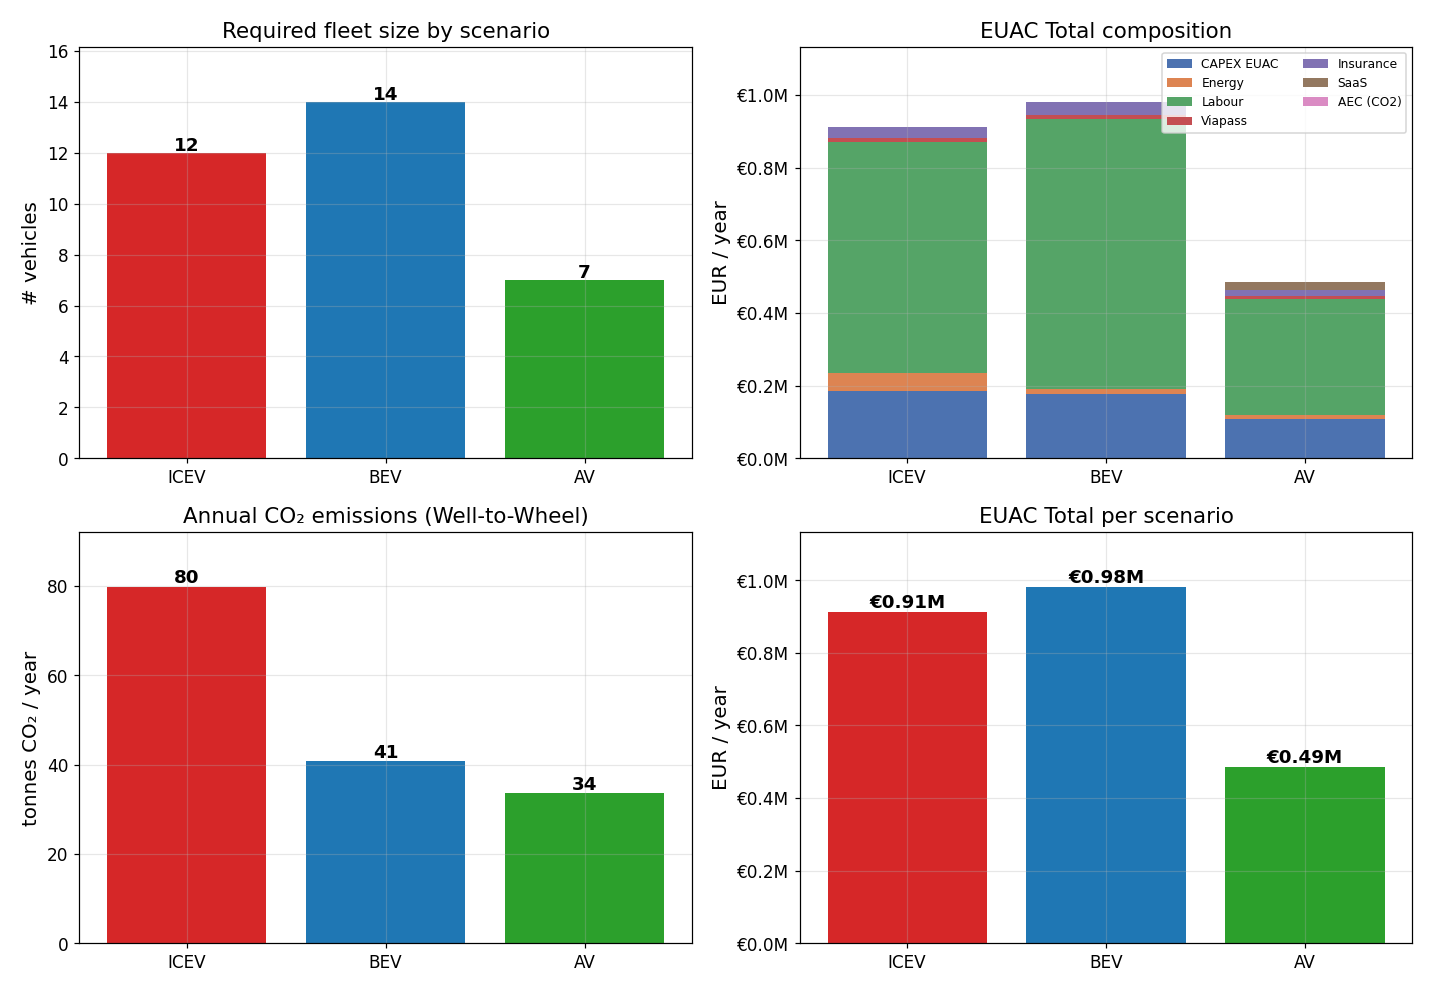


Plots saved to: outputs\synthesis_plots.png


In [45]:
# =============================================================================
# VISUALISATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Fleet size
ax = axes[0, 0]
ax.bar(summary.index, summary['Fleet (N)'], color=['#d62728', '#1f77b4', '#2ca02c'])
ax.set_title('Required fleet size by scenario')
ax.set_ylabel('# vehicles')
for i, v in enumerate(summary['Fleet (N)']):
    ax.text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')

# 2) EUAC composition (stacked)
ax = axes[0, 1]
components = ['CAPEX EUAC', 'Energy', 'Labour', 'Viapass', 'Insurance', 'SaaS', 'AEC (CO2)']
bottom = np.zeros(len(summary))
colors = ['#4c72b0', '#dd8452', '#55a467', '#c44e52', '#8172b3', '#937860', '#da8bc3']
for c, col in zip(colors, components):
    vals = summary[col].values
    ax.bar(summary.index, vals, bottom=bottom, label=col, color=c)
    bottom += vals
ax.set_title('EUAC Total composition')
ax.set_ylabel('EUR / year')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M'))

# 3) CO2 emissions
ax = axes[1, 0]
ax.bar(summary.index, summary['CO2 (t/y)'], color=['#d62728', '#1f77b4', '#2ca02c'])
ax.set_title('Annual CO₂ emissions (Well-to-Wheel)')
ax.set_ylabel('tonnes CO₂ / year')
for i, v in enumerate(summary['CO2 (t/y)']):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# 4) EUAC Total
ax = axes[1, 1]
bars = ax.bar(summary.index, summary['EUAC_Total'], color=['#d62728', '#1f77b4', '#2ca02c'])
ax.set_title('EUAC Total per scenario')
ax.set_ylabel('EUR / year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.1f}M'))
for bar, v in zip(bars, summary['EUAC_Total']):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'€{v/1e6:.2f}M',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
    _y0, _y1 = _ax.get_ylim()
    if _y1 > _y0:
        _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
plt.savefig(OUTPUT_DIR / 'synthesis_plots.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"\nPlots saved to: {OUTPUT_DIR / 'synthesis_plots.png'}")

## Module 15b — Routing-mode comparison (shuttle vs savings)

A **separate** figure that compares fleet size, daily km per vehicle, EUAC_internal, and CO₂ emissions between the two routing modes for every scenario. The active-mode plots in Module 15 are unchanged — this is purely for the thesis "value of routing optimisation" discussion (Section 4.x).


In [47]:
# =============================================================================
# COMPARISON PLOT — shuttle vs savings, side by side (separate figure)
# =============================================================================
if 'results_by_mode' not in globals() or 'shuttle' not in results_by_mode         or 'savings' not in results_by_mode:
    print("results_by_mode not populated for both modes — skipping comparison plot.")
else:
    scen_names = list(SCENARIOS.keys())
    modes = ['shuttle', 'savings']
    mode_label = {'shuttle': 'Shuttle (legacy)', 'savings': 'Savings (new)'}
    mode_color = {'shuttle': '#888888', 'savings': '#2ca02c'}

    metrics = [
        ('fleet_size',           'Fleet size (N)',          'vehicles',     '{:,.0f}'),
        ('daily_km_per_vehicle', 'Daily km per vehicle',    'km/veh/day',   '{:,.0f}'),
        ('EUAC_internal',        'EUAC internal (€/year)',  '€ / year',     '€{:,.0f}'),
        ('CO2_t',                'Annual CO₂ (t/year)',     't CO₂ / year', '{:,.1f}'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    x = np.arange(len(scen_names))
    width = 0.38

    for ax, (key, title, ylab, fmt) in zip(axes.flat, metrics):
        for i, mode in enumerate(modes):
            vals = [results_by_mode[mode][s][key] for s in scen_names]
            offset = (i - 0.5) * width
            bars = ax.bar(x + offset, vals, width=width,
                          color=mode_color[mode], label=mode_label[mode])
            for b, v in zip(bars, vals):
                ax.text(b.get_x() + b.get_width() / 2,
                        v + max(vals) * 0.01,
                        fmt.format(v), ha='center', va='bottom', fontsize=8)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(scen_names)
        ax.set_ylabel(ylab)
        ax.legend(loc='best', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        if 'EUAC' in title:
            ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda v, _: f'€{v/1e6:.1f}M')
            )

    fig.suptitle("Routing mode comparison — shuttle vs savings algorithm",
                 fontsize=13, y=1.0)
    plt.tight_layout()
    out_path = OUTPUT_DIR / 'routing_mode_comparison.png'
    # _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
    for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
        _y0, _y1 = _ax.get_ylim()
        if _y1 > _y0:
            _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f"\nComparison plot saved to: {out_path}")

    # Numeric delta table
    delta_rows = []
    for s in scen_names:
        sh = results_by_mode['shuttle'][s]
        sv = results_by_mode['savings'][s]
        delta_rows.append({
            'Scenario': s,
            'N (shuttle)':  sh['fleet_size'],
            'N (savings)':  sv['fleet_size'],
            'ΔN':           sv['fleet_size'] - sh['fleet_size'],
            'km/v/d (shuttle)': round(sh['daily_km_per_vehicle']),
            'km/v/d (savings)': round(sv['daily_km_per_vehicle']),
            'EUAC int. shuttle': round(sh['EUAC_internal']),
            'EUAC int. savings': round(sv['EUAC_internal']),
            'Δ EUAC int. (€)':   round(sv['EUAC_internal'] - sh['EUAC_internal']),
            'Δ EUAC int. (%)':   round(
                100 * (sv['EUAC_internal'] - sh['EUAC_internal']) / sh['EUAC_internal'], 1
            ),
        })
    delta_df = pd.DataFrame(delta_rows).set_index('Scenario')
    print("\nMode-comparison table:")
    print(delta_df.to_string())
    delta_df.to_csv(OUTPUT_DIR / 'routing_mode_comparison.csv')
    print(f"Comparison table saved to: {OUTPUT_DIR / 'routing_mode_comparison.csv'}")


results_by_mode not populated for both modes — skipping comparison plot.


## Module 15c — Deferral-on vs deferral-off comparison plot

Side-by-side bars for the four headline metrics under the two policies. The plot is only produced if Module 13c ran both modes; otherwise it skips cleanly. Saved to `outputs/sla_deferral_comparison.png`.


In [49]:
# =============================================================================
# COMPARISON PLOT — SLA deferral ON vs OFF (separate figure)
# =============================================================================
if 'results_by_deferral' not in globals() \
        or False not in results_by_deferral or True not in results_by_deferral:
    print("results_by_deferral not populated for both modes — skipping.")
else:
    scen_names = list(SCENARIOS.keys())
    flags = [False, True]
    flag_label = {False: 'No deferral (same-day)', True: 'With deferral (5-day SLA)'}
    flag_color = {False: '#888888', True: '#9467bd'}

    metrics = [
        ('fleet_size',           'Fleet size (N)',          'vehicles',     '{:,.0f}'),
        ('daily_km_per_vehicle', 'Daily km per vehicle',    'km/veh/day',   '{:,.0f}'),
        ('EUAC_internal',        'EUAC internal (€/year)',  '€ / year',     '€{:,.0f}'),
        ('CO2_t',                'Annual CO₂ (t/year)',     't CO₂ / year', '{:,.1f}'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    x = np.arange(len(scen_names))
    width = 0.38

    for ax, (key, title, ylab, fmt) in zip(axes.flat, metrics):
        for i, flag in enumerate(flags):
            vals = [results_by_deferral[flag][s][key] for s in scen_names]
            offset = (i - 0.5) * width
            bars = ax.bar(x + offset, vals, width=width,
                          color=flag_color[flag], label=flag_label[flag])
            for b, v in zip(bars, vals):
                ax.text(b.get_x() + b.get_width() / 2,
                        v + max(vals) * 0.01,
                        fmt.format(v), ha='center', va='bottom', fontsize=8)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(scen_names)
        ax.set_ylabel(ylab)
        ax.legend(loc='best', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        if 'EUAC' in title:
            ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda v, _: f'€{v/1e6:.1f}M')
            )

    fig.suptitle("SLA-deferral comparison — deadline-aware consolidation on vs off",
                 fontsize=13, y=1.0)
    plt.tight_layout()
    out_path = OUTPUT_DIR / 'sla_deferral_comparison.png'
    # _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
    for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
        _y0, _y1 = _ax.get_ylim()
        if _y1 > _y0:
            _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f"\nDeferral comparison plot saved to: {out_path}")

    # Numeric delta table
    delta_rows = []
    for s in scen_names:
        off = results_by_deferral[False][s]
        on  = results_by_deferral[True][s]
        delta_rows.append({
            'Scenario': s,
            'N (off)':  off['fleet_size'],
            'N (on)':   on['fleet_size'],
            'ΔN':       on['fleet_size'] - off['fleet_size'],
            'km/v/d (off)': round(off['daily_km_per_vehicle']),
            'km/v/d (on)':  round(on['daily_km_per_vehicle']),
            'EUAC int. (off)':  round(off['EUAC_internal']),
            'EUAC int. (on)':   round(on['EUAC_internal']),
            'Δ EUAC int. (€)':  round(on['EUAC_internal'] - off['EUAC_internal']),
            'Δ EUAC int. (%)':  round(
                100 * (on['EUAC_internal'] - off['EUAC_internal']) / off['EUAC_internal'], 1
            ),
        })
    delta_df = pd.DataFrame(delta_rows).set_index('Scenario')
    print("\nDeferral-comparison table:")
    print(delta_df.to_string())
    delta_df.to_csv(OUTPUT_DIR / 'sla_deferral_comparison.csv')
    print(f"Comparison table saved to: {OUTPUT_DIR / 'sla_deferral_comparison.csv'}")


results_by_deferral not populated for both modes — skipping.


## Module 15a — Fleet sizing per Monte Carlo trace

Each bar shows the fleet that would have been needed if **that trace alone**
were the only realisation observed. The chosen $N_k$ (cross-trace max) is in
the next plot — these bars are pure per-trace sensitivity.


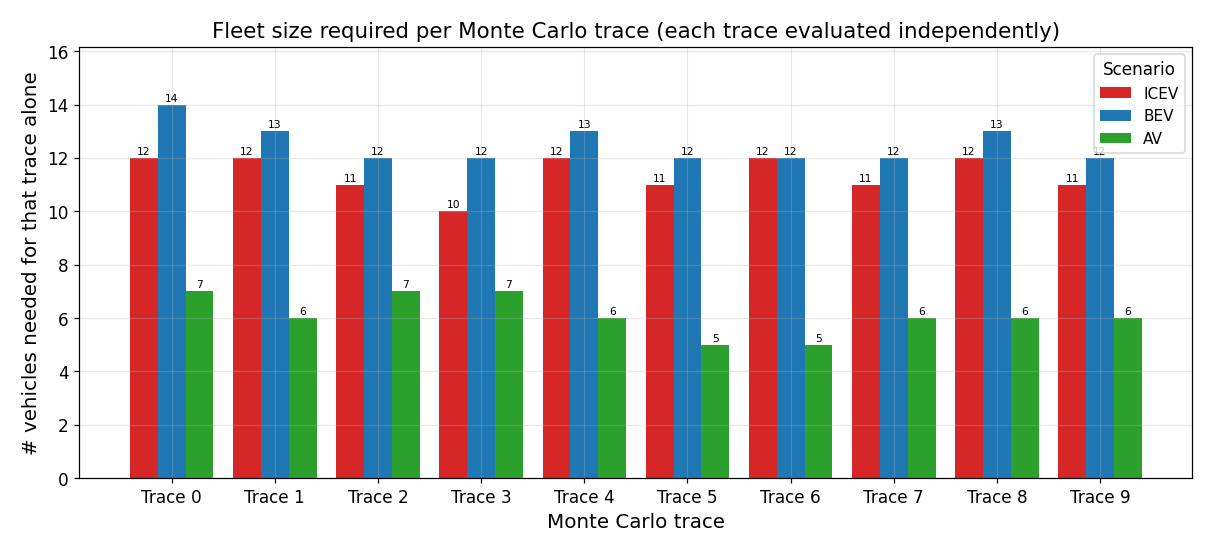

Per-trace plot saved to outputs\fleet_sizing_per_trace.png

Per-trace fleet sizes (rows = scenarios, columns = traces 0..9):
trace      0   1   2   3   4   5   6   7   8   9
Scenario                                        
AV         7   6   7   7   6   5   5   6   6   6
BEV       14  13  12  12  13  12  12  12  13  12
ICEV      12  12  11  10  12  11  12  11  12  11

Per-scenario stats over the 10 traces:
           min  mean  median   max   std
Scenario                                
AV         5.0   6.1     6.0   7.0  0.74
BEV       12.0  12.5    12.0  14.0  0.71
ICEV      10.0  11.4    11.5  12.0  0.70


In [51]:
# =============================================================================
# SENSITIVITY VIEW — fleet sizing per Monte Carlo trace (each bar = that trace alone)
# =============================================================================
# Each bar shows the fleet that would have been needed if THAT trace were the
# only realisation observed. No cross-trace overlay — the chosen N_k (the
# experiment-wide max) is plotted separately in the next cell.

fig, ax = plt.subplots(figsize=(11, 5))
trace_long = []
for name in SCENARIOS:
    d = fleet_size_details[name].copy()
    d['Scenario'] = name
    trace_long.append(d)
trace_long = pd.concat(trace_long)

scenarios_list = list(SCENARIOS.keys())
width = 0.27
x = np.arange(CONFIG['demand']['n_mc_traces'])
colors = ['#d62728', '#1f77b4', '#2ca02c']
for i, name in enumerate(scenarios_list):
    sub = trace_long[trace_long['Scenario'] == name].sort_values('trace')
    bars = ax.bar(x + (i - 1) * width, sub['fleet_size'].values, width,
                  label=name, color=colors[i])
    for b, v in zip(bars, sub['fleet_size'].values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.05,
                f"{int(v)}", ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f'Trace {i}' for i in range(CONFIG['demand']['n_mc_traces'])])
ax.set_title('Fleet size required per Monte Carlo trace (each trace evaluated independently)')
ax.set_ylabel('# vehicles needed for that trace alone')
ax.set_xlabel('Monte Carlo trace')
ax.legend(title='Scenario')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
    _y0, _y1 = _ax.get_ylim()
    if _y1 > _y0:
        _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
plt.savefig(OUTPUT_DIR / 'fleet_sizing_per_trace.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Per-trace plot saved to {OUTPUT_DIR / 'fleet_sizing_per_trace.png'}")

# Numeric summary so the per-trace spread is also visible
print("\nPer-trace fleet sizes (rows = scenarios, columns = traces 0..9):")
pivot = trace_long.pivot(index='Scenario', columns='trace', values='fleet_size')
print(pivot.to_string())
print("\nPer-scenario stats over the 10 traces:")
print(pivot.agg(['min', 'mean', 'median', 'max', 'std'], axis=1).round(2).to_string())


## Module 15b — Chosen fleet size $N_k$

The robust maximum across the 10 Monte Carlo traces — the number of vehicles
$N_k$ used downstream by every CAPEX / OPEX / AEC computation. Footer shows
which trace number drove each scenario's worst case.

> Note: there's also a *Module 15b — Routing-mode comparison (shuttle vs savings)*
> earlier in the notebook (cell 45). Different plot, accidental name collision —
> this one is the chosen-N bar chart, that one is the routing-mode comparison.


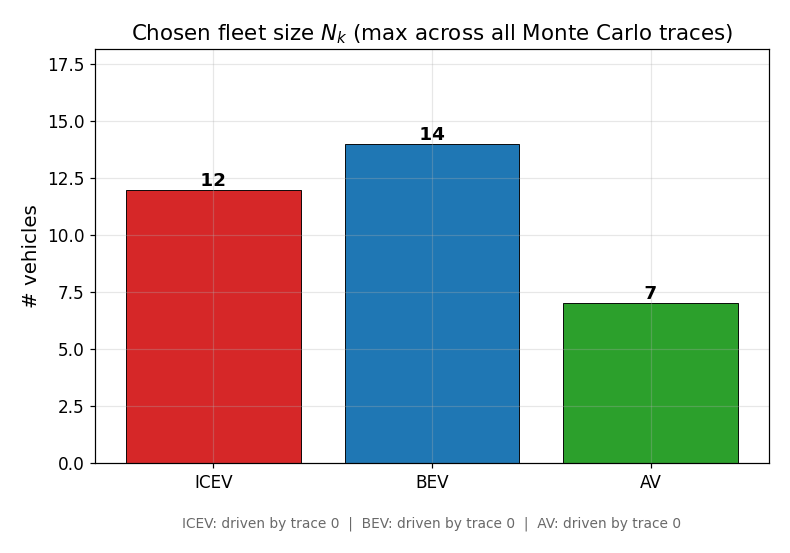

Chosen-N plot saved to outputs\fleet_sizing_chosen.png

  ICEV: N_ICEV = 12  (worst trace: 0)
  BEV: N_BEV = 14  (worst trace: 0)
  AV: N_AV = 7  (worst trace: 0)


In [53]:
# =============================================================================
# CHOSEN FLEET SIZE — robust maximum across all Monte Carlo traces
# =============================================================================
# The number of vehicles N_k actually used downstream (CAPEX, OPEX, AEC) is
# the worst-case across the 10 traces — sized for SLA robustness.

fig, ax = plt.subplots(figsize=(7, 5))
scenarios_list = list(SCENARIOS.keys())
colors = ['#d62728', '#1f77b4', '#2ca02c']
n_values = [fleet_sizes[s] for s in scenarios_list]

bars = ax.bar(scenarios_list, n_values, color=colors, edgecolor='black', linewidth=0.6)
for b, v in zip(bars, n_values):
    ax.text(b.get_x() + b.get_width() / 2, v,
            f" {int(v)} ", ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_title('Chosen fleet size $N_k$ (max across all Monte Carlo traces)')
ax.set_ylabel('# vehicles')
ax.set_ylim(0, max(n_values) * 1.18)
ax.grid(axis='y', alpha=0.3)

# Footer: which trace drove each scenario's N_k
worst_traces = []
for name in scenarios_list:
    d = fleet_size_details[name]
    idx = d['fleet_size'].idxmax()
    worst_traces.append(int(d.loc[idx, 'trace']))
footer = "  |  ".join(f"{s}: driven by trace {t}"
                       for s, t in zip(scenarios_list, worst_traces))
ax.text(0.5, -0.13, footer, transform=ax.transAxes,
        ha='center', va='top', fontsize=9, color='dimgray')

plt.tight_layout()
# _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
    _y0, _y1 = _ax.get_ylim()
    if _y1 > _y0:
        _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
plt.savefig(OUTPUT_DIR / 'fleet_sizing_chosen.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Chosen-N plot saved to {OUTPUT_DIR / 'fleet_sizing_chosen.png'}")
print()
for name in scenarios_list:
    d = fleet_size_details[name]
    idx = d['fleet_size'].idxmax()
    t = int(d.loc[idx, 'trace'])
    print(f"  {name}: N_{name} = {fleet_sizes[name]}  (worst trace: {t})")


## Module 15c — Optimal Disposal Point (ODP)

For each scenario, plots the EUAC of CAPEX + cumulative maintenance against
asset service life. The minimum of each curve is the ODP — the year at which
keeping the asset another year costs more than replacing it.


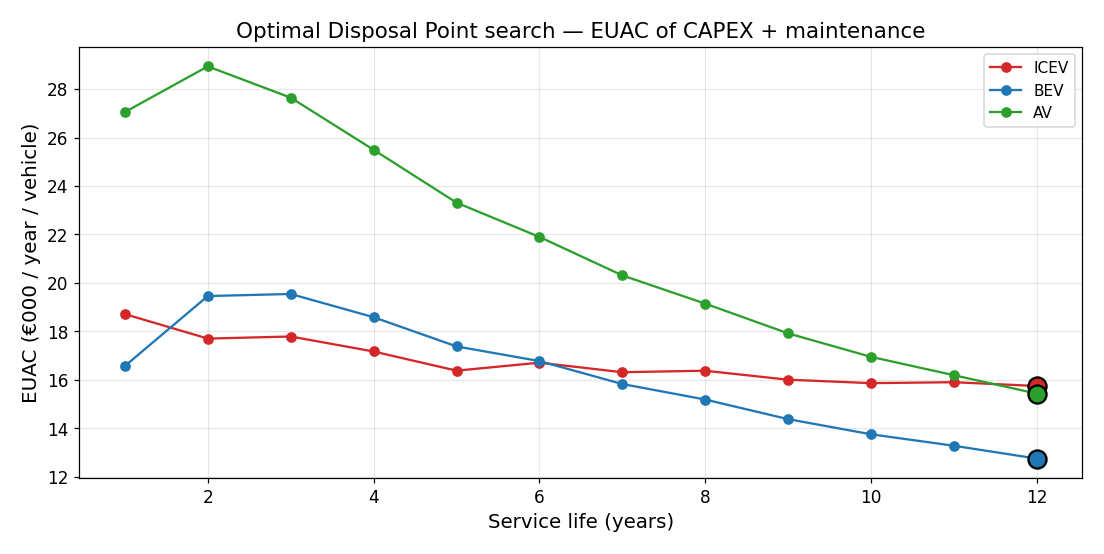

In [55]:
# =============================================================================
# OPTIMAL DISPOSAL POINT — EUAC vs service life
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
for name, color in zip(SCENARIOS, colors):
    d = odp_results[name]['search']
    ax.plot(d['service_life'], d['EUAC_capex_maint'] / 1000,
            marker='o', label=name, color=color)
    best = odp_results[name]['service_life']
    best_y = odp_results[name]['EUAC_capex_maint'] / 1000
    ax.scatter([best], [best_y], color=color, s=140, zorder=5,
               edgecolor='black', linewidth=1.5)

ax.set_title('Optimal Disposal Point search — EUAC of CAPEX + maintenance')
ax.set_xlabel('Service life (years)')
ax.set_ylabel('EUAC (€000 / year / vehicle)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'odp_search.png', dpi=160, bbox_inches='tight')
plt.show()

## Module 16 — Case Ladder

Runs the **6-case ladder** described in the thesis numerical results section,
each case isolating one additional methodological lever:

| Case | Configuration | What it shows |
|---|---|---|
| **0** | Clustered, 5-day SLA, **shuttle routing** (legacy single-zone round trips), all single-depot | The "naive cost-estimation" baseline. Ceiling on what the savings algorithm has to beat. |
| **1** | Demand-only visualisation (no routing) | Spatial granularity of the raw 13,420 collection points and the 50 K-means zones. No fleet sizing — illustrative. |
| **2** | Clustered, **1-working-day SLA** (no deferral), savings, single-depot | Tight-SLA stress test. Shows what same-day pickup costs vs the loose 5-day SLA. |
| **3** | Clustered, **5-day SLA** (deferral on), savings, single-depot, **φ = 1.0** | Adds the SLA-window flexibility lever. φ disabled (full nominal capacity per trip). |
| **4** | As Case 3 but **φ ∈ {0.65, 0.70, 0.75, 0.80, 0.85}** | Adds realistic loading via the load-factor sensitivity. The §4.3.1 sweep. |
| **5** | As Case 4 but with **AV multi-depot enabled** (asymmetric tour endpoints) | Unlocks the AV flexibility advantage. |
| **6** | As Case 5 but ICEV/BEV at **16 h/day (2 shifts)**, AV stays 24 h | Fair-comparison stress test — does AV's advantage hold when ICEV/BEV are allowed multi-shift operation? |
| **7** | As Case 5 but **all scenarios at 24 h/day** (3 shifts ICEV/BEV) | Limit case — vehicles share identical operating envelope; only autonomy / energy / CAPEX axes differentiate them. |

**Each case runs at both growth scenarios** (low: 2.83 %/yr, high: 4.21 %/yr) — outputs are
saved under `outputs/case_runs/case_X/{growth}/`. The cross-case comparison module
(16b) builds two headline figures, one per growth rate.

### Cache + resume
Each case has its own cache file (`cache.json` in the case folder) keyed by a hash of
the routing-relevant config. Re-running with unchanged configuration reuses cached
results instantly. Editing financial-only parameters (CAPEX, OPEX, AEC) does **not**
invalidate routing caches — financials re-aggregate cheaply.

**Wall-clock estimate (cold cache):** ~8 hours for the full 8-case ladder.
**Wall-clock (financial-only edits):** ~3 minutes (cached routing, financials re-aggregated).

If interrupted (Ctrl+C), every completed cell is on disk — re-run picks up where it
left off. **Toggle off** any individual case by setting its `enabled: False` in the
`CASES` list inside the next cell.


In [57]:
# =============================================================================
# CASE LADDER ORCHESTRATOR — runs all 6 cases sequentially with isolated outputs
# =============================================================================
import hashlib, copy, time as _time, json as _json, shutil

CASE_RUNS_DIR = OUTPUT_DIR / 'case_runs'
CASE_RUNS_DIR.mkdir(exist_ok=True)

SCENARIO_NAMES = list(SCENARIOS.keys())

# ---------------------------------------------------------------------------
# Helper: regenerate the 10 MC traces for a different growth rate.
# Re-runs Module 5 (extension) → Module 6 (Poisson disaggregation) →
# Module 8 (trace generation) silently. Returns {trace_idx: DataFrame}.
# ---------------------------------------------------------------------------
def _regenerate_traces_for_growth(growth_rate: float) -> Dict[int, pd.DataFrame]:
    df_long_local, _ = extend_history_topdown(
        df_long, growth_rate=growth_rate, target_years=TARGET_YEARS,
    )
    daily_events_local = disaggregate_to_daily(
        df_long_local, coords_with_zones,
        recipient_mix=CONFIG['recipient_weights'],
        cap_kg=CONFIG['demand']['max_request_capacity_kg'],
        seed=SEEDS['poisson_disaggregation'],
    )
    historical_daily_local = aggregate_daily_workload(daily_events_local)
    zone_profiles_local = build_zone_profiles(
        historical_daily_local,
        working_days_per_year=CONFIG['demand']['working_days_per_year'],
    )
    new_traces = {}
    for i in range(CONFIG['demand']['n_mc_traces']):
        new_traces[i] = generate_mc_trace(
            zone_profiles_local,
            horizon_years=CONFIG['demand']['horizon_years'],
            growth_rate=growth_rate,
            seed=SEEDS[f'mc_trace_{i}'],
            working_days_per_year=CONFIG['demand']['working_days_per_year'],
        )
    return new_traces

# ---------------------------------------------------------------------------
# Case definitions — each entry is a dict that the orchestrator consumes.
# Edit `enabled: False` on any case to skip it.
# ---------------------------------------------------------------------------
CASES = [
    {
        'id': 0, 'enabled': True,
        'name': 'case_0_shuttle_baseline',
        'description': 'Clustered, 5-day SLA, SHUTTLE routing (legacy round trips), single-depot for all scenarios.',
        'mode': 'single',                    # one phi value, no sweep
        'phi_values': [1.0],                 # full capacity, irrelevant for shuttle but consistent
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'shuttle',
            'fleet_sizing.enable_sla_deferral':     True,
            'fleet_sizing.sla_pickup_window_days':  5,
            'fleet_sizing.av_multi_depot_enabled':  False,   # all single-depot
        },
    },
    {
        'id': 1, 'enabled': True,
        'name': 'case_1_demand_only',
        'description': 'Demand-only visualisation. No routing, no fleet sizing — shows the raw spatial granularity that subsequent cases consolidate.',
        'mode': 'demand_only',
        'phi_values': [None],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {},
    },
    {
        'id': 2, 'enabled': True,
        'name': 'case_2_tight_sla',
        'description': 'Clustered, 1-working-day SLA (same-day pickup, no deferral), savings algorithm, single-depot all scenarios. φ = 1.0 (no load-factor penalty).',
        'mode': 'single',
        'phi_values': [1.0],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'savings',
            'fleet_sizing.enable_sla_deferral':     False,    # tight SLA leaves no deferral room
            'fleet_sizing.sla_pickup_window_days':  1,
            'fleet_sizing.av_multi_depot_enabled':  False,
        },
    },
    {
        'id': 3, 'enabled': True,
        'name': 'case_3_loose_sla_no_phi',
        'description': 'Clustered, 5-day SLA (deferral ON), savings algorithm, single-depot all scenarios. φ = 1.0 (load factor disabled).',
        'mode': 'single',
        'phi_values': [1.0],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'savings',
            'fleet_sizing.enable_sla_deferral':     True,
            'fleet_sizing.sla_pickup_window_days':  5,
            'fleet_sizing.av_multi_depot_enabled':  False,
        },
    },
    {
        'id': 4, 'enabled': True,
        'name': 'case_4_phi_sensitivity',
        'description': 'As Case 3 but with φ sweep over [0.65, 0.70, 0.75, 0.80, 0.85] — the §4.3.1 load-factor sensitivity.',
        'mode': 'sensitivity',
        'phi_values': [0.65, 0.70, 0.75, 0.80, 0.85],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'savings',
            'fleet_sizing.enable_sla_deferral':     True,
            'fleet_sizing.sla_pickup_window_days':  5,
            'fleet_sizing.av_multi_depot_enabled':  False,
        },
        'headline_phi': 0.75,           # the value picked for the cross-case comparison plot
    },
    {
        'id': 5, 'enabled': True,
        'name': 'case_5_av_multidepot',
        'description': 'As Case 4 but with AV multi-depot ENABLED — AV tours can start at hub A and end at hub B (asymmetric endpoints).',
        'mode': 'sensitivity',
        'phi_values': [0.65, 0.70, 0.75, 0.80, 0.85],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'savings',
            'fleet_sizing.enable_sla_deferral':     True,
            'fleet_sizing.sla_pickup_window_days':  5,
            'fleet_sizing.av_multi_depot_enabled':  True,
        },
        'headline_phi': 0.75,
    },
    {
        'id': 6, 'enabled': True,
        'name': 'case_6_multishift_iceev_bev',
        'description': 'Extension of Case 5 — ICEV/BEV run 2 shifts (16 h/day), AV stays 24 h/day. '
                        'Same routing/SLA/deferral/φ-sweep/AV-multi-depot rules as Case 5. '
                        'Doubles ICEV/BEV labour cost; roughly halves their fleet size.',
        'mode': 'sensitivity',
        'phi_values': [0.65, 0.70, 0.75, 0.80, 0.85],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'savings',
            'fleet_sizing.enable_sla_deferral':     True,
            'fleet_sizing.sla_pickup_window_days':  5,
            'fleet_sizing.av_multi_depot_enabled':  True,
            # Multi-shift: ICEV/BEV go to 16 h/day (2 driver shifts), AV stays at 24 h.
            'scenarios.ICEV.daily_hours': 16.0,
            'scenarios.BEV.daily_hours':  16.0,
            'scenarios.AV.daily_hours':   24.0,
        },
        'headline_phi': 0.75,
    },
    {
        'id': 7, 'enabled': True,
        'name': 'case_7_all_24h',
        'description': 'Extension of Case 5 — ALL scenarios run 24 h/day. ICEV/BEV become 3 driver shifts '
                        '(triple labour); AV stays 1:5 supervision but with 3 operator shifts (Fix #1). '
                        'Tests the limit case where vehicle operating envelope is identical and only the '
                        'autonomy / energy / CAPEX axes differentiate the scenarios.',
        'mode': 'sensitivity',
        'phi_values': [0.65, 0.70, 0.75, 0.80, 0.85],
        'growth_scenarios': ['low', 'high'],
        'config_overrides': {
            'fleet_sizing.routing_mode':            'savings',
            'fleet_sizing.enable_sla_deferral':     True,
            'fleet_sizing.sla_pickup_window_days':  5,
            'fleet_sizing.av_multi_depot_enabled':  True,
            'scenarios.ICEV.daily_hours': 24.0,
            'scenarios.BEV.daily_hours':  24.0,
            'scenarios.AV.daily_hours':   24.0,
        },
        'headline_phi': 0.75,
    },
]

# ---------------------------------------------------------------------------
# Helper: apply / restore CONFIG overrides using dotted paths
# ---------------------------------------------------------------------------
def _apply_overrides(overrides: dict) -> dict:
    """Apply dotted-path overrides to CONFIG. Returns a dict of original values to restore."""
    saved = {}
    for path, new_value in overrides.items():
        parts = path.split('.')
        d = CONFIG
        for p in parts[:-1]:
            d = d.setdefault(p, {})
        leaf = parts[-1]
        saved[path] = d.get(leaf, '__MISSING__')
        d[leaf] = new_value
    return saved


def _restore_overrides(saved: dict) -> None:
    for path, original in saved.items():
        parts = path.split('.')
        d = CONFIG
        for p in parts[:-1]:
            d = d.setdefault(p, {})
        leaf = parts[-1]
        if original == '__MISSING__':
            d.pop(leaf, None)
        else:
            d[leaf] = original


# ---------------------------------------------------------------------------
# Wire av_multi_depot_enabled toggle into the SCENARIOS dataclass at runtime
# ---------------------------------------------------------------------------
def _set_av_multi_depot(enabled: bool) -> bool:
    """Toggle SCENARIOS['AV'].multi_depot. Returns the previous value."""
    prev = SCENARIOS['AV'].multi_depot
    SCENARIOS['AV'].multi_depot = enabled
    return prev


# Fields on the Scenario dataclass that a case override might patch via
# 'scenarios.<NAME>.<field>'. Listed explicitly so the orchestrator knows
# what to sync.
_SCENARIO_OVERRIDE_FIELDS = ('daily_hours', 'availability', 'energy_consumption',
                              'energy_unit_cost', 'supervision_ratio',
                              'multi_depot', 'can_recharge_intraday')


def _push_scenario_overrides(overrides: dict) -> dict:
    """Apply 'scenarios.<NAME>.<field>' overrides to the live SCENARIOS dict.

    Returns a snapshot {(name, field): original_value} so they can be restored.
    """
    snapshot = {}
    for path, new_value in overrides.items():
        parts = path.split('.')
        if len(parts) != 3 or parts[0] != 'scenarios':
            continue
        name, field = parts[1], parts[2]
        if name not in SCENARIOS:
            continue
        if field not in _SCENARIO_OVERRIDE_FIELDS:
            continue
        snapshot[(name, field)] = getattr(SCENARIOS[name], field)
        setattr(SCENARIOS[name], field, new_value)
    return snapshot


def _restore_scenario_overrides(snapshot: dict) -> None:
    for (name, field), original in snapshot.items():
        setattr(SCENARIOS[name], field, original)


# ---------------------------------------------------------------------------
# Routing signature — extended to include case-relevant CONFIG fields
# ---------------------------------------------------------------------------
def _case_routing_signature(case: dict, growth_label: str, phi: float) -> str:
    fs = CONFIG['fleet_sizing']
    sig = {
        'master_seed':                MASTER_SEED,
        'horizon_years':              CONFIG['demand']['horizon_years'],
        'n_mc_traces':                CONFIG['demand']['n_mc_traces'],
        'working_days_per_year':      CONFIG['demand']['working_days_per_year'],
        'max_request_capacity_kg':    CONFIG['demand']['max_request_capacity_kg'],
        'vehicle_capacity_kg':        fs['vehicle_capacity_kg'],
        'utilization_eta':            fs['utilization_eta'],
        'avg_speed_kmh':              fs['avg_speed_kmh'],
        'service_time_per_stop_h':    fs['service_time_per_stop_h'],
        'routing_mode':               fs['routing_mode'],
        'charger_power_kw':           fs['charger_power_kw'],
        'enable_sla_deferral':        fs['enable_sla_deferral'],
        'sla_pickup_window_days':     fs['sla_pickup_window_days'],
        'consolidation_threshold_kg': fs['consolidation_threshold_kg'],
        'av_multi_depot':             SCENARIOS['AV'].multi_depot,
        'circuity_factor':            CONFIG['spatial']['circuity_factor'],
        'av_efficiency':              SCENARIOS['AV'].energy_consumption,
        'icev_availability':          SCENARIOS['ICEV'].availability,
        'bev_availability':           SCENARIOS['BEV'].availability,
        'av_availability':            SCENARIOS['AV'].availability,
        'icev_daily_hours':           SCENARIOS['ICEV'].daily_hours,
        'bev_daily_hours':            SCENARIOS['BEV'].daily_hours,
        'av_daily_hours':             SCENARIOS['AV'].daily_hours,
        'growth_label':               growth_label,
        'phi':                        phi,
        # Bump this string to force cache invalidation when routing semantics change
        'pack_version':               'v2_H_times_eta_2026_05_17',
    }
    return hashlib.md5(_json.dumps(sig, sort_keys=True).encode()).hexdigest()


def _load_case_cache(case_dir: Path) -> dict:
    p = case_dir / 'cache.json'
    if not p.exists():
        return {'cells': {}}
    try:
        with open(p) as f:
            return _json.load(f)
    except Exception:
        return {'cells': {}}


def _save_case_cache(case_dir: Path, cache: dict) -> None:
    p = case_dir / 'cache.json'
    tmp = p.with_suffix('.json.tmp')
    with open(tmp, 'w', encoding='utf-8') as f:
        _json.dump(cache, f, indent=1)
    tmp.replace(p)


# ---------------------------------------------------------------------------
# Case-1 demand-only renderer
# ---------------------------------------------------------------------------
def _run_case_demand_only(case: dict, case_dir: Path) -> None:
    case_dir.mkdir(parents=True, exist_ok=True)
    for growth_label in case['growth_scenarios']:
        gdir = case_dir / growth_label
        gdir.mkdir(exist_ok=True)
        growth_rate = CONFIG['demand']['growth_scenarios'][growth_label]
        print(f"  Case 1 / {growth_label} ({growth_rate*100:.2f}%/yr): rendering demand-only outputs...")

        local_traces = _regenerate_traces_for_growth(growth_rate)

        # 1) Static map: all 13,420 active points (faded) + 50 zone centroids (highlighted)
        fig, ax = plt.subplots(figsize=(10, 9))
        ax.scatter(coords['lon'], coords['lat'],
                   s=1, alpha=0.10, color='gray', label=f"Active points (n={len(coords):,})")
        ax.scatter(zone_centroids['lon'], zone_centroids['lat'],
                   s=80, marker='X', color='crimson', edgecolor='black',
                   linewidth=0.8, label='K-means zone centroids (n=50)')
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        ax.set_title(f"Case 1 — Raw spatial granularity ({growth_label}-growth scenario)")
        ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(loc='best')
        plt.tight_layout()
        plt.savefig(gdir / 'raw_locations.png', dpi=160, bbox_inches='tight')
        plt.close()

        # 2) Daily-demand histogram
        all_daily = pd.concat([t.groupby('trace_day')['weight_kg'].sum()
                                 for t in local_traces.values()])
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.hist(all_daily.values / 1000, bins=50, alpha=0.75, color='#4477aa',
                edgecolor='black', linewidth=0.4)
        ax.axvline(all_daily.mean() / 1000, color='red', linestyle='--',
                   label=f"Mean = {all_daily.mean()/1000:.1f} t/day")
        ax.axvline(all_daily.quantile(0.95) / 1000, color='orange', linestyle='--',
                   label=f"p95 = {all_daily.quantile(0.95)/1000:.1f} t/day")
        ax.set_xlabel('Daily network total (tonnes)')
        ax.set_ylabel('Frequency (across all traces × all days)')
        ax.set_title(f"Case 1 — Daily demand distribution ({growth_label}-growth)")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(gdir / 'daily_demand_histogram.png', dpi=160, bbox_inches='tight')
        plt.close()
        print(f"    Saved → {gdir}")

    # Summary markdown
    summary = f"""\
# Case 1 — Demand-only visualisation

{case['description']}

This case has **no fleet sizing or financial outputs**. It exists to illustrate
the spatial granularity of the raw 13,420 active collection points and to show
how the K-means consolidation reduces them to 50 operational zones.

## Generated artefacts

For each growth scenario subfolder (`low/`, `high/`):
- `raw_locations.png` — all active points (faded) overlaid with the 50 K-means centroids.
- `daily_demand_histogram.png` — histogram of daily network total kg across all 10 MC traces × 750 days.
"""
    (case_dir / 'case_summary.md').write_text(summary, encoding='utf-8')


# ---------------------------------------------------------------------------
# Single-config case runner (cases 0, 2, 3)
# ---------------------------------------------------------------------------
def _run_case_single(case: dict, case_dir: Path) -> dict:
    """Returns a dict {growth_label: {phi: {scenario_name: result_dict}}}."""
    case_dir.mkdir(parents=True, exist_ok=True)
    cache = _load_case_cache(case_dir)
    results = {}

    for growth_label in case['growth_scenarios']:
        gdir = case_dir / growth_label
        gdir.mkdir(exist_ok=True)
        growth_rate = CONFIG['demand']['growth_scenarios'][growth_label]
        print(f"\n  --- {case['name']} / {growth_label} ({growth_rate*100:.2f}%/yr) ---")
        local_traces = None  # lazy: only build if any cell needs running

        results.setdefault(growth_label, {})
        phi = case['phi_values'][0]
        sig = _case_routing_signature(case, growth_label, phi)
        cache_key = f"{growth_label}|phi={phi}|sig={sig}"

        if cache_key in cache['cells']:
            print(f"    Loading from cache (sig={sig[:8]}...)")
            results[growth_label][phi] = cache['cells'][cache_key]
        else:
            t0 = _time.time()
            if local_traces is None:
                print(f"    Regenerating MC traces for {growth_label} growth...")
                local_traces = _regenerate_traces_for_growth(growth_rate)
            cell = _run_one_cell_against_traces(local_traces, phi)
            cache['cells'][cache_key] = cell
            _save_case_cache(case_dir, cache)
            results[growth_label][phi] = cell
            print(f"    Done in {_time.time() - t0:.0f}s.   "
                  + ", ".join(f"{s}={cell[s]['fleet_size']}" for s in SCENARIO_NAMES))

        # Per-growth artefacts
        _write_single_case_artefacts(case, growth_label, phi, results[growth_label][phi], gdir)

    # Top-level case summary
    _write_single_case_summary(case, case_dir, results)
    return results


def _run_one_cell_against_traces(cell_traces: Dict[int, pd.DataFrame], phi: float) -> dict:
    """Run the full pipeline for one (traces, phi) configuration. Returns per-scenario dict."""
    global traces
    saved_traces = traces
    saved_phi = CONFIG['fleet_sizing']['load_factor_phi']
    try:
        traces = cell_traces
        CONFIG['fleet_sizing']['load_factor_phi'] = phi
        results = run_full_pipeline_for_mode(CONFIG['fleet_sizing']['routing_mode'])
    finally:
        traces = saved_traces
        CONFIG['fleet_sizing']['load_factor_phi'] = saved_phi
    return {name: {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
                    for k, v in r.items()}
            for name, r in results.items()}


def _write_single_case_artefacts(case: dict, growth_label: str,
                                   phi: float, cell: dict, gdir: Path) -> None:
    # Fleet-size + EUAC bar charts
    scen_colors = {'ICEV': '#d62728', 'BEV': '#1f77b4', 'AV': '#2ca02c'}
    sn = SCENARIO_NAMES

    # Fleet size
    fig, ax = plt.subplots(figsize=(7, 4.5))
    vals = [cell[s]['fleet_size'] for s in sn]
    bars = ax.bar(sn, vals, color=[scen_colors[s] for s in sn],
                  edgecolor='black', linewidth=0.5)
    # Show the chosen integer, plus which constraint drove it (formula vs packing)
    for b, s, v in zip(bars, sn, vals):
        r = cell[s]
        formula_n_s = r.get('formula_n', int(v))
        packing_n_s = r.get('packing_n', 0)
        driver_s    = r.get('driver', 'formula')
        if driver_s == 'packing':
            tag = f'pack→{packing_n_s} (form {formula_n_s})'
        elif driver_s == 'formula':
            ff = r.get('fleet_size_float', float(v))
            tag = f'form {ff:.2f}'
        else:
            tag = f'tie ({formula_n_s})'
        ax.text(b.get_x() + b.get_width() / 2, v,
                f' {int(v)}\n{tag}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_ylabel('# vehicles')
    ax.set_title(f"{case['name']} ({growth_label}-growth, φ={phi})\nFleet size $N_k$")
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    # _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
    for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
        _y0, _y1 = _ax.get_ylim()
        if _y1 > _y0:
            _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
    plt.savefig(gdir / 'plot_fleet_size.png', dpi=160, bbox_inches='tight')
    plt.close()

    # EUAC composition (stacked)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    capex = [cell[s]['capex_euac'] for s in sn]
    opex_t = [cell[s]['EUAC_internal'] - cell[s]['capex_euac'] for s in sn]
    aec   = [cell[s]['EUAC_total'] - cell[s]['EUAC_internal'] for s in sn]
    x = np.arange(len(sn))
    ax.bar(x, np.array(capex)/1e6, label='CAPEX', color='#9467bd')
    ax.bar(x, np.array(opex_t)/1e6, bottom=np.array(capex)/1e6, label='OPEX', color='#1f77b4')
    ax.bar(x, np.array(aec)/1e6,   bottom=(np.array(capex)+np.array(opex_t))/1e6,
           label='AEC (CO₂)', color='#2ca02c')
    for i, s in enumerate(sn):
        total = cell[s]['EUAC_total'] / 1e6
        ax.text(i, total + 0.05, f'€{total:.2f}M', ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(sn)
    ax.set_ylabel('EUAC (€/year, millions)')
    ax.set_title(f"{case['name']} ({growth_label}-growth, φ={phi})\nEUAC composition")
    ax.legend(loc='best', fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    # _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
    for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
        _y0, _y1 = _ax.get_ylim()
        if _y1 > _y0:
            _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
    plt.savefig(gdir / 'plot_euac_total.png', dpi=160, bbox_inches='tight')
    plt.close()

    # CSV: per-scenario summary
    rows = []
    for s in sn:
        r = cell[s]
        rows.append({
            'scenario': s,
            'fleet_size_int':                r['fleet_size'],
            'formula_float':                 round(r.get('fleet_size_float', float(r['fleet_size'])), 3),
            'formula_n':                     r.get('formula_n', int(round(r.get('fleet_size_float', r['fleet_size'])))),
            'time_packing_float':            round(r.get('time_packing_float', 0.0), 3),
            'packing_n':                     r.get('packing_n', 0),
            'fleet_size_float_combined':     round(r.get('fleet_size_float_combined',
                                                          r.get('fleet_size_float', float(r['fleet_size']))), 3),
            'driver':                        r.get('driver', 'unknown'),
            'H_empirical_trips_per_v_per_day': round(r.get('H_empirical', 1.0), 3),
            'service_life_y': r['service_life_years'],
            'daily_km_per_vehicle': round(r['daily_km_per_vehicle'], 1),
            'capex_euac': round(r['capex_euac']),
            'opex_total': round(r['EUAC_internal'] - r['capex_euac']),
            'aec_co2': round(r['EUAC_total'] - r['EUAC_internal']),
            'EUAC_internal': round(r['EUAC_internal']),
            'EUAC_total':    round(r['EUAC_total']),
            'CO2_t_year':    round(r['CO2_t'], 2),
        })
    pd.DataFrame(rows).to_csv(gdir / 'summary.csv', index=False)


def _write_single_case_summary(case: dict, case_dir: Path, results: dict) -> None:
    md = [f"# {case['name']}", "", case['description'], "",
          "## Headline numbers", ""]
    for growth_label, by_phi in results.items():
        for phi, cell in by_phi.items():
            md.append(f"### {growth_label}-growth, φ={phi}")
            md.append("| Scenario | $N_k$ | formula | packing | driver | EUAC_internal (€/yr) | EUAC_total (€/yr) | CO₂ (t/yr) |")
            md.append("|---|---|---|---|---|---|---|---|")
            for s in SCENARIO_NAMES:
                r = cell[s]
                n_int = r['fleet_size']
                n_flt = r.get('fleet_size_float', float(n_int))
                fn    = r.get('formula_n', int(round(n_flt)))
                pn    = r.get('packing_n', 0)
                drv   = r.get('driver', 'formula')
                md.append(f"| {s} | {n_int} | {fn} ({n_flt:.2f}) | {pn} | {drv} | "
                           f"{r['EUAC_internal']:,.0f} | "
                           f"{r['EUAC_total']:,.0f} | "
                           f"{r['CO2_t']:.2f} |")
            md.append("")
    (case_dir / 'case_summary.md').write_text("\n".join(md), encoding='utf-8')


# ---------------------------------------------------------------------------
# Sensitivity case runner (cases 4, 5)
# ---------------------------------------------------------------------------
def _run_case_sensitivity(case: dict, case_dir: Path) -> dict:
    """Returns {growth_label: {phi: {scenario_name: result_dict}}}."""
    case_dir.mkdir(parents=True, exist_ok=True)
    cache = _load_case_cache(case_dir)
    results = {}

    for growth_label in case['growth_scenarios']:
        gdir = case_dir / growth_label
        gdir.mkdir(exist_ok=True)
        growth_rate = CONFIG['demand']['growth_scenarios'][growth_label]
        print(f"\n  --- {case['name']} / {growth_label} ({growth_rate*100:.2f}%/yr) ---")
        local_traces = None
        results.setdefault(growth_label, {})

        for phi in case['phi_values']:
            sig = _case_routing_signature(case, growth_label, phi)
            cache_key = f"{growth_label}|phi={phi}|sig={sig}"
            if cache_key in cache['cells']:
                results[growth_label][phi] = cache['cells'][cache_key]
                print(f"    φ={phi:.2f}: cached (sig={sig[:8]}...)   "
                      + ", ".join(f"{s}={cache['cells'][cache_key][s]['fleet_size']}"
                                   for s in SCENARIO_NAMES))
                continue
            if local_traces is None:
                print(f"    Regenerating MC traces for {growth_label} growth...")
                local_traces = _regenerate_traces_for_growth(growth_rate)
            t0 = _time.time()
            cell = _run_one_cell_against_traces(local_traces, phi)
            cache['cells'][cache_key] = cell
            _save_case_cache(case_dir, cache)
            results[growth_label][phi] = cell
            print(f"    φ={phi:.2f}: " +
                  ", ".join(f"{s}={cell[s]['fleet_size']}" for s in SCENARIO_NAMES) +
                  f"   ({_time.time() - t0:.0f}s)")

        _write_sensitivity_case_artefacts(case, growth_label, results[growth_label], gdir)

    _write_sensitivity_case_summary(case, case_dir, results)
    return results


def _write_sensitivity_case_artefacts(case: dict, growth_label: str,
                                        by_phi: dict, gdir: Path) -> None:
    rows = []
    for phi, cell in sorted(by_phi.items()):
        for s in SCENARIO_NAMES:
            rows.append({'phi': phi, 'scenario': s, **cell[s]})
    df = pd.DataFrame(rows)
    df.to_csv(gdir / 'sensitivity_grid.csv', index=False)

    scen_colors = {'ICEV': '#d62728', 'BEV': '#1f77b4', 'AV': '#2ca02c'}
    phi_values = sorted(by_phi.keys())

    # Fleet size vs phi
    fig, ax = plt.subplots(figsize=(8, 5))
    for s in SCENARIO_NAMES:
        ys = [by_phi[p][s]['fleet_size'] for p in phi_values]
        ax.plot(phi_values, ys, marker='o', linewidth=2,
                color=scen_colors[s], label=s)
        for x, y in zip(phi_values, ys):
            ax.text(x, y, f' {int(y)}', va='center', fontsize=8, color=scen_colors[s])
    ax.set_xlabel(r'Load factor $\varphi$')
    ax.set_ylabel('Fleet size $N_k$ (vehicles)')
    ax.set_title(f"{case['name']} — fleet size vs φ\n({growth_label}-growth scenario)")
    ax.set_xticks(phi_values); ax.grid(alpha=0.3); ax.legend(title='Scenario')
    plt.tight_layout()
    plt.savefig(gdir / 'plot_fleet_size_sensitivity.png', dpi=160, bbox_inches='tight')
    plt.close()

    # EUAC_total vs phi
    fig, ax = plt.subplots(figsize=(8, 5))
    for s in SCENARIO_NAMES:
        ys = [by_phi[p][s]['EUAC_total'] / 1e6 for p in phi_values]
        ax.plot(phi_values, ys, marker='o', linewidth=2,
                color=scen_colors[s], label=s)
    ax.set_xlabel(r'Load factor $\varphi$')
    ax.set_ylabel(r'EUAC$_{\mathrm{total}}$ (€M / year)')
    ax.set_title(f"{case['name']} — EUAC_total vs φ\n({growth_label}-growth scenario)")
    ax.set_xticks(phi_values); ax.grid(alpha=0.3); ax.legend(title='Scenario')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
    plt.tight_layout()
    plt.savefig(gdir / 'plot_euac_total_sensitivity.png', dpi=160, bbox_inches='tight')
    plt.close()


def _write_sensitivity_case_summary(case: dict, case_dir: Path, results: dict) -> None:
    md = [f"# {case['name']}", "", case['description'], "",
          f"**φ range:** {case['phi_values']}",
          f"**Headline anchor (cross-case plot):** φ = {case.get('headline_phi')}",
          ""]
    for growth_label, by_phi in results.items():
        md.append(f"## {growth_label}-growth")
        md.append("")
        # Fleet sizes
        md.append(f"### Fleet size $N_k$ (chosen integer; formula float; packing int; driver)")
        md.append("| φ | " + " | ".join(SCENARIO_NAMES) + " |")
        md.append("| " + " | ".join(["---"] * (len(SCENARIO_NAMES) + 1)) + " |")
        for phi in sorted(by_phi.keys()):
            row = [f"{phi:.2f}"]
            for s in SCENARIO_NAMES:
                r = by_phi[phi][s]
                n_int = r['fleet_size']
                n_flt = r.get('fleet_size_float', float(n_int))
                pn    = r.get('packing_n', 0)
                drv   = r.get('driver', 'formula')
                # Compact: "chosen / formula(float) / packing / driver"
                row.append(f"{n_int} / {n_flt:.2f} / {pn} / {drv}")
            md.append("| " + " | ".join(row) + " |")
        md.append("")
        # EUAC_total
        md.append(f"### EUAC$_\\text{{total}}$ (€/year)")
        md.append("| φ | " + " | ".join(SCENARIO_NAMES) + " |")
        md.append("| " + " | ".join(["---"] * (len(SCENARIO_NAMES) + 1)) + " |")
        for phi in sorted(by_phi.keys()):
            row = [f"{phi:.2f}"]
            for s in SCENARIO_NAMES:
                row.append(f"€{by_phi[phi][s]['EUAC_total']:,.0f}")
            md.append("| " + " | ".join(row) + " |")
        md.append("")
        # CO2
        md.append(f"### Annual CO₂ (tonnes)")
        md.append("| φ | " + " | ".join(SCENARIO_NAMES) + " |")
        md.append("| " + " | ".join(["---"] * (len(SCENARIO_NAMES) + 1)) + " |")
        for phi in sorted(by_phi.keys()):
            row = [f"{phi:.2f}"]
            for s in SCENARIO_NAMES:
                row.append(f"{by_phi[phi][s]['CO2_t']:.1f}")
            md.append("| " + " | ".join(row) + " |")
        md.append("")
    (case_dir / 'case_summary.md').write_text("\n".join(md), encoding='utf-8')


# ---------------------------------------------------------------------------
# Main orchestrator
# ---------------------------------------------------------------------------
print("=" * 76)
print("CASE LADDER — running all enabled cases sequentially")
print("=" * 76)
print(f"  Output root: {CASE_RUNS_DIR}")

t_start = _time.time()
case_results_all = {}

for case in CASES:
    if not case.get('enabled', True):
        print(f"\n{'#'*76}\n# CASE {case['id']} ({case['name']}) — DISABLED, skipping\n{'#'*76}")
        continue
    print(f"\n{'#'*76}")
    print(f"# CASE {case['id']}: {case['name']}")
    print(f"# {case['description']}")
    print(f"{'#'*76}")

    case_dir = CASE_RUNS_DIR / case['name']

    # Apply config overrides + AV multi-depot toggle + scenario-field push
    overrides = case.get('config_overrides', {})
    saved = _apply_overrides(overrides) if overrides else {}
    av_md_prev = None
    if 'fleet_sizing.av_multi_depot_enabled' in overrides:
        av_md_prev = _set_av_multi_depot(overrides['fleet_sizing.av_multi_depot_enabled'])
    scenario_snapshot = _push_scenario_overrides(overrides)

    try:
        if case['mode'] == 'demand_only':
            _run_case_demand_only(case, case_dir)
        elif case['mode'] == 'single':
            case_results_all[case['name']] = _run_case_single(case, case_dir)
        elif case['mode'] == 'sensitivity':
            case_results_all[case['name']] = _run_case_sensitivity(case, case_dir)
        else:
            print(f"  Unknown case mode: {case['mode']}")
    finally:
        if saved:
            _restore_overrides(saved)
        if av_md_prev is not None:
            SCENARIOS['AV'].multi_depot = av_md_prev
        if scenario_snapshot:
            _restore_scenario_overrides(scenario_snapshot)

# Persist all_results in a top-level cache for Module 16b
ALL_RESULTS_PATH = CASE_RUNS_DIR / '_all_results.json'
with open(ALL_RESULTS_PATH, 'w', encoding='utf-8') as f:
    _json.dump(case_results_all, f, indent=1, default=str)

t_total = _time.time() - t_start
print(f"\n{'='*76}")
print(f"CASE LADDER COMPLETE in {t_total/60:.1f} min")
print(f"  Output root: {CASE_RUNS_DIR}")
print(f"  Aggregate results: {ALL_RESULTS_PATH}")
print(f"  Run Module 16b next for the cross-case comparison plots.")


CASE LADDER — running all enabled cases sequentially
  Output root: outputs\case_runs

############################################################################
# CASE 0: case_0_shuttle_baseline
# Clustered, 5-day SLA, SHUTTLE routing (legacy round trips), single-depot for all scenarios.
############################################################################

  --- case_0_shuttle_baseline / low (2.83%/yr) ---
    Regenerating MC traces for low growth...
    Done in 37s.   ICEV=1, BEV=1, AV=1

  --- case_0_shuttle_baseline / high (4.21%/yr) ---
    Regenerating MC traces for high growth...
    Done in 37s.   ICEV=1, BEV=1, AV=1

############################################################################
# CASE 1: case_1_demand_only
# Demand-only visualisation. No routing, no fleet sizing — shows the raw spatial granularity that subsequent cases consolidate.
############################################################################
  Case 1 / low (2.83%/yr): rendering demand-o

## Module 16b — Cross-case comparison plots

Reads the aggregate results from Module 16 and produces, for each growth scenario,
two side-by-side comparison figures:

- **Fleet size across cases** — three bars per case (ICEV / BEV / AV), all 6 cases on the x-axis.
- **EUAC_total across cases** — same layout, in € / year.

Cases 4 and 5 (which produce a φ sweep) are **anchored at φ = 0.75** in these
comparison plots — the full sensitivity is in each case's own folder.

Outputs are saved to `outputs/case_runs/comparison/{growth}/`.

This cell is **fast** (~1 second) — it doesn't re-run any pipelines, just reads
`_all_results.json` and renders.


Wrote 42 rows → outputs\case_runs\comparison\headline_table.csv


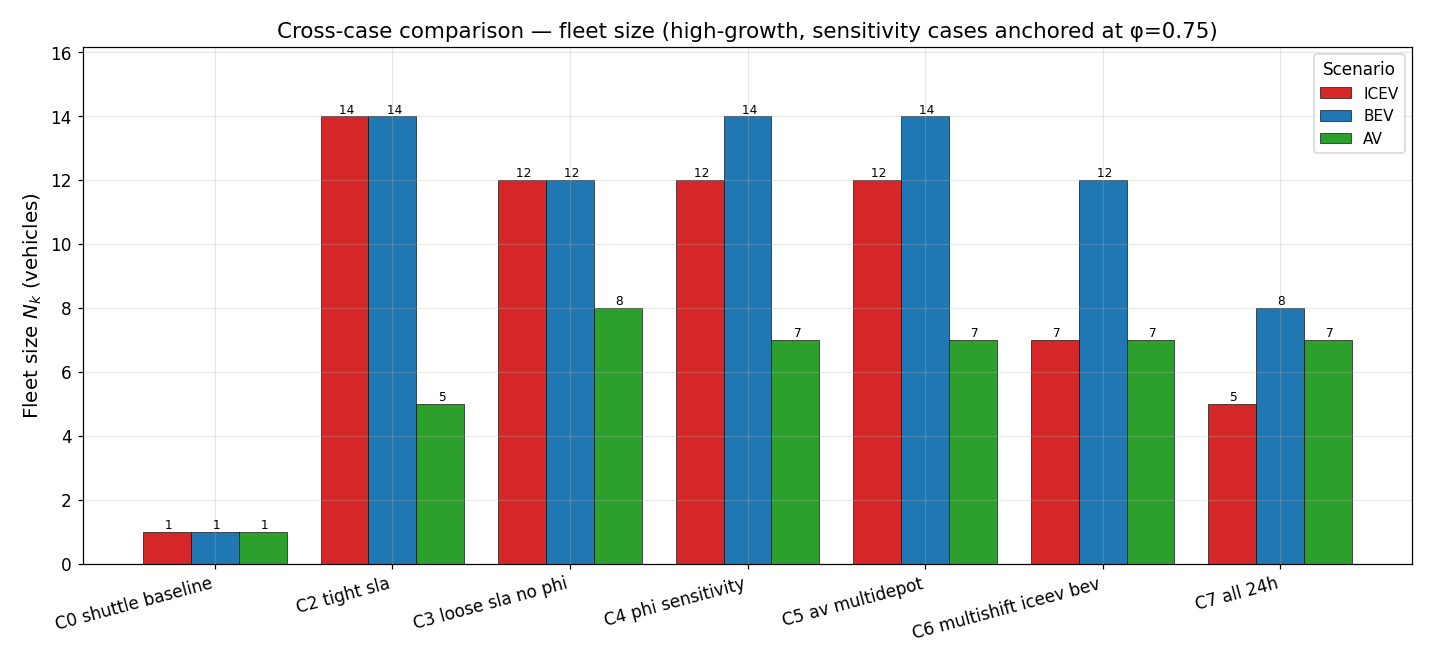

  Saved outputs\case_runs\comparison\high\plot_fleet_size_across_cases.png


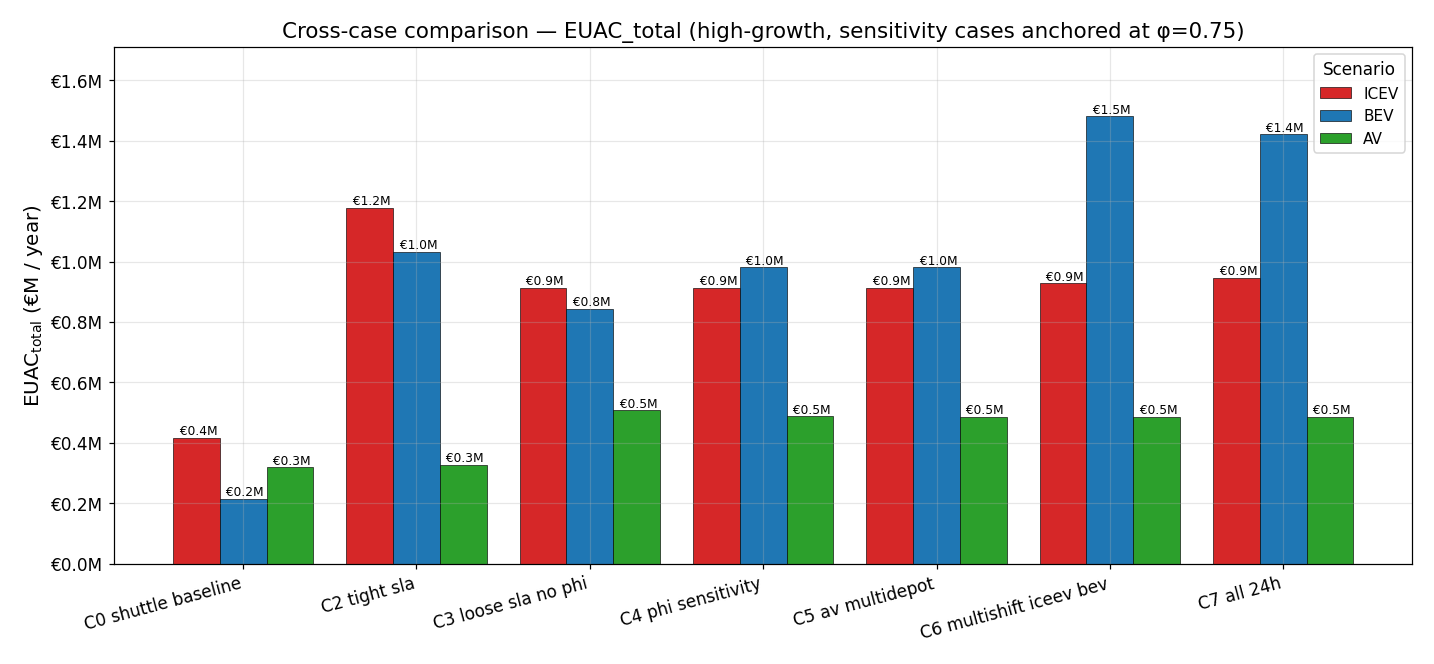

  Saved outputs\case_runs\comparison\high\plot_euac_across_cases.png


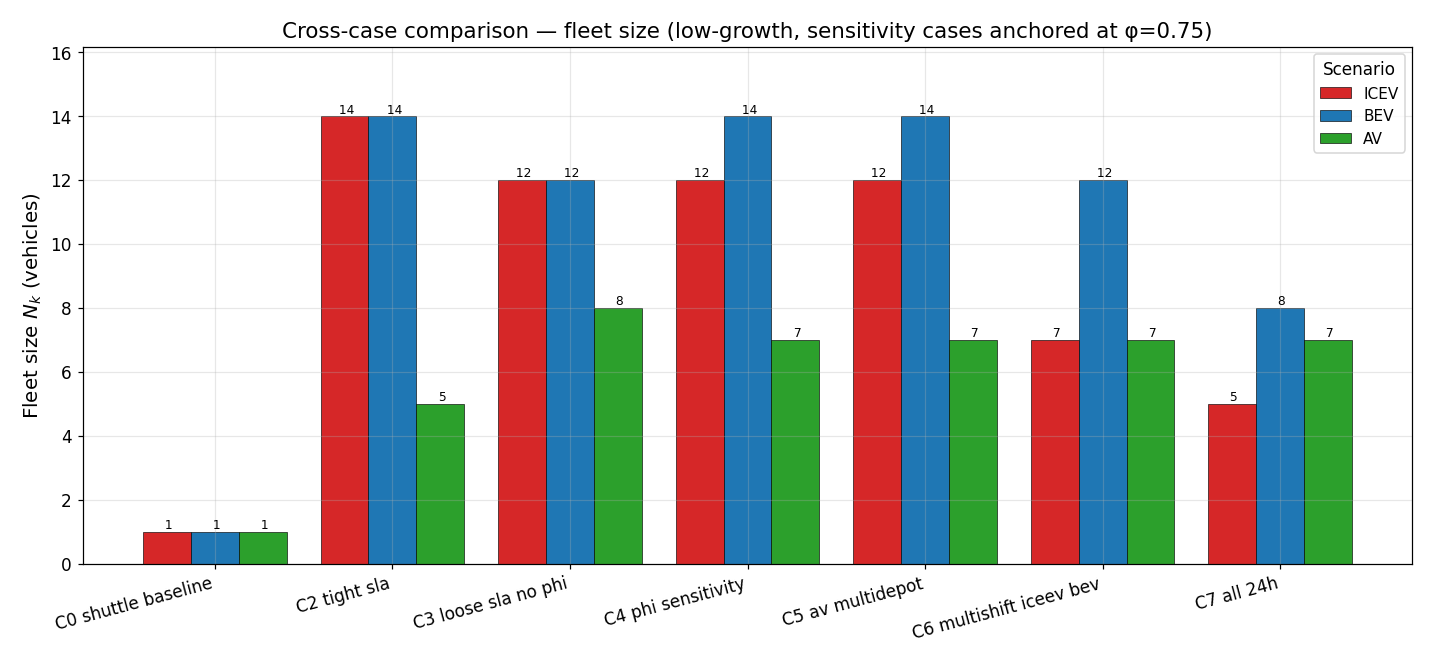

  Saved outputs\case_runs\comparison\low\plot_fleet_size_across_cases.png


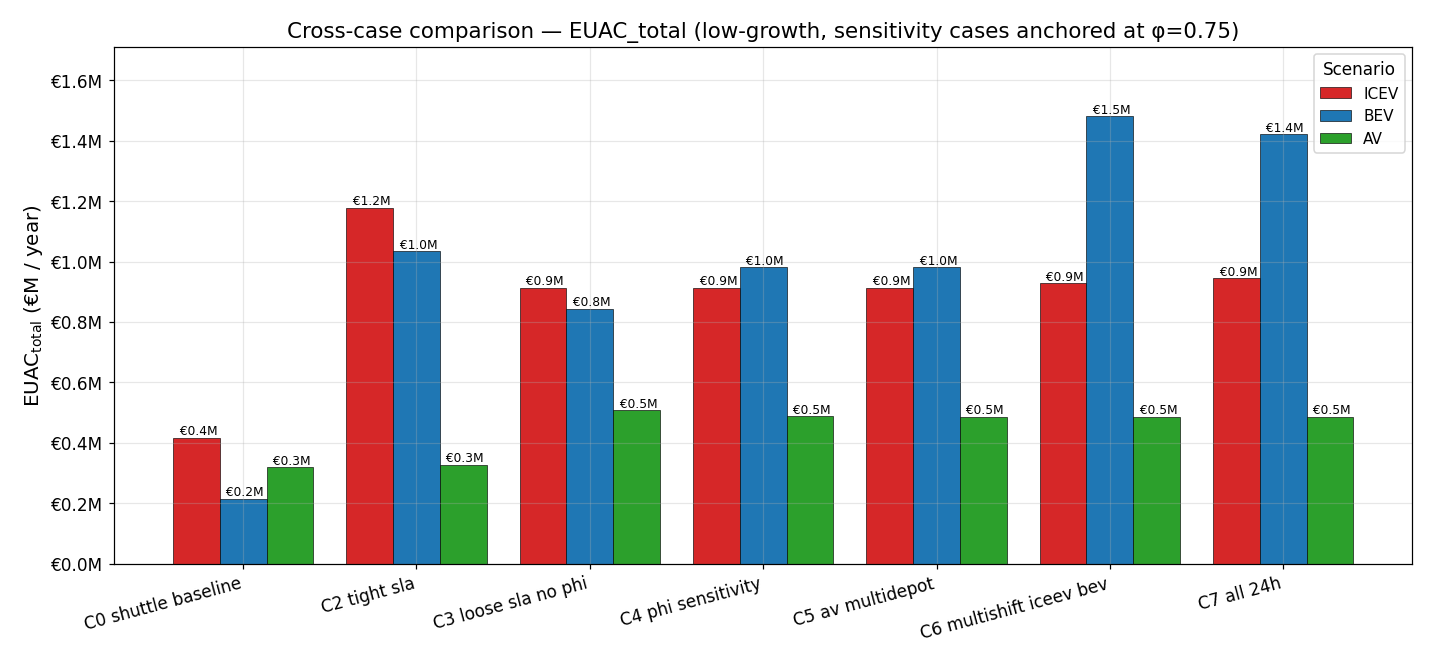

  Saved outputs\case_runs\comparison\low\plot_euac_across_cases.png
  Saved outputs\case_runs\comparison\case_ladder_summary.md


In [59]:
# =============================================================================
# CROSS-CASE COMPARISON — fleet size + EUAC_total per growth scenario
# =============================================================================
COMPARISON_DIR = CASE_RUNS_DIR / 'comparison'
COMPARISON_DIR.mkdir(exist_ok=True)

if not (CASE_RUNS_DIR / '_all_results.json').exists():
    print("No aggregate results found — run Module 16 first.")
else:
    with open(CASE_RUNS_DIR / '_all_results.json') as f:
        case_results_all = _json.load(f)

    # Reduce each case to a single (growth, scenario) → metric value, anchoring
    # sensitivity cases at headline_phi.
    case_meta_by_id = {c['id']: c for c in CASES}
    headline_rows = []
    for c in CASES:
        if not c.get('enabled', True):
            continue
        if c['mode'] == 'demand_only':
            continue
        case_data = case_results_all.get(c['name'])
        if not case_data:
            continue
        anchor_phi = c.get('headline_phi') or c['phi_values'][0]
        for growth_label, by_phi in case_data.items():
            # by_phi is keyed by float — when JSON-loaded the keys are strings
            # so try both
            cell = by_phi.get(anchor_phi) or by_phi.get(str(anchor_phi)) \
                   or by_phi.get(float(anchor_phi)) or list(by_phi.values())[0]
            for s in SCENARIO_NAMES:
                r = cell[s]
                headline_rows.append({
                    'case_id': c['id'], 'case_name': c['name'],
                    'growth_scenario': growth_label, 'phi_anchor': anchor_phi,
                    'scenario': s,
                    'fleet_size':    r['fleet_size'],
                    'EUAC_total':    r['EUAC_total'],
                    'EUAC_internal': r['EUAC_internal'],
                    'CO2_t':         r['CO2_t'],
                })
    headline_df = pd.DataFrame(headline_rows)
    headline_df.to_csv(COMPARISON_DIR / 'headline_table.csv', index=False)
    print(f"Wrote {len(headline_df)} rows → {COMPARISON_DIR / 'headline_table.csv'}")

    scen_colors = {'ICEV': '#d62728', 'BEV': '#1f77b4', 'AV': '#2ca02c'}

    for growth_label in sorted(headline_df['growth_scenario'].unique()):
        gdir = COMPARISON_DIR / growth_label
        gdir.mkdir(exist_ok=True)
        sub = headline_df[headline_df['growth_scenario'] == growth_label].copy()
        sub = sub.sort_values('case_id')

        # Build a stable case-name list for the x-axis (preserves ladder order)
        case_order = sub.drop_duplicates('case_id').sort_values('case_id')['case_name'].tolist()
        x = np.arange(len(case_order))
        width = 0.27

        # ----- Fleet size figure -----
        fig, ax = plt.subplots(figsize=(13, 6))
        for i, s in enumerate(SCENARIO_NAMES):
            vals = []
            for cn in case_order:
                row = sub[(sub['case_name'] == cn) & (sub['scenario'] == s)]
                vals.append(int(row['fleet_size'].iloc[0]) if not row.empty else 0)
            bars = ax.bar(x + (i - 1) * width, vals, width=width,
                          color=scen_colors[s], label=s, edgecolor='black', linewidth=0.4)
            for b, v in zip(bars, vals):
                ax.text(b.get_x() + b.get_width()/2, v, f' {v}',
                        ha='center', va='bottom', fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels([cn.replace('case_', 'C').replace('_', ' ') for cn in case_order],
                            rotation=15, ha='right')
        ax.set_ylabel('Fleet size $N_k$ (vehicles)')
        ax.set_title(f'Cross-case comparison — fleet size '
                     f'({growth_label}-growth, sensitivity cases anchored at φ=0.75)')
        ax.legend(title='Scenario'); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        # _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
        for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
            _y0, _y1 = _ax.get_ylim()
            if _y1 > _y0:
                _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
        plt.savefig(gdir / 'plot_fleet_size_across_cases.png', dpi=160, bbox_inches='tight')
        plt.show()
        print(f"  Saved {gdir / 'plot_fleet_size_across_cases.png'}")

        # ----- EUAC_total figure -----
        fig, ax = plt.subplots(figsize=(13, 6))
        for i, s in enumerate(SCENARIO_NAMES):
            vals = []
            for cn in case_order:
                row = sub[(sub['case_name'] == cn) & (sub['scenario'] == s)]
                vals.append(float(row['EUAC_total'].iloc[0]) / 1e6 if not row.empty else 0)
            bars = ax.bar(x + (i - 1) * width, vals, width=width,
                          color=scen_colors[s], label=s, edgecolor='black', linewidth=0.4)
            for b, v in zip(bars, vals):
                ax.text(b.get_x() + b.get_width()/2, v, f' €{v:.1f}M',
                        ha='center', va='bottom', fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels([cn.replace('case_', 'C').replace('_', ' ') for cn in case_order],
                            rotation=15, ha='right')
        ax.set_ylabel(r'EUAC$_{\mathrm{total}}$ (€M / year)')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{v:.1f}M'))
        ax.set_title(f'Cross-case comparison — EUAC_total '
                     f'({growth_label}-growth, sensitivity cases anchored at φ=0.75)')
        ax.legend(title='Scenario'); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        # _ylim_pad_applied — bump y-limit so top-of-bar labels stay inside the plot
        for _ax in (fig.get_axes() if 'fig' in dir() else [plt.gca()]):
            _y0, _y1 = _ax.get_ylim()
            if _y1 > _y0:
                _ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
        plt.savefig(gdir / 'plot_euac_across_cases.png', dpi=160, bbox_inches='tight')
        plt.show()
        print(f"  Saved {gdir / 'plot_euac_across_cases.png'}")

    # Summary markdown
    md_lines = ["# Case-ladder cross-case summary",
                "",
                "Anchored at **φ = 0.75** for sensitivity cases (4, 5, 6, 7).",
                "Non-anchor sensitivity values live in each case's own folder.", ""]
    for growth_label in sorted(headline_df['growth_scenario'].unique()):
        md_lines.append(f"## {growth_label}-growth scenario")
        md_lines.append("")
        sub = headline_df[headline_df['growth_scenario'] == growth_label]
        case_names = sub.drop_duplicates('case_id').sort_values('case_id')['case_name'].tolist()
        # Fleet size table
        md_lines.append("### Fleet size $N_k$ (vehicles)")
        md_lines.append("| Case | " + " | ".join(SCENARIO_NAMES) + " |")
        md_lines.append("| " + " | ".join(["---"] * (len(SCENARIO_NAMES) + 1)) + " |")
        for cn in case_names:
            row_parts = [cn.replace('case_', 'C').replace('_', ' ')]
            for s in SCENARIO_NAMES:
                row = sub[(sub['case_name'] == cn) & (sub['scenario'] == s)]
                row_parts.append(str(int(row['fleet_size'].iloc[0])) if not row.empty else "—")
            md_lines.append("| " + " | ".join(row_parts) + " |")
        md_lines.append("")
        # EUAC_total table
        md_lines.append("### EUAC$_\\text{total}$ (€M / year)")
        md_lines.append("| Case | " + " | ".join(SCENARIO_NAMES) + " |")
        md_lines.append("| " + " | ".join(["---"] * (len(SCENARIO_NAMES) + 1)) + " |")
        for cn in case_names:
            row_parts = [cn.replace('case_', 'C').replace('_', ' ')]
            for s in SCENARIO_NAMES:
                row = sub[(sub['case_name'] == cn) & (sub['scenario'] == s)]
                row_parts.append(f"€{row['EUAC_total'].iloc[0]/1e6:.2f}M" if not row.empty else "—")
            md_lines.append("| " + " | ".join(row_parts) + " |")
        md_lines.append("")
        # CO2 table
        md_lines.append("### Annual CO₂ emissions (tonnes / year)")
        md_lines.append("| Case | " + " | ".join(SCENARIO_NAMES) + " |")
        md_lines.append("| " + " | ".join(["---"] * (len(SCENARIO_NAMES) + 1)) + " |")
        for cn in case_names:
            row_parts = [cn.replace('case_', 'C').replace('_', ' ')]
            for s in SCENARIO_NAMES:
                row = sub[(sub['case_name'] == cn) & (sub['scenario'] == s)]
                row_parts.append(f"{row['CO2_t'].iloc[0]:.1f}" if not row.empty else "—")
            md_lines.append("| " + " | ".join(row_parts) + " |")
        md_lines.append("")
    (COMPARISON_DIR / 'case_ladder_summary.md').write_text("\n".join(md_lines), encoding='utf-8')
    print(f"  Saved {COMPARISON_DIR / 'case_ladder_summary.md'}")


## Module 16c — Synthesis & per-trace plots (post-hoc, no re-run)

Reads the per-case caches and produces five additional plot families **without
re-running the full pipeline**:

1. **Per-trace fleet sizing** — for each case + growth scenario, a bar chart
   showing the fleet size each of the 10 MC traces would have required in
   isolation. Reveals which trace drove the chosen $N_k$ (max-of-max).
2. **Stacked EUAC decomposition** — for each case + growth scenario, the EUAC
   bar for each vehicle scenario, broken down into 8 components: CAPEX (capital
   recovery only), maintenance, energy, labour, viapass, insurance, SaaS, AEC
   (CO₂). Tells the reader exactly where the cost differences come from.
3. **Per-km cost breakdown** — same decomposition normalised by total annual
   km. Useful for comparing technologies at unit-cost level.
4. **CAPEX vs OPEX trade-off scatter** — each case plotted as 3 points
   (ICEV/BEV/AV) with CAPEX_EUAC on x, (OPEX+AEC) on y. Visualises the AV
   "high CAPEX, low OPEX" trade-off as you progress through the case ladder.
5. **EUAC tornado for cases 4 & 5** — horizontal bars showing how each
   scenario's EUAC changes when φ moves to the extremes of the sensitivity
   range (0.65 ↔ 0.85). Quickly conveys which scenario is most loading-sensitive.

### Cache augmentation (one-time)

The current cache cells don't carry per-trace details or split CAPEX/maintenance
EUAC. This module's first pass computes those and persists them back into each
case's `cache.json`. Subsequent runs of this cell are pure rendering (~5 seconds).

Computing per-trace details requires re-running `size_fleet_robust` on the
relevant traces — this re-routes the demand but is much cheaper than the full
pipeline (no CAPEX/OPEX/AEC recomputation). Estimated one-time cost: **~10–15
minutes** for all 5 case folders that have routing data (case 1 is demand-only
and is skipped).


In [61]:
# =============================================================================
# MODULE 16c — Synthesis & per-trace plots from cache (no re-run)
# =============================================================================
SYNTHESIS_REGEN = True   # set False to skip Pass 1 (cache augmentation)

# Component colours (used across all stacked-bar plots in this module)
COMPONENT_COLORS = {
    'CAPEX':     '#7c3aed',   # purple
    'maint':     '#a78bfa',   # light purple
    'energy':    '#f59e0b',   # amber
    'labour':    '#ef4444',   # red
    'viapass':   '#6b7280',   # grey
    'insurance': '#9ca3af',   # lighter grey
    'saas':      '#06b6d4',   # cyan
    'AEC':       '#10b981',   # green
}
COMPONENT_ORDER = ['CAPEX', 'maint', 'energy', 'labour',
                    'viapass', 'insurance', 'saas', 'AEC']


# ---------------------------------------------------------------------------
# Pass 1: augment each case cache with per-trace details + CAPEX/maint split
# ---------------------------------------------------------------------------
def _split_capex_maint(scenario, fleet_size, life_years, cfg):
    """Return (capex_euac_only, maintenance_euac).

    Reuses helpers already defined upstream (Module 11/12). The original
    `fleet_capex_euac` bundles capital recovery + maintenance into one number;
    this splits them by computing each part independently.
    """
    capex_per_vehicle = scenario.vehicle_cost + scenario.infra_cost_per_vehicle
    tax_rate = cfg['lifecycle']['corporate_tax_rate']
    tax_shield = capex_per_vehicle * scenario.ze_writeoff_pct * tax_rate
    capex_after_subsidy = capex_per_vehicle - tax_shield
    salvage = salvage_value(capex_per_vehicle, life_years, scenario.depreciation_rate)
    discount = cfg['lifecycle']['discount_rate_i']

    # CAPEX-only EUAC (capital recovery, ignoring maintenance)
    capex_only_per_vehicle = equivalent_uniform_annual_cost(
        capex_now=capex_after_subsidy,
        annual_costs=[0.0] * life_years,
        salvage_at_end=salvage,
        discount_rate=discount,
    )

    # Maintenance-only EUAC (same draws as Module 12 to keep numbers consistent)
    rng = np.random.default_rng(SEEDS['maintenance_noise'])
    ref_cost = reference_annual_cost(scenario, cfg, ANNUAL_KM_REF)
    annual_maint = [
        annual_maintenance_cost(y, scenario, ref_cost, rng)
        for y in range(1, life_years + 1)
    ]
    maint_per_vehicle = equivalent_uniform_annual_cost(
        capex_now=0.0,
        annual_costs=annual_maint,
        salvage_at_end=0.0,
        discount_rate=discount,
    )
    return capex_only_per_vehicle * fleet_size, maint_per_vehicle * fleet_size


def _augment_one_cache(case: dict, case_dir: Path):
    """In-place augment of one case's cache with per-trace + split details."""
    cache_path = case_dir / 'cache.json'
    if not cache_path.exists():
        return
    with open(cache_path) as f:
        cache = _json.load(f)
    if 'cells' not in cache or not cache['cells']:
        return

    # Pre-build the per-(growth, phi) trace context lazily
    traces_by_growth: Dict[str, dict] = {}
    n_augmented = 0

    for cell_key, cell in list(cache['cells'].items()):
        # cell_key format: "growth|phi=X.YY|sig=ABCDEF..."
        # Require fleet_size_float in every per_trace record so the new
        # per-trace plot can show the pre-ceiling formula value alongside the
        # integer. Cells from older runs are missing this field, so this
        # idempotency check triggers re-augmentation in that case.
        has_float = (
            'per_trace' in cell
            and isinstance(cell.get('per_trace'), dict)
            and all(
                isinstance(recs, list) and
                (not recs or ('fleet_size_float' in recs[0]
                               and 'packing_n' in recs[0]
                               and 'formula_n' in recs[0]
                               and 'H_empirical' in recs[0]
                               and 'time_packing_float' in recs[0]
                               and 'fleet_size_float_combined' in recs[0]))
                for recs in cell['per_trace'].values()
            )
        )
        # The CAPEX/maint split is written into cell[scenario][...] (NOT at the
        # cell level), so check nested for the idempotency guard.
        has_capex_split = all(
            s_name in cell
            and 'capex_euac_only' in cell.get(s_name, {})
            and 'maintenance_euac' in cell.get(s_name, {})
            for s_name in SCENARIO_NAMES
        )
        already_done = has_float and has_capex_split

        # Always overwrite case-level fleet_size_float / formula_n / packing_n /
        # driver from the per_trace records. This corrects stale values written
        # by earlier augmentation runs (old code used setdefault which never
        # overwrites). Done here so it runs even on already_done cache hits.
        if 'per_trace' in cell and isinstance(cell.get('per_trace'), dict):
            for _sn in SCENARIO_NAMES:
                if _sn not in cell or _sn not in cell['per_trace']:
                    continue
                _recs = cell['per_trace'][_sn]
                if not _recs:
                    continue
                # Chosen-N trace = the one with the largest fleet_size
                _chosen_rec = max(_recs, key=lambda r: r['fleet_size'])
                cell[_sn]['fleet_size_float'] = float(
                    _chosen_rec.get('formula_float',
                    _chosen_rec.get('fleet_size_float',
                    cell[_sn]['fleet_size'])))
                cell[_sn]['formula_n']         = int(_chosen_rec.get('formula_n', 0))
                cell[_sn]['packing_n']         = int(_chosen_rec.get('packing_n', 0))
                cell[_sn]['driver']            = str(_chosen_rec.get('driver', 'formula'))
                cell[_sn]['H_empirical']                = float(_chosen_rec.get('H_empirical', 1.0))
                cell[_sn]['worst_day_tours']            = int(_chosen_rec.get('worst_day_tours', 0))
                cell[_sn]['worst_day_vehicles']         = int(_chosen_rec.get('worst_day_vehicles', 0))
                cell[_sn]['time_packing_float']         = float(_chosen_rec.get('time_packing_float', 0.0))
                cell[_sn]['fleet_size_float_combined']  = float(_chosen_rec.get(
                    'fleet_size_float_combined',
                    _chosen_rec.get('formula_float', cell[_sn]['fleet_size'])))

        if already_done:
            continue

        growth_label = cell_key.split('|')[0]
        phi_str      = cell_key.split('|')[1].replace('phi=', '')
        phi          = float(phi_str)

        # Re-route to get per-trace fleet sizes (only if needed)
        if 'per_trace' not in cell:
            if growth_label not in traces_by_growth:
                growth_rate = CONFIG['demand']['growth_scenarios'][growth_label]
                print(f"      [{case['name']}] regenerating traces for "
                      f"{growth_label}...", flush=True)
                traces_by_growth[growth_label] = _regenerate_traces_for_growth(growth_rate)
            local_traces = traces_by_growth[growth_label]

            # Apply same overrides + AV multi-depot toggle that the case used,
            # plus the cell-specific phi, so size_fleet_robust matches the
            # original run exactly.
            overrides = case.get('config_overrides', {})
            saved = _apply_overrides(overrides) if overrides else {}
            av_md_prev = None
            if 'fleet_sizing.av_multi_depot_enabled' in overrides:
                av_md_prev = _set_av_multi_depot(
                    overrides['fleet_sizing.av_multi_depot_enabled']
                )
            scenario_snapshot = _push_scenario_overrides(overrides)
            saved_phi = CONFIG['fleet_sizing']['load_factor_phi']
            CONFIG['fleet_sizing']['load_factor_phi'] = phi
            try:
                per_trace_per_scenario = {}
                for s_name, scen in SCENARIOS.items():
                    _, detail = size_fleet_robust(
                        local_traces, zone_distances, CONFIG, scen, DIST_CTX,
                        mode=CONFIG['fleet_sizing']['routing_mode'],
                    )
                    # size_fleet_robust now stores formula_float / formula_n /
                    # packing_n / driver per trace. We persist all of them so
                    # the per-trace plot can show what drove the integer fleet
                    # size on each trace. Cost calculations use fleet_size only.
                    d = detail.copy()
                    # Defensive: if the detail came from an older size_fleet_robust
                    # build that lacks the new columns, fall back to recomputing
                    # formula_float from max_daily_kg (and set the rest to safe values).
                    if 'formula_float' not in d.columns:
                        H = scen.daily_hours
                        A = scen.availability
                        C = CONFIG['fleet_sizing']['vehicle_capacity_kg']
                        eta_v = CONFIG['fleet_sizing']['utilization_eta']
                        kg_per_v_day = H * (C * phi) * eta_v * A
                        d['formula_float'] = (d['max_daily_kg'] / kg_per_v_day
                                                if kg_per_v_day > 0 else float('nan'))
                        d['formula_n']     = np.ceil(d['formula_float']).astype(int)
                        d['packing_n']     = 0
                        d['driver']        = 'formula'
                    # Alias for back-compat: code reading 'fleet_size_float' still works
                    d['fleet_size_float'] = d['formula_float']
                    per_trace_per_scenario[s_name] = (
                        d[['trace', 'fleet_size', 'fleet_size_float',
                           'formula_float', 'formula_n', 'packing_n', 'driver',
                           'H_empirical', 'worst_day_tours', 'worst_day_vehicles',
                           'time_packing_float', 'fleet_size_float_combined',
                           'max_daily_kg', 'avg_daily_vh',
                           'max_daily_vh', 'avg_daily_km']]
                        .astype({'trace': int, 'fleet_size': int,
                                  'formula_n': int, 'packing_n': int,
                                  'worst_day_tours': int, 'worst_day_vehicles': int})
                        .to_dict(orient='records')
                    )


            finally:
                CONFIG['fleet_sizing']['load_factor_phi'] = saved_phi
                if saved:
                    _restore_overrides(saved)
                if av_md_prev is not None:
                    SCENARIOS['AV'].multi_depot = av_md_prev
                if scenario_snapshot:
                    _restore_scenario_overrides(scenario_snapshot)

            cell['per_trace'] = per_trace_per_scenario

        # CAPEX/maint split (cheap, no traces needed). Skip if every scenario
        # already has both keys nested under cell[scenario].
        needs_split = not all(
            s_name in cell
            and 'capex_euac_only' in cell.get(s_name, {})
            and 'maintenance_euac' in cell.get(s_name, {})
            for s_name in SCENARIO_NAMES
        )
        if needs_split:
            for s_name, scen in SCENARIOS.items():
                if s_name not in cell:
                    continue
                r = cell[s_name]
                capex_only, maint_eu = _split_capex_maint(
                    scen, int(r['fleet_size']), int(r['service_life_years']),
                    CONFIG,
                )
                r['capex_euac_only']    = float(capex_only)
                r['maintenance_euac']   = float(maint_eu)

        n_augmented += 1

    if n_augmented > 0:
        with open(cache_path, 'w', encoding='utf-8') as f:
            _json.dump(cache, f, indent=1)
        print(f"    [{case['name']}] augmented {n_augmented} cell(s) "
              f"(per_trace + CAPEX/maint split)")
    return cache


# Run augmentation pass over all enabled cases that have routing data
print("=" * 76)
print("MODULE 16c — Pass 1: cache augmentation")
print("=" * 76)
all_caches = {}
if SYNTHESIS_REGEN:
    for case in CASES:
        if not case.get('enabled', True):
            continue
        if case['mode'] == 'demand_only':
            continue
        case_dir = CASE_RUNS_DIR / case['name']
        c = _augment_one_cache(case, case_dir)
        if c is not None:
            all_caches[case['name']] = c
    print("  Augmentation pass done.\n")
else:
    print("  SYNTHESIS_REGEN=False — skipping. Re-loading existing caches...")
    for case in CASES:
        if case['mode'] == 'demand_only': continue
        cp = CASE_RUNS_DIR / case['name'] / 'cache.json'
        if cp.exists():
            with open(cp) as f:
                all_caches[case['name']] = _json.load(f)


# ---------------------------------------------------------------------------
# Pass 2: render plots from augmented caches
# ---------------------------------------------------------------------------
print("=" * 76)
print("MODULE 16c — Pass 2: rendering synthesis plots")
print("=" * 76)
SCEN_COLORS = {'ICEV': '#d62728', 'BEV': '#1f77b4', 'AV': '#2ca02c'}


def _resolve_anchor_cell(cache: dict, case: dict, growth_label: str) -> Optional[dict]:
    """Return the cache cell at the headline phi (or single phi) for this growth."""
    phi = case.get('headline_phi') or case['phi_values'][0]
    if phi is None:
        return None
    for cell_key, cell in cache.get('cells', {}).items():
        if not cell_key.startswith(f"{growth_label}|phi="):
            continue
        cell_phi = float(cell_key.split('|')[1].replace('phi=', ''))
        if abs(cell_phi - float(phi)) < 1e-6:
            return cell
    return None


# ---------------------------------------------------------------------------
# Plot family 1 — Per-trace fleet sizing (one figure PER GROWTH per case)
#
# Each figure shows three side-by-side box plots (ICEV / BEV / AV) for the
# 10 Monte Carlo traces. Overlaid on each box:
#   - 10 filled dots: the rounded integer fleet size per trace
#         (each is max(ceil(formula), packing) — the operationally meaningful
#          number that ALL cost calculations actually use)
#   - 10 hollow X markers: the raw float from the thesis formula,
#         N_k_float = W_max / (H · C · φ · η · A)
#         (display-only diagnostic — shows pre-ceiling continuous value)
#   - Dashed horizontal line: the experiment-wide chosen N_k = max over the
#     10 traces of the integer.
# ---------------------------------------------------------------------------
print("\n[1/5] Per-trace fleet sizing box plots (split per growth)...")
for case in CASES:
    if not case.get('enabled', True) or case['mode'] == 'demand_only':
        continue
    cache = all_caches.get(case['name'])
    if not cache:
        continue
    syn_dir = CASE_RUNS_DIR / case['name'] / 'synthesis'
    syn_dir.mkdir(exist_ok=True)

    for growth_label in ['low', 'high']:
        cell = _resolve_anchor_cell(cache, case, growth_label)
        if cell is None or 'per_trace' not in cell:
            print(f"  {case['name']} / {growth_label}: missing per_trace data")
            continue

        # Collect per-scenario arrays: chosen integer, formula float, packing int
        scen_ints, scen_formula_floats, scen_packing_ints = {}, {}, {}
        chosen_per_scen = {}
        for s in SCENARIO_NAMES:
            recs = cell['per_trace'].get(s, [])
            ints = [int(r['fleet_size']) for r in recs]
            ffloats = [float(r.get('formula_float',
                                    r.get('fleet_size_float', r['fleet_size'])))
                        for r in recs]
            packs = [int(r.get('packing_n', 0)) for r in recs]
            scen_ints[s], scen_formula_floats[s], scen_packing_ints[s] = ints, ffloats, packs
            chosen_per_scen[s] = max(ints) if ints else 0

        fig, ax = plt.subplots(figsize=(11, 6))
        # Box plot of integers (the operationally chosen values per trace)
        box_data = [scen_ints[s] for s in SCENARIO_NAMES]
        bp = ax.boxplot(
            box_data, positions=np.arange(len(SCENARIO_NAMES)),
            widths=0.55, patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 1.6},
            whiskerprops={'linewidth': 1.0},
            capprops={'linewidth': 1.0},
            flierprops={'marker': 'd', 'markersize': 6,
                         'markerfacecolor': 'none', 'markeredgecolor': 'black'},
        )
        for patch, s in zip(bp['boxes'], SCENARIO_NAMES):
            patch.set_facecolor(SCEN_COLORS[s])
            patch.set_alpha(0.30)
            patch.set_edgecolor(SCEN_COLORS[s])
            patch.set_linewidth(1.4)

        # Three things plotted per trace, per scenario:
        #   • filled dot = the chosen integer fleet_size (= max(formula_n, packing_n))
        #   • hollow X   = the formula float (demand-only requirement, pre-ceiling)
        #   • plus '+'   = the packing integer (routing-geometry requirement)
        # Whichever of the X (rounded up) and + is larger drove the chosen integer.
        for i, s in enumerate(SCENARIO_NAMES):
            rng = np.random.default_rng(seed=hash(case['name'] + s) & 0xffff)
            jitter = rng.uniform(-0.10, 0.10, size=len(scen_ints[s]))
            # Chosen integer (filled dots)
            ax.scatter(np.full(len(scen_ints[s]), i) + jitter,
                       scen_ints[s],
                       s=46, color=SCEN_COLORS[s], edgecolor='black',
                       linewidth=0.6, zorder=4,
                       label=f"Chosen integer (cost calc input)" if i == 0 else None)
            # Formula float (hollow X markers — demand-only requirement)
            ax.scatter(np.full(len(scen_formula_floats[s]), i) + jitter,
                       scen_formula_floats[s],
                       s=70, marker='x', color=SCEN_COLORS[s],
                       linewidth=1.6, zorder=5,
                       label=f"Formula float (W/(H·C·φ·η·A))" if i == 0 else None)
            # Packing integer (plus markers — routing-geometry requirement)
            # zorder=5.5 so the + sits ABOVE the chosen-integer dot (zorder=4),
            # making the marker visible even when packing dominates and the two
            # markers coincide.
            ax.scatter(np.full(len(scen_packing_ints[s]), i) + jitter,
                       scen_packing_ints[s],
                       s=140, marker='+', color='black', edgecolor='black',
                       linewidth=2.0, zorder=5.5,
                       label=f"Packing integer (savings algo)" if i == 0 else None)
            # Chosen N_k horizontal line
            ax.hlines(chosen_per_scen[s], i - 0.42, i + 0.42,
                       color=SCEN_COLORS[s], linestyle='--', linewidth=1.5,
                       zorder=6,
                       label=f"Chosen $N_k$ (= max over traces)" if i == 0 else None)
            ax.text(i + 0.45, chosen_per_scen[s],
                    f' $N_k$={chosen_per_scen[s]}',
                    va='center', ha='left', fontsize=10,
                    color=SCEN_COLORS[s], fontweight='bold')

        ax.set_xticks(np.arange(len(SCENARIO_NAMES)))
        ax.set_xticklabels(SCENARIO_NAMES)
        ax.set_xlabel('Vehicle scenario')
        ax.set_ylabel('Fleet size for one MC trace (vehicles)')
        anchor_phi = case.get('headline_phi') or case['phi_values'][0]
        phi_str = f"  (φ={anchor_phi})" if anchor_phi != 1.0 else ""
        ax.set_title(f"{case['name']} — per-trace fleet-size distribution\n"
                      f"{growth_label}-growth{phi_str}, n=10 MC traces")

        # Consolidated legend (dedupe)
        handles, labels = ax.get_legend_handles_labels()
        seen = set(); h2, l2 = [], []
        for hd, lb in zip(handles, labels):
            if lb in seen: continue
            seen.add(lb); h2.append(hd); l2.append(lb)
        ax.legend(h2, l2, loc='best', fontsize=9, framealpha=0.92)

        # Y-axis padding so chosen-N_k labels don't kiss the top border
        _y0, _y1 = ax.get_ylim()
        ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
        ax.set_xlim(-0.65, len(SCENARIO_NAMES) - 0.35)

        plt.tight_layout()
        out = syn_dir / f'plot_per_trace_{growth_label}.png'
        plt.savefig(out, dpi=160, bbox_inches='tight')
        plt.close()
        print(f"  {out}")


# ---------------------------------------------------------------------------
# Plot family 2 — Stacked EUAC decomposition
# ---------------------------------------------------------------------------
def _component_values(cell_one: dict) -> dict:
    """Pull all 8 component values out of one (case, growth, phi, scenario) cell."""
    return {
        'CAPEX':     cell_one.get('capex_euac_only', cell_one['capex_euac']),
        'maint':     cell_one.get('maintenance_euac', 0.0),
        'energy':    cell_one['energy'],
        'labour':    cell_one['labour'],
        'viapass':   cell_one['viapass'],
        'insurance': cell_one['insurance'],
        'saas':      cell_one.get('saas', 0.0),
        'AEC':       cell_one['AEC_co2'],
    }


print("\n[2/5] Stacked EUAC decomposition plots (split per growth)...")
for case in CASES:
    if not case.get('enabled', True) or case['mode'] == 'demand_only':
        continue
    cache = all_caches.get(case['name'])
    if not cache:
        continue
    syn_dir = CASE_RUNS_DIR / case['name'] / 'synthesis'

    for growth_label in ['low', 'high']:
        cell = _resolve_anchor_cell(cache, case, growth_label)
        if cell is None:
            continue
        fig, ax = plt.subplots(figsize=(9, 6.5))
        x = np.arange(len(SCENARIO_NAMES))
        bottoms = np.zeros(len(SCENARIO_NAMES))
        for comp in COMPONENT_ORDER:
            vals = np.array([_component_values(cell[s])[comp]
                              for s in SCENARIO_NAMES]) / 1e6
            ax.bar(x, vals, bottom=bottoms, color=COMPONENT_COLORS[comp],
                   label=comp, edgecolor='white', linewidth=0.4)
            for i, (v, b) in enumerate(zip(vals, bottoms)):
                if v > 0.05:
                    ax.text(x[i], b + v / 2, f"{comp}\n€{v:.2f}M",
                            ha='center', va='center', fontsize=9, color='white',
                            fontweight='bold')
            bottoms += vals
        for i, total in enumerate(bottoms):
            ax.text(x[i], total + 0.05, f"Σ €{total:.2f}M",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(SCENARIO_NAMES)
        ax.set_ylabel("EUAC (€M / year)")
        anchor_phi = case.get('headline_phi') or case['phi_values'][0]
        phi_str = f"  (φ={anchor_phi})" if anchor_phi != 1.0 else ""
        ax.set_title(f"{case['name']} — EUAC component decomposition\n"
                      f"{growth_label}-growth{phi_str}")
        ax.legend(loc='upper right', fontsize=10, framealpha=0.92)
        _y0, _y1 = ax.get_ylim()
        ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
        plt.tight_layout()
        out = syn_dir / f'plot_euac_decomposition_{growth_label}.png'
        plt.savefig(out, dpi=160, bbox_inches='tight')
        plt.close()
        print(f"  {out}")


# ---------------------------------------------------------------------------
# Plot family 3 — Per-km cost breakdown
# ---------------------------------------------------------------------------
print("\n[3/5] Per-km cost breakdown plots (split per growth)...")
for case in CASES:
    if not case.get('enabled', True) or case['mode'] == 'demand_only':
        continue
    cache = all_caches.get(case['name'])
    if not cache:
        continue
    syn_dir = CASE_RUNS_DIR / case['name'] / 'synthesis'

    for growth_label in ['low', 'high']:
        cell = _resolve_anchor_cell(cache, case, growth_label)
        if cell is None:
            continue
        fig, ax = plt.subplots(figsize=(9, 6.5))
        x = np.arange(len(SCENARIO_NAMES))
        bottoms = np.zeros(len(SCENARIO_NAMES))
        for comp in COMPONENT_ORDER:
            vals = []
            for s in SCENARIO_NAMES:
                comp_eur = _component_values(cell[s])[comp]
                km_year = cell[s].get('annual_km_total', 1e-9)
                vals.append(comp_eur / km_year if km_year > 0 else 0.0)
            vals = np.array(vals)
            ax.bar(x, vals, bottom=bottoms, color=COMPONENT_COLORS[comp],
                   label=comp, edgecolor='white', linewidth=0.4)
            for i, (v, b) in enumerate(zip(vals, bottoms)):
                if v > 0.05:
                    ax.text(x[i], b + v / 2, f"{comp}\n€{v:.2f}",
                            ha='center', va='center', fontsize=9,
                            color='white', fontweight='bold')
            bottoms += vals
        for i, total in enumerate(bottoms):
            ax.text(x[i], total + 0.02, f"Σ €{total:.2f}/km",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(SCENARIO_NAMES)
        ax.set_ylabel("Cost per km (€)")
        anchor_phi = case.get('headline_phi') or case['phi_values'][0]
        phi_str = f"  (φ={anchor_phi})" if anchor_phi != 1.0 else ""
        ax.set_title(f"{case['name']} — per-km cost decomposition\n"
                      f"{growth_label}-growth{phi_str}")
        ax.legend(loc='upper right', fontsize=10, framealpha=0.92)
        _y0, _y1 = ax.get_ylim()
        ax.set_ylim(_y0, _y0 + (_y1 - _y0) * 1.10)
        plt.tight_layout()
        out = syn_dir / f'plot_per_km_breakdown_{growth_label}.png'
        plt.savefig(out, dpi=160, bbox_inches='tight')
        plt.close()
        print(f"  {out}")


# ---------------------------------------------------------------------------
# Plot family 4 — CAPEX vs OPEX+AEC scatter, cross-case
# ---------------------------------------------------------------------------
print("\n[4/5] CAPEX vs OPEX trade-off scatter (cross-case)...")
SCATTER_DIR = CASE_RUNS_DIR / 'comparison' / 'scatter'
SCATTER_DIR.mkdir(parents=True, exist_ok=True)

scen_markers = {'ICEV': 'o', 'BEV': 's', 'AV': '^'}
case_palette = plt.cm.viridis(np.linspace(0.05, 0.95, len(CASES)))
case_color_map = {c['name']: case_palette[idx] for idx, c in enumerate(CASES)}

for growth_label in ['low', 'high']:
    fig, ax = plt.subplots(figsize=(10, 7))
    for case in CASES:
        if not case.get('enabled', True) or case['mode'] == 'demand_only':
            continue
        cache = all_caches.get(case['name'])
        if not cache:
            continue
        cell = _resolve_anchor_cell(cache, case, growth_label)
        if cell is None: continue
        color = case_color_map[case['name']]
        for s in SCENARIO_NAMES:
            r = cell[s]
            capex = (r.get('capex_euac_only', r['capex_euac'])
                     + r.get('maintenance_euac', 0.0)) / 1e6   # x-axis: CAPEX + maint
            opex_aec = (r['EUAC_total'] - r['capex_euac']) / 1e6   # y-axis: opex + AEC
            ax.scatter(capex, opex_aec, s=180, color=color,
                       marker=scen_markers[s], edgecolor='black', linewidth=0.8,
                       alpha=0.85)
            ax.annotate(f"{case['name'].split('_')[1]}-{s}", (capex, opex_aec),
                        xytext=(7, 5), textcoords='offset points', fontsize=7)
    # Iso-EUAC lines for reference
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    max_v = max(xlim[1], ylim[1])
    for iso in [1.0, 1.5, 2.0, 2.5, 3.0]:
        xs = np.linspace(0, iso, 100); ys = iso - xs
        mask = (xs >= 0) & (ys >= 0) & (xs <= max_v) & (ys <= max_v)
        ax.plot(xs[mask], ys[mask], color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        if mask.any():
            ax.text(xs[mask][-1] + 0.02, ys[mask][-1] - 0.02,
                    f"€{iso:.1f}M iso", fontsize=7, color='gray', alpha=0.7)

    # Legends: case (colour) and scenario (marker)
    from matplotlib.lines import Line2D
    case_handles = [Line2D([0], [0], marker='o', color='w',
                            markerfacecolor=case_color_map[c['name']],
                            markersize=10, label=c['name'].replace('_', ' '))
                     for c in CASES if c.get('enabled', True) and c['mode'] != 'demand_only']
    scen_handles = [Line2D([0], [0], marker=scen_markers[s], color='w',
                            markerfacecolor='dimgray', markeredgecolor='black',
                            markersize=10, label=s)
                     for s in SCENARIO_NAMES]
    leg1 = ax.legend(handles=case_handles, loc='upper right', title='Case',
                      fontsize=7, framealpha=0.9)
    ax.add_artist(leg1)
    ax.legend(handles=scen_handles, loc='lower right', title='Scenario',
              fontsize=8, framealpha=0.9)

    ax.set_xlabel('CAPEX + Maintenance EUAC (€M / year)')
    ax.set_ylabel('OPEX (excl. maint) + AEC EUAC (€M / year)')
    ax.set_title(f'CAPEX vs OPEX trade-off across cases — {growth_label}-growth\n'
                  f'(sensitivity cases anchored at φ=0.75; dotted lines = iso-EUAC)')
    ax.grid(alpha=0.3); ax.set_aspect('auto')
    plt.tight_layout()
    out = SCATTER_DIR / f'capex_vs_opex_{growth_label}.png'
    plt.savefig(out, dpi=160, bbox_inches='tight')
    plt.close()
    print(f"  {out}")


# ---------------------------------------------------------------------------
# Plot family 5 — EUAC tornado for cases 4 and 5
# ---------------------------------------------------------------------------
print("\n[5/5] EUAC tornado plots (sensitivity cases, split per growth)...")
for case in CASES:
    if not case.get('enabled', True) or case['mode'] != 'sensitivity':
        continue
    cache = all_caches.get(case['name'])
    if not cache:
        continue
    syn_dir = CASE_RUNS_DIR / case['name'] / 'synthesis'
    phi_values = case['phi_values']
    anchor = case.get('headline_phi') or 0.75

    for growth_label in ['low', 'high']:
        # Find anchor / low / high phi cells in cache
        anchor_cell = None
        low_cell = None
        high_cell = None
        for cell_key, cell in cache['cells'].items():
            if not cell_key.startswith(f"{growth_label}|phi="):
                continue
            cell_phi = float(cell_key.split('|')[1].replace('phi=', ''))
            if abs(cell_phi - anchor) < 1e-6:
                anchor_cell = cell
            if abs(cell_phi - min(phi_values)) < 1e-6:
                low_cell = cell
            if abs(cell_phi - max(phi_values)) < 1e-6:
                high_cell = cell
        if not (anchor_cell and low_cell and high_cell):
            print(f"  {case['name']} / {growth_label}: incomplete sensitivity data, skipping tornado")
            continue

        fig, ax = plt.subplots(figsize=(11, 5.5))
        y = np.arange(len(SCENARIO_NAMES))
        for i, s in enumerate(SCENARIO_NAMES):
            anchor_e = anchor_cell[s]['EUAC_total'] / 1e6
            low_d  = low_cell[s]['EUAC_total']  / 1e6 - anchor_e
            high_d = high_cell[s]['EUAC_total'] / 1e6 - anchor_e
            ax.barh(y[i] + 0.18, low_d, height=0.32, color='#ef4444',
                    edgecolor='black', linewidth=0.5,
                    label=f'φ={min(phi_values)} (low loading)' if i == 0 else None)
            ax.barh(y[i] - 0.18, high_d, height=0.32, color='#10b981',
                    edgecolor='black', linewidth=0.5,
                    label=f'φ={max(phi_values)} (high loading)' if i == 0 else None)
            for d, off in [(low_d, 0.18), (high_d, -0.18)]:
                ax.text(d, y[i] + off, f"  €{d:+.2f}M  ",
                        ha='left' if d > 0 else 'right',
                        va='center', fontsize=10)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_yticks(y); ax.set_yticklabels(SCENARIO_NAMES)
        ax.set_xlabel(r'EUAC$_{\mathrm{total}}$ change vs anchor ' + f"(€M, φ={anchor})")
        ax.grid(axis='x', alpha=0.3)
        ax.legend(loc='best', fontsize=10)
        ax.set_title(f"{case['name']} — EUAC sensitivity tornado\n"
                      f"{growth_label}-growth (anchor φ={anchor}, "
                      f"range [{min(phi_values)}, {max(phi_values)}])")
        # Add horizontal padding so labels don't cross the side borders
        _x0, _x1 = ax.get_xlim()
        ax.set_xlim(_x0 * 1.18 if _x0 < 0 else _x0, _x1 * 1.18 if _x1 > 0 else _x1)
        plt.tight_layout()
        out = syn_dir / f'plot_tornado_{growth_label}.png'
        plt.savefig(out, dpi=160, bbox_inches='tight')
        plt.close()
        print(f"  {out}")

print("\n" + "=" * 76)
print("MODULE 16c COMPLETE")
print("=" * 76)


MODULE 16c — Pass 1: cache augmentation
      [case_0_shuttle_baseline] regenerating traces for low...
      [case_0_shuttle_baseline] regenerating traces for high...
    [case_0_shuttle_baseline] augmented 2 cell(s) (per_trace + CAPEX/maint split)
      [case_2_tight_sla] regenerating traces for low...
      [case_2_tight_sla] regenerating traces for high...
    [case_2_tight_sla] augmented 2 cell(s) (per_trace + CAPEX/maint split)
      [case_3_loose_sla_no_phi] regenerating traces for low...
      [case_3_loose_sla_no_phi] regenerating traces for high...
    [case_3_loose_sla_no_phi] augmented 2 cell(s) (per_trace + CAPEX/maint split)
      [case_4_phi_sensitivity] regenerating traces for low...
      [case_4_phi_sensitivity] regenerating traces for high...
    [case_4_phi_sensitivity] augmented 10 cell(s) (per_trace + CAPEX/maint split)
      [case_5_av_multidepot] regenerating traces for low...
      [case_5_av_multidepot] regenerating traces for high...
    [case_5_av_multidepot]

C:\Users\victo\AppData\Local\Temp\ipykernel_51332\1962447230.py:380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(np.full(len(scen_packing_ints[s]), i) + jitter,


  outputs\case_runs\case_0_shuttle_baseline\synthesis\plot_per_trace_low.png


C:\Users\victo\AppData\Local\Temp\ipykernel_51332\1962447230.py:380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(np.full(len(scen_packing_ints[s]), i) + jitter,


  outputs\case_runs\case_0_shuttle_baseline\synthesis\plot_per_trace_high.png


...

  outputs\case_runs\case_6_multishift_iceev_bev\synthesis\plot_per_trace_high.png


C:\Users\victo\AppData\Local\Temp\ipykernel_51332\1962447230.py:380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(np.full(len(scen_packing_ints[s]), i) + jitter,


  outputs\case_runs\case_7_all_24h\synthesis\plot_per_trace_low.png


C:\Users\victo\AppData\Local\Temp\ipykernel_51332\1962447230.py:380: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(np.full(len(scen_packing_ints[s]), i) + jitter,


  outputs\case_runs\case_7_all_24h\synthesis\plot_per_trace_high.png

[2/5] Stacked EUAC decomposition plots (split per growth)...
  outputs\case_runs\case_0_shuttle_baseline\synthesis\plot_euac_decomposition_low.png
  outputs\case_runs\case_0_shuttle_baseline\synthesis\plot_euac_decomposition_high.png
  outputs\case_runs\case_2_tight_sla\synthesis\plot_euac_decomposition_low.png
  outputs\case_runs\case_2_tight_sla\synthesis\plot_euac_decomposition_high.png
  outputs\case_runs\case_3_loose_sla_no_phi\synthesis\plot_euac_decomposition_low.png
  outputs\case_runs\case_3_loose_sla_no_phi\synthesis\plot_euac_decomposition_high.png
  outputs\case_runs\case_4_phi_sensitivity\synthesis\plot_euac_decomposition_low.png
  outputs\case_runs\case_4_phi_sensitivity\synthesis\plot_euac_decomposition_high.png
  outputs\case_runs\case_5_av_multidepot\synthesis\plot_euac_decomposition_low.png
  outputs\case_runs\case_5_av_multidepot\synthesis\plot_euac_decomposition_high.png
  outputs\case_runs\case_6

## Module 17 — Illustrative Tour Visualisation (Bonus)

This module reproduces the per-tour visualisation from the earlier exploratory
notebook in a thesis-ready form. **It is not part of the EUAC pipeline** —
the fleet-sizing numbers in Module 9 onwards already use the SLA-robust formula
across all 10 Monte Carlo traces. Module 17 picks one busy day from one trace
and shows what concrete pickup tours look like on that day, given the
locations' historical shares of network volume.

The module produces three outputs:

| File | Contents |
|------|----------|
| `outputs/illustrative_tours.html` | Interactive folium map with one toggleable layer per tour; tooltips show stop count, load (kg) and total road kilometres |
| `outputs/illustrative_tours.png`  | Static thesis-ready snapshot rendered with matplotlib (legend lists each tour's road km and load) |
| `outputs/illustrative_tours_summary.csv` | Per-tour summary table (tour, stops, load_kg, road_km, road_km_per_stop) |

For each tour, OSRM is queried with the full sequence (depot → stops → depot) so
the polyline drawn on the map follows actual Belgian roads. A single tour
summary line therefore reports its **real-road distance**, not haversine.

The greedy nearest-neighbour TSP used here is a heuristic, not optimal routing,
and the cost numbers it produces are not the ones reported by the EUAC
pipeline. Use Module 17's outputs as illustrations of *what daily operations
might look like* under the consolidated zone structure.


Visualising trace 0, day 624 (peak day; total demand: 17,941 kg)
Active locations on this day: 5,861 total, 43 with ≥ 30 kg (covering 27% of 17,941 kg)
Greedy NN produced 2 tours; rendering first 2
Querying OSRM for tour road geometries...
  Tour  1:  30 stops,  2.33 t,  595.9 km
  Tour  2:  13 stops,  2.54 t,  577.4 km

Summary table saved to outputs\illustrative_tours_summary.csv


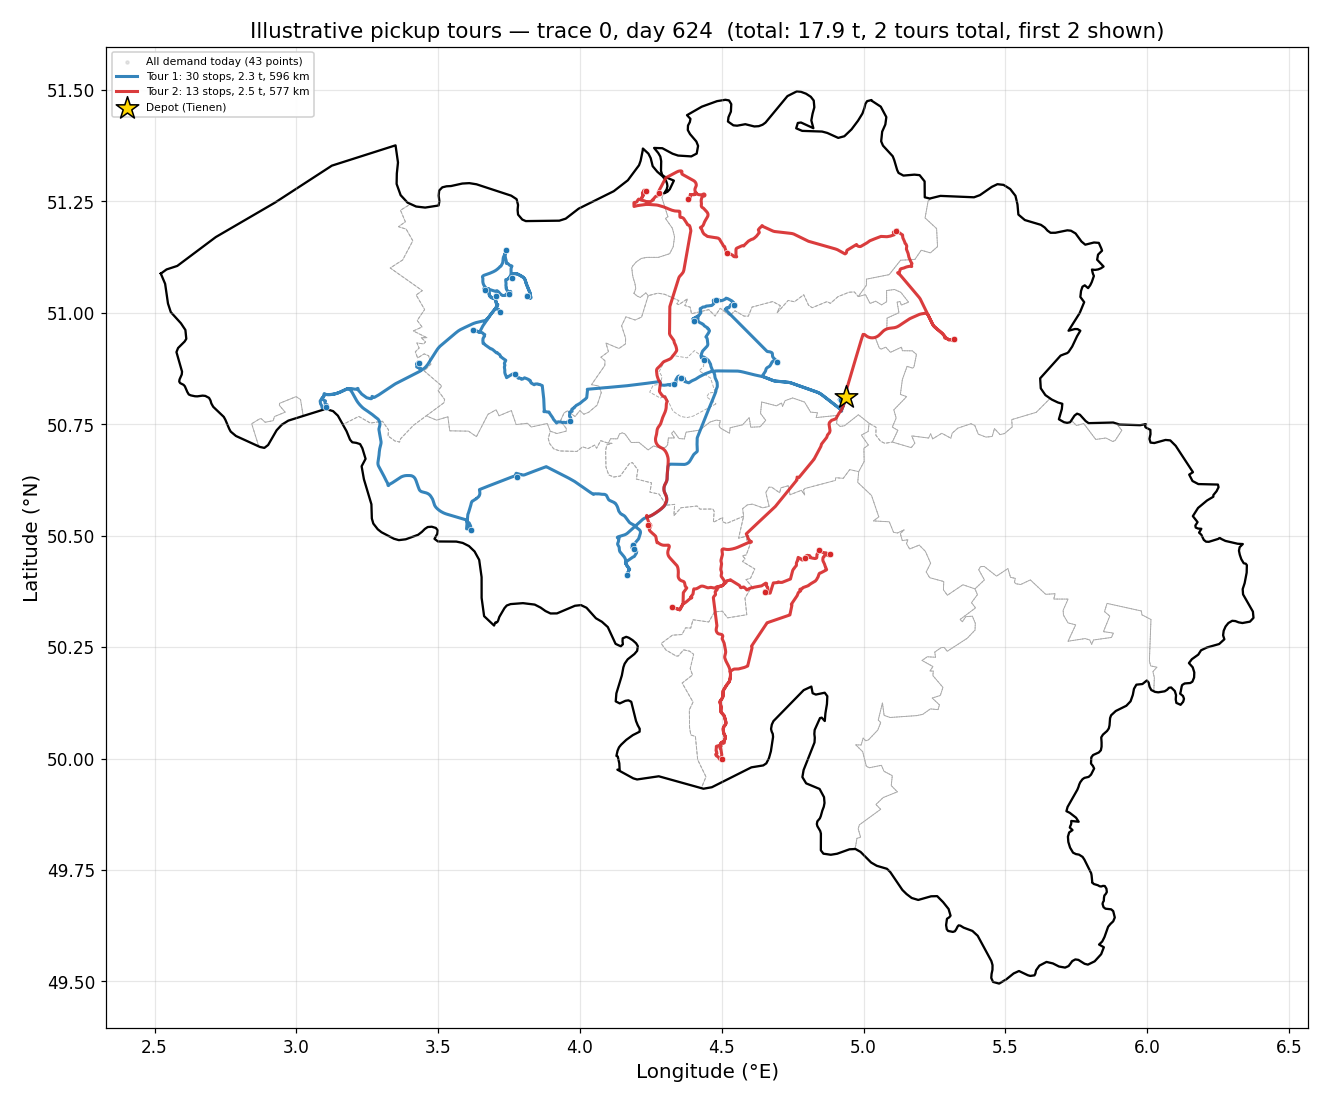

Static tour map saved to outputs\illustrative_tours.png
Interactive tour map saved to outputs\illustrative_tours.html


In [63]:
# =============================================================================
# ILLUSTRATIVE TOUR VISUALISATION — greedy TSP + OSRM road geometry
# Bonus module, not part of the EUAC pipeline.
# =============================================================================

DEPOT_LAT, DEPOT_LON = 50.8105, 4.9362  # Bebat HQ Tienen
TOUR_CAPACITY_KG     = CONFIG['fleet_sizing']['vehicle_capacity_kg']
N_TOURS_TO_VISUALISE = 12  # how many tours to draw on the map
MIN_PICKUP_KG        = 30  # minimum daily volume per location to be considered a 'stop'
MAX_STOPS_PER_TOUR   = 30  # operational realism cap (Bebat trucks rarely visit >30 stops/day)

# ---- OSRM helpers ---------------------------------------------------------
def osrm_route(points: List[Tuple[float, float]], timeout: float = 12.0):
    """Query OSRM for a multi-point route. Returns (geometry_lat_lon, total_km).

    On any failure, falls back to straight-line geometry and haversine × χ.
    """
    coords = ";".join(f"{p[1]},{p[0]}" for p in points)  # OSRM expects lng,lat
    url = f"{OSRM_BASE_URL}/{coords}?overview=full&geometries=geojson"
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            data = json.loads(resp.read())
            if data.get('code') == 'Ok':
                geo  = [[c[1], c[0]] for c in data['routes'][0]['geometry']['coordinates']]
                d_km = data['routes'][0]['distance'] / 1000.0
                return geo, d_km
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, json.JSONDecodeError):
        pass
    geo = [list(p) for p in points]
    chi = CONFIG['spatial']['circuity_factor']
    total = sum(float(haversine_km(a[0], a[1], b[0], b[1])) * chi
                for a, b in zip(points[:-1], points[1:]))
    return geo, total

def build_greedy_tours(stops: pd.DataFrame, depot_lat: float, depot_lon: float,
                       capacity_kg: float, max_stops: int = MAX_STOPS_PER_TOUR) -> List[Dict]:
    """Capacity-constrained nearest-neighbour tours; depot at start and end.

    A tour ends when EITHER the next stop would exceed capacity OR the tour
    already has `max_stops` stops (operational-realism cap).
    """
    remaining = stops.copy().reset_index(drop=True)
    tours = []
    while len(remaining) > 0:
        load = 0.0
        cur_lat, cur_lon = depot_lat, depot_lon
        tour_stops = []
        while len(remaining) > 0 and len(tour_stops) < max_stops:
            d = haversine_km(cur_lat, cur_lon,
                             remaining['lat'].values, remaining['lon'].values)
            idx = int(np.argmin(d))
            cand = remaining.iloc[idx]
            if load + cand['weight_kg'] > capacity_kg:
                break
            tour_stops.append({
                'lat': float(cand['lat']),
                'lon': float(cand['lon']),
                'name': cand.get('Location', 'unknown'),
                'weight_kg': float(cand['weight_kg']),
            })
            load += float(cand['weight_kg'])
            cur_lat, cur_lon = float(cand['lat']), float(cand['lon'])
            remaining = remaining.drop(remaining.index[idx]).reset_index(drop=True)
        tours.append({'stops': tour_stops, 'load_kg': load})
    return tours

# ---- Pick one trace + its busiest day ------------------------------------
trace_zero = traces[0]
day_totals = trace_zero.groupby('trace_day')['weight_kg'].sum()
sample_day = int(day_totals.idxmax())
day_demand_per_zone = trace_zero[trace_zero['trace_day'] == sample_day][['zone', 'weight_kg']]
day_total_kg = float(day_demand_per_zone['weight_kg'].sum())
print(f"Visualising trace 0, day {sample_day} (peak day; total demand: {day_total_kg:,.0f} kg)")

# ---- Translate per-zone daily demand into per-LOCATION pickup events ------
# Each zone's demand is distributed across its member locations using the
# same historical-share principle as Module 5 (top-down hierarchical alloc).
loc_meta = (
    df_long.groupby(['LocationNumber', 'Channel', 'Location'], as_index=False)['weight_kg']
           .sum()
           .rename(columns={'weight_kg': 'hist_total_kg'})
)
loc_meta['LocationNumber'] = loc_meta['LocationNumber'].astype(str)
# Attach zone + coordinates
loc_meta = loc_meta.merge(
    coords_with_zones[['lat', 'lon', 'zone']],
    left_on='LocationNumber', right_index=True, how='inner',
)
# Per-zone share s_i_zone = location's share of its zone's total historical weight
zone_totals = loc_meta.groupby('zone')['hist_total_kg'].transform('sum')
loc_meta['s_i_zone'] = loc_meta['hist_total_kg'] / zone_totals.replace(0, np.nan)

# Allocate today's per-zone demand back to per-location
day_per_zone = day_demand_per_zone.set_index('zone')['weight_kg']
loc_meta['daily_kg'] = loc_meta.apply(
    lambda r: r['s_i_zone'] * day_per_zone.get(r['zone'], 0.0), axis=1
)
# Keep only locations that received >0 today
active = loc_meta[loc_meta['daily_kg'] > 0].copy()

# Truncate to top locations covering ~95% of today's volume (to keep the map
# readable and to ignore micro-pickups < a few kg).
active = active.sort_values('daily_kg', ascending=False)
active['cum_share'] = active['daily_kg'].cumsum() / active['daily_kg'].sum()
active = active[active['cum_share'] <= 0.95].copy()
active = active.rename(columns={'daily_kg': 'weight_kg'}).dropna(subset=['lat', 'lon'])
n_before_filter = len(active)
active = active[active['weight_kg'] >= MIN_PICKUP_KG].copy()
print(f"Active locations on this day: {n_before_filter:,} total, "
      f"{len(active):,} with ≥ {MIN_PICKUP_KG} kg "
      f"(covering {100*active['weight_kg'].sum()/day_total_kg:.0f}% of {day_total_kg:,.0f} kg)")

tours = build_greedy_tours(active[['lat', 'lon', 'Location', 'weight_kg']],
                           DEPOT_LAT, DEPOT_LON, TOUR_CAPACITY_KG)
n_total = len(tours)
n_to_draw = min(N_TOURS_TO_VISUALISE, n_total)
print(f"Greedy NN produced {n_total} tours; rendering first {n_to_draw}")

# ---- Curated palette: distinct, print-friendly, sufficient contrast -------
TOUR_PALETTE = [
    "#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e",
    "#17becf", "#8c564b", "#e377c2", "#bcbd22", "#7f7f7f",
    "#1a9e77", "#7570b3", "#e7298a", "#66a61e", "#e6ab02",
    "#a6761d", "#666666", "#1b9e77", "#d95f02", "#7570b3",
]
def tour_color(i): return TOUR_PALETTE[i % len(TOUR_PALETTE)]

# ---- Compute road km for each rendered tour via OSRM ---------------------
print("Querying OSRM for tour road geometries...")
import time as _time
tour_data = []
for i, t in enumerate(tours[:n_to_draw]):
    pts = [(DEPOT_LAT, DEPOT_LON)] + [(s['lat'], s['lon']) for s in t['stops']] + [(DEPOT_LAT, DEPOT_LON)]
    geom, road_km = osrm_route(pts)
    tour_data.append({
        'index': i, 'tour_no': i + 1, 'stops': t['stops'],
        'load_kg': t['load_kg'], 'road_km': road_km, 'geometry': geom,
    })
    _time.sleep(0.05)
    print(f"  Tour {i+1:2d}: {len(t['stops']):3d} stops, "
          f"{t['load_kg']/1000:5.2f} t, {road_km:6.1f} km")

# ---- Per-tour CSV summary -------------------------------------------------
summary_df = pd.DataFrame([{
    'tour':         td['tour_no'],
    'stops':        len(td['stops']),
    'load_kg':      round(td['load_kg'], 1),
    'road_km':      round(td['road_km'], 1),
    'road_km_per_stop': round(td['road_km'] / max(len(td['stops']), 1), 2),
} for td in tour_data])
summary_csv = OUTPUT_DIR / 'illustrative_tours_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(f"\nSummary table saved to {summary_csv}")

# ---- (1) Static matplotlib PNG -------------------------------------------
fig, ax = plt.subplots(figsize=(13, 10))
def _draw_outline(ax, p, **kw):
    if not p.exists(): return
    with open(p, encoding='utf-8') as f:
        gj = json.load(f)
    for feat in gj['features']:
        geom = feat['geometry']
        polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for poly in polys:
            outer = poly[0]
            ax.plot([c[0] for c in outer], [c[1] for c in outer], **kw)
_draw_outline(ax, PROVINCES_GEOJSON, color='#aaaaaa', linewidth=0.6, linestyle='--', zorder=0.5)
_draw_outline(ax, COUNTRY_GEOJSON,   color='black',   linewidth=1.5, zorder=1.0)

# All other demand points faintly (context)
ax.scatter(active['lon'], active['lat'],
           s=4, c='#cccccc', alpha=0.5, zorder=1.5,
           label=f"All demand today ({len(active)} points)")

for td in tour_data:
    color = tour_color(td['index'])
    geom = td['geometry']
    if len(geom) >= 2:
        xs = [pt[1] for pt in geom]; ys = [pt[0] for pt in geom]
        ax.plot(xs, ys, color=color, linewidth=2.0, alpha=0.9, zorder=2,
                label=f"Tour {td['tour_no']}: {len(td['stops'])} stops, "
                      f"{td['load_kg']/1000:.1f} t, {td['road_km']:.0f} km")
    for s in td['stops']:
        ax.scatter(s['lon'], s['lat'], s=18, c=color,
                   edgecolors='white', linewidths=0.4, zorder=3)

ax.scatter(DEPOT_LON, DEPOT_LAT, s=240, c='#ffd700', marker='*',
           edgecolors='black', linewidths=1.0, zorder=5, label='Depot (Tienen)')

ax.set_aspect(1 / np.cos(np.radians(50.5)))
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f"Illustrative pickup tours — trace 0, day {sample_day}  "
             f"(total: {day_total_kg/1000:.1f} t, {n_total} tours total, "
             f"first {n_to_draw} shown)")
ax.legend(loc='upper left', fontsize=7, framealpha=0.92, ncol=1)
ax.grid(alpha=0.3)
plt.tight_layout()
png_path = OUTPUT_DIR / 'illustrative_tours.png'
plt.savefig(png_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"Static tour map saved to {png_path}")

# ---- (2) Interactive folium HTML -----------------------------------------
try:
    import folium
    m = folium.Map(location=[50.85, 4.5], zoom_start=8, tiles='cartodbpositron')
    if COUNTRY_GEOJSON.exists():
        with open(COUNTRY_GEOJSON, encoding='utf-8') as f:
            folium.GeoJson(json.load(f), name='Belgium boundary',
                style_function=lambda x: {'color':'black','weight':2,'fillOpacity':0}
            ).add_to(m)
    if PROVINCES_GEOJSON.exists():
        with open(PROVINCES_GEOJSON, encoding='utf-8') as f:
            folium.GeoJson(json.load(f), name='Provinces',
                style_function=lambda x: {'color':'#888','weight':1,'dashArray':'5,5','fillOpacity':0}
            ).add_to(m)

    folium.Marker([DEPOT_LAT, DEPOT_LON],
                  popup=f"<b>Depot Tienen</b><br>{n_total} tours dispatched today",
                  icon=folium.Icon(color='red', icon='home', prefix='fa')).add_to(m)

    for td in tour_data:
        color = tour_color(td['index'])
        layer_name = (f"Tour {td['tour_no']} — {len(td['stops'])} stops, "
                      f"{td['load_kg']/1000:.2f} t, {td['road_km']:.0f} km")
        layer = folium.FeatureGroup(name=layer_name, show=(td['index'] < 3))
        folium.PolyLine(td['geometry'], color=color, weight=5, opacity=0.85,
                        tooltip=layer_name).add_to(layer)
        for s in td['stops']:
            folium.CircleMarker(
                (s['lat'], s['lon']), radius=4, color=color, fill=True,
                fill_opacity=0.9, weight=1,
                popup=f"<b>{s['name']}</b><br>{s['weight_kg']:.1f} kg<br>"
                      f"Tour {td['tour_no']}",
            ).add_to(layer)
        layer.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    out_html = OUTPUT_DIR / 'illustrative_tours.html'
    m.save(str(out_html))
    print(f"Interactive tour map saved to {out_html}")
except ImportError:
    print("folium not installed — skipping interactive map. `pip install folium` to enable.")


## Module 18 — Reproducibility ManifestThe cell below writes a complete manifest of the run: configuration, seeds, fleetsizes, and all numeric results. Re-running the notebook with the same `MASTER_SEED`will reproduce the same numbers exactly.

In [65]:
# =============================================================================
# REPRODUCIBILITY MANIFEST
# =============================================================================

manifest = {
    'master_seed': MASTER_SEED,
    'seeds': SEEDS,
    'config': CONFIG,
    'fleet_sizes': fleet_sizes,
    'odp': {k: {'service_life': v['service_life'],
                'EUAC_capex_maint': v['EUAC_capex_maint']}
            for k, v in odp_results.items()},
    'tco_results': {k: {kk: vv for kk, vv in v.items() if kk != 'search'}
                    for k, v in tco_results.items()},
    'aec_results': aec_results,
    'summary': summary.to_dict(),
}

with open(OUTPUT_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, default=float)

print(f"Manifest written to: {OUTPUT_DIR / 'manifest.json'}")
print(f"Files in {OUTPUT_DIR}:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size:,} bytes)")

Manifest written to: outputs\manifest.json
Files in outputs:
  case_runs  (4,096 bytes)
  collection_data_extended_low.csv  (12,858,338 bytes)
  collection_data_original.csv  (2,334,901 bytes)
  fleet_sizing_chosen.png  (44,950 bytes)
  fleet_sizing_per_trace.png  (69,314 bytes)
  historical_extension.png  (160,416 bytes)
  hub_hub_distances.json  (889 bytes)
  illustrative_tours.html  (683,581 bytes)
  illustrative_tours.png  (346,181 bytes)
  illustrative_tours_summary.csv  (95 bytes)
  locations_map.html  (8,357,532 bytes)
  locations_map.png  (845,822 bytes)
  locations_map_all.html  (14,740,068 bytes)
  locations_map_real.html  (13,905,057 bytes)
  manifest.json  (8,255 bytes)
  mc_traces_over_3y.png  (800,366 bytes)
  odp_search.png  (112,641 bytes)
  seeds.json  (514 bytes)
  sensitivity_cache.json  (14,943 bytes)
  sensitivity_euac_total.png  (71,100 bytes)
  sensitivity_fleet_size.png  (70,710 bytes)
  sensitivity_grid.csv  (6,611 bytes)
  sla_deferral_comparison.csv  (265 byt